# 用测试数据来测试test的

## 计算很多种数据类型

### 不画线，标题画图上

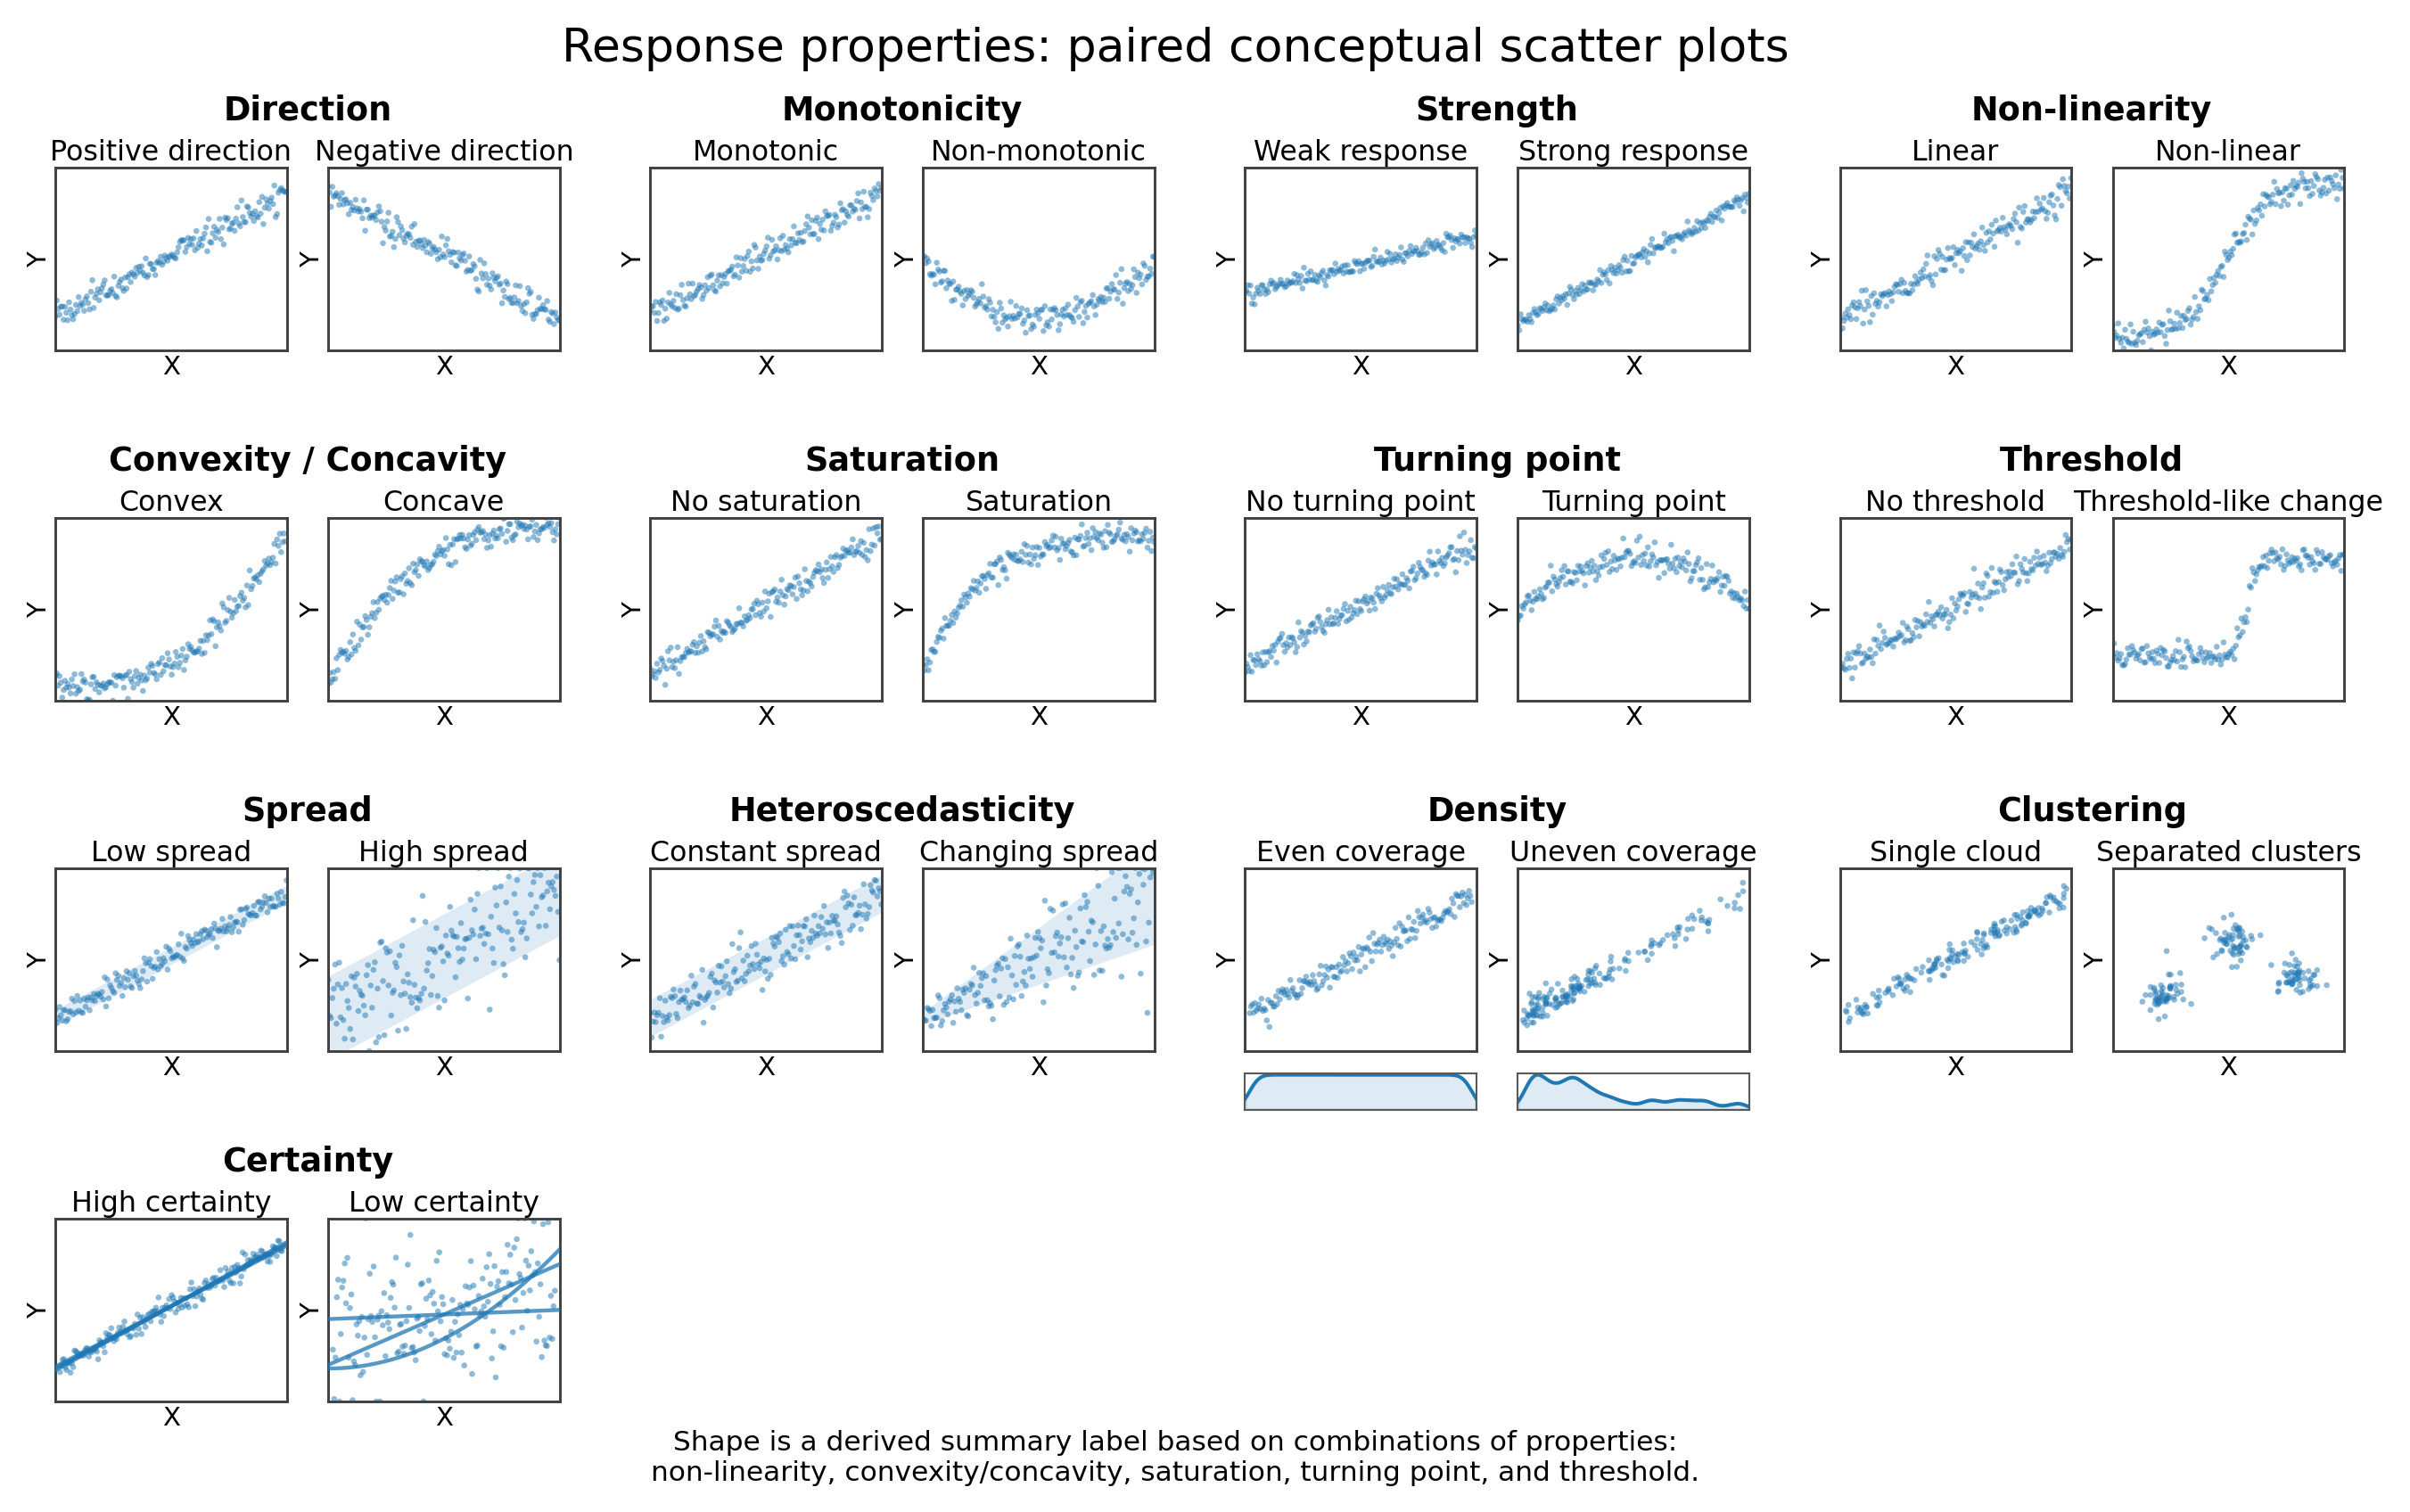

In [177]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ==========================================================
# 0. Basic settings
# ==========================================================

np.random.seed(88)
rng = np.random.default_rng(88)

x = np.linspace(0, 1, 170)

POINT_COLOR = "C0"
BUFFER_COLOR = "C0"

properties = [
    ("Direction", "Positive direction", "Negative direction"),
    ("Monotonicity", "Monotonic", "Non-monotonic"),
    ("Strength", "Weak response", "Strong response"),
    ("Non-linearity", "Linear", "Non-linear"),
    ("Convexity / Concavity", "Convex", "Concave"),
    ("Saturation", "No saturation", "Saturation"),
    ("Turning point", "No turning point", "Turning point"),
    ("Threshold", "No threshold", "Threshold-like change"),
    ("Spread", "Low spread", "High spread"),
    ("Heteroscedasticity", "Constant spread", "Changing spread"),
    ("Density", "Even coverage", "Uneven coverage"),
    ("Clustering", "Single cloud", "Separated clusters"),
    ("Certainty", "High certainty", "Low certainty"),
]


# ==========================================================
# 1. Data generation
# ==========================================================

def kde_manual(values, grid, bandwidth=0.035):
    values = np.asarray(values)
    grid = np.asarray(grid)

    dens = np.zeros_like(grid, dtype=float)

    for v in values:
        dens += np.exp(-0.5 * ((grid - v) / bandwidth) ** 2)

    dens /= max(len(values), 1)

    if dens.max() > 0:
        dens = dens / dens.max()

    return dens


def curve_data(prop):
    xx = x.copy()

    if prop == "Direction":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.86 - 0.68 * xx),
        )

    if prop == "Monotonicity":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 1.15 * (xx - 0.50) ** 2),
        )

    if prop == "Strength":
        return (
            (xx, 0.30 + 0.32 * xx),
            (xx, 0.14 + 0.70 * xx),
        )

    if prop == "Non-linearity":
        y_linear = 0.15 + 0.72 * xx

        # Strong S-shaped nonlinearity:
        # slow-fast-slow pattern, clearly different from a straight line.
        y_nonlinear = 0.08 + 0.84 / (1 + np.exp(-11.0 * (xx - 0.50)))

        return (
            (xx, y_linear),
            (xx, y_nonlinear),
        )

    if prop == "Convexity / Concavity":
        # Strong convex: slow increase first, rapid increase later.
        y_convex = 0.08 + 0.86 * (xx ** 2.8)

        # Strong concave: rapid increase first, then flattening.
        y_concave = 0.08 + 0.86 * (1 - (1 - xx) ** 2.8)

        return (
            (xx, y_convex),
            (xx, y_concave),
        )

    if prop == "Saturation":
        return (
            (xx, 0.14 + 0.76 * xx),
            (xx, 0.14 + 0.76 * (1 - np.exp(-4.5 * xx))),
        )

    if prop == "Turning point":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.78 - 1.10 * (xx - 0.52) ** 2),
        )

    if prop == "Threshold":
        y_no_threshold = 0.18 + 0.68 * xx

        # Regime-shift threshold:
        # stable low state -> rapid transition -> stable high state
        threshold = 0.58
        y_threshold = 0.25 + 0.53 / (1 + np.exp(-45 * (xx - threshold)))

        return (
            (xx, y_no_threshold),
            (xx, y_threshold),
        )

    if prop == "Spread":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.68 * xx),
        )

    if prop == "Heteroscedasticity":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.68 * xx),
        )

    if prop == "Density":
        x_even = np.linspace(0.02, 0.98, 170)

        x_uneven = np.concatenate([
            rng.uniform(0.02, 0.34, 110),
            rng.uniform(0.34, 0.98, 60),
        ])
        x_uneven = np.sort(x_uneven)

        return (
            (x_even, 0.18 + 0.68 * x_even),
            (x_uneven, 0.18 + 0.68 * x_uneven),
        )

    if prop == "Clustering":
        x_single = rng.uniform(0.02, 0.98, 170)
        y_single = 0.18 + 0.68 * x_single

        n1, n2, n3 = 55, 60, 55

        x_c1 = rng.normal(0.22, 0.045, n1)
        y_c1 = rng.normal(0.30, 0.045, n1)

        x_c2 = rng.normal(0.52, 0.050, n2)
        y_c2 = rng.normal(0.60, 0.050, n2)

        x_c3 = rng.normal(0.80, 0.045, n3)
        y_c3 = rng.normal(0.40, 0.045, n3)

        x_cluster = np.concatenate([x_c1, x_c2, x_c3])
        y_cluster = np.concatenate([y_c1, y_c2, y_c3])

        x_cluster = np.clip(x_cluster, 0.02, 0.98)
        y_cluster = np.clip(y_cluster, 0.05, 0.95)

        return (
            (x_single, y_single),
            (x_cluster, y_cluster),
        )

    if prop == "Certainty":
        x_good = np.linspace(0.02, 0.98, 170)
        y_good = 0.18 + 0.68 * x_good

        x_bad = np.linspace(0.02, 0.98, 170)
        y_bad = 0.35 + 0.30 * x_bad

        return (
            (x_good, y_good),
            (x_bad, y_bad),
        )

    raise ValueError(f"Unknown property: {prop}")


# ==========================================================
# 2. Plotting helpers
# ==========================================================

def style_axis(ax):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ["top", "right", "bottom", "left"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(0.70)
        ax.spines[spine].set_color("0.25")

    ax.set_xlabel("X", fontsize=7, labelpad=1)
    ax.set_ylabel("Y", fontsize=7, labelpad=1)


def add_buffer(ax, xx, yy, buffer_width, alpha=0.14):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    order = np.argsort(xx)
    xx_o = xx[order]
    yy_o = yy[order]

    if np.isscalar(buffer_width):
        bw = np.full_like(xx_o, buffer_width, dtype=float)
    else:
        bw = np.asarray(buffer_width)[order]

    ax.fill_between(
        xx_o,
        yy_o - bw,
        yy_o + bw,
        color=BUFFER_COLOR,
        alpha=alpha,
        linewidth=0,
        zorder=1,
    )


def draw_density_inset(ax, xx):
    grid = np.linspace(0, 1, 300)
    dens = kde_manual(xx, grid, bandwidth=0.035)

    ax_den = inset_axes(
        ax,
        width="100%",
        height="20%",
        loc="lower left",
        bbox_to_anchor=(0, -0.32, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )

    ax_den.plot(grid, dens, linewidth=0.95, color=POINT_COLOR)
    ax_den.fill_between(grid, 0, dens, color=BUFFER_COLOR, alpha=0.14)

    ax_den.set_xlim(0, 1)
    ax_den.set_ylim(0, 1.05)
    ax_den.set_xticks([])
    ax_den.set_yticks([])

    for spine in ["top", "right", "bottom", "left"]:
        ax_den.spines[spine].set_visible(True)
        ax_den.spines[spine].set_linewidth(0.50)
        ax_den.spines[spine].set_color("0.35")


def draw_certainty_panel(ax, xx, yy, title, side):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    x_line = np.linspace(0, 1, 200)

    if side == 0:
        noise_sd = 0.030
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

        lines = [
            0.18 + 0.68 * x_line,
            0.19 + 0.66 * x_line,
            0.17 + 0.70 * x_line,
        ]

    else:
        noise_sd = 0.20
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

        lines = [
            0.20 + 0.55 * x_line,
            0.45 + 0.05 * x_line,
            0.18 + 0.65 * (x_line ** 2),
        ]

    y_points = np.clip(y_points, 0, 1)

    ax.scatter(
        xx,
        y_points,
        s=2.5,
        alpha=0.5,
        color=POINT_COLOR,
        edgecolors="none",
        linewidths=0,
        zorder=2,
    )

    for line in lines:
        ax.plot(
            x_line,
            np.clip(line, 0, 1),
            linewidth=1.05,
            alpha=0.75,
            color=POINT_COLOR,
            zorder=3,
        )

    ax.set_title(title, fontsize=7.6, pad=2)
    style_axis(ax)


def draw_panel(ax, xx, yy, title, prop, side):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    if prop == "Certainty":
        draw_certainty_panel(ax, xx, yy, title, side)
        return

    if prop == "Strength":
        noise_sd = 0.025
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    elif prop == "Threshold":
        if side == 0:
            noise_sd = 0.040
            y_points = yy + np.random.normal(0, noise_sd, len(yy))
        else:
            # Stable state -> rapid transition -> new stable state.
            # Constant noise keeps both regimes visually stable.
            noise_sd = 0.035
            y_points = yy + np.random.normal(0, noise_sd, len(yy))

    elif prop == "Spread":
        noise_sd = 0.035 if side == 0 else 0.17
        y_points = yy + np.random.normal(0, noise_sd, len(yy))
        add_buffer(ax, xx, yy, noise_sd * 1.35, alpha=0.14)

    elif prop == "Heteroscedasticity":
        if side == 0:
            noise_sd = np.full_like(xx, 0.075)
        else:
            noise_sd = 0.025 + 0.18 * xx

        y_points = yy + np.random.normal(0, noise_sd, len(yy))
        add_buffer(ax, xx, yy, noise_sd * 1.35, alpha=0.14)

    elif prop == "Clustering":
        noise_sd = 0.035
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    else:
        noise_sd = 0.040
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    y_points = np.clip(y_points, 0, 1)

    ax.scatter(
        xx,
        y_points,
        s=2.5,
        alpha=0.5,
        color=POINT_COLOR,
        edgecolors="none",
        linewidths=0,
        zorder=2,
    )

    ax.set_title(title, fontsize=7.6, pad=2)
    style_axis(ax)


# ==========================================================
# 3. Combine 13 groups into one figure
# ==========================================================

n_cols = 4
n_rows = int(np.ceil(len(properties) / n_cols))

fig = plt.figure(figsize=(9.2, 5.5), dpi=300)

outer = GridSpec(
    n_rows,
    n_cols,
    figure=fig,
    hspace=0.32,
    wspace=0.18,
)

for idx, (prop, left_title, right_title) in enumerate(properties):
    row = idx // n_cols
    col = idx % n_cols

    cell = GridSpecFromSubplotSpec(
        2,
        2,
        subplot_spec=outer[row, col],
        height_ratios=[0.20, 0.80],
        hspace=0.32,
        wspace=0.18,
    )

    title_ax = fig.add_subplot(cell[0, :])
    title_ax.axis("off")

    title_ax.text(
        0.5,
        0.45,
        prop,
        ha="center",
        va="center",
        fontsize=8.8,
        fontweight="bold",
    )

    (xl, yl), (xr, yr) = curve_data(prop)

    ax_l = fig.add_subplot(cell[1, 0])
    ax_r = fig.add_subplot(cell[1, 1])

    draw_panel(ax_l, xl, yl, left_title, prop, 0)
    draw_panel(ax_r, xr, yr, right_title, prop, 1)

    if prop == "Density":
        ax_l.set_xlabel("")
        ax_r.set_xlabel("")
        draw_density_inset(ax_l, xl)
        draw_density_inset(ax_r, xr)

# Empty cell for the 14th position
if len(properties) % n_cols != 0:
    empty_ax = fig.add_subplot(outer[-1, -1])
    empty_ax.axis("off")

fig.suptitle(
    "Response properties: paired conceptual scatter plots",
    fontsize=12.5,
    y=0.995,
)

shape_note = (
    "Shape is a derived summary label based on combinations of properties:\n"
    "non-linearity, convexity/concavity, saturation, turning point, and threshold."
)

fig.text(
    0.5,
    0.022,
    shape_note,
    ha="center",
    va="center",
    fontsize=7.5,
)

plt.subplots_adjust(
    left=0.045,
    right=0.975,
    top=0.955,
    bottom=0.06,
)

plt.show()

In [178]:
import numpy as np
import pandas as pd

from scipy.stats import pearsonr, spearmanr, ks_2samp, wasserstein_distance
from scipy.spatial.distance import pdist, squareform
from statsmodels.nonparametric.smoothers_lowess import lowess


# ==========================================================
# 0. Simulated conceptual datasets
# ==========================================================

np.random.seed(88)
rng = np.random.default_rng(88)

x_base = np.linspace(0, 1, 170)

properties = [
    ("Direction", "Positive direction", "Negative direction"),
    ("Monotonicity", "Monotonic", "Non-monotonic"),
    ("Strength", "Weak response", "Strong response"),
    ("Non-linearity", "Linear", "Non-linear"),
    ("Convexity / Concavity", "Convex", "Concave"),
    ("Saturation", "No saturation", "Saturation"),
    ("Turning point", "No turning point", "Turning point"),
    ("Threshold", "No threshold", "Threshold-like change"),
    ("Spread", "Low spread", "High spread"),
    ("Heteroscedasticity", "Constant spread", "Changing spread"),
    ("Density", "Even coverage", "Uneven coverage"),
    ("Clustering", "Single cloud", "Separated clusters"),
    ("Certainty", "High certainty", "Low certainty"),
]


def curve_data(prop):
    xx = x_base.copy()

    if prop == "Direction":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.86 - 0.68 * xx),
        )

    if prop == "Monotonicity":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 1.15 * (xx - 0.50) ** 2),
        )

    if prop == "Strength":
        return (
            (xx, 0.30 + 0.32 * xx),
            (xx, 0.14 + 0.70 * xx),
        )

    if prop == "Non-linearity":
        y_linear = 0.15 + 0.72 * xx
        y_nonlinear = 0.08 + 0.84 / (1 + np.exp(-11.0 * (xx - 0.50)))

        return (
            (xx, y_linear),
            (xx, y_nonlinear),
        )

    if prop == "Convexity / Concavity":
        y_convex = 0.08 + 0.86 * (xx ** 2.8)
        y_concave = 0.08 + 0.86 * (1 - (1 - xx) ** 2.8)

        return (
            (xx, y_convex),
            (xx, y_concave),
        )

    if prop == "Saturation":
        return (
            (xx, 0.14 + 0.76 * xx),
            (xx, 0.14 + 0.76 * (1 - np.exp(-4.5 * xx))),
        )

    if prop == "Turning point":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.78 - 1.10 * (xx - 0.52) ** 2),
        )

    if prop == "Threshold":
        y_no_threshold = 0.18 + 0.68 * xx

        # Regime-shift threshold:
        # stable low state -> rapid transition -> stable high state
        threshold = 0.58
        y_threshold = 0.25 + 0.53 / (1 + np.exp(-45 * (xx - threshold)))

        return (
            (xx, y_no_threshold),
            (xx, y_threshold),
        )

    if prop == "Spread":
        y_mean = 0.18 + 0.68 * xx

        y_low_spread = y_mean + rng.normal(0, 0.035, len(xx))
        y_high_spread = y_mean + rng.normal(0, 0.17, len(xx))

        return (
            (xx, np.clip(y_low_spread, 0, 1)),
            (xx, np.clip(y_high_spread, 0, 1)),
        )

    if prop == "Heteroscedasticity":
        y_mean = 0.18 + 0.68 * xx

        y_constant = y_mean + rng.normal(0, 0.075, len(xx))
        y_changing = y_mean + rng.normal(0, 0.025 + 0.18 * xx, len(xx))

        return (
            (xx, np.clip(y_constant, 0, 1)),
            (xx, np.clip(y_changing, 0, 1)),
        )

    if prop == "Density":
        x_even = np.linspace(0.02, 0.98, 170)

        x_uneven = np.concatenate([
            rng.uniform(0.02, 0.34, 110),
            rng.uniform(0.34, 0.98, 60),
        ])
        x_uneven = np.sort(x_uneven)

        return (
            (x_even, 0.18 + 0.68 * x_even),
            (x_uneven, 0.18 + 0.68 * x_uneven),
        )

    if prop == "Clustering":
        x_single = rng.uniform(0.02, 0.98, 170)
        y_single = 0.18 + 0.68 * x_single + rng.normal(0, 0.035, 170)

        n1, n2, n3 = 55, 60, 55

        x_c1 = rng.normal(0.22, 0.045, n1)
        y_c1 = rng.normal(0.30, 0.045, n1)

        x_c2 = rng.normal(0.52, 0.050, n2)
        y_c2 = rng.normal(0.60, 0.050, n2)

        x_c3 = rng.normal(0.80, 0.045, n3)
        y_c3 = rng.normal(0.40, 0.045, n3)

        x_cluster = np.clip(
            np.concatenate([x_c1, x_c2, x_c3]),
            0.02,
            0.98,
        )
        y_cluster = np.clip(
            np.concatenate([y_c1, y_c2, y_c3]),
            0.05,
            0.95,
        )

        return (
            (x_single, np.clip(y_single, 0, 1)),
            (x_cluster, y_cluster),
        )

    if prop == "Certainty":
        x_good = np.linspace(0.02, 0.98, 170)
        y_good = 0.18 + 0.68 * x_good + rng.normal(0, 0.030, len(x_good))

        x_bad = np.linspace(0.02, 0.98, 170)
        y_bad = 0.35 + 0.30 * x_bad + rng.normal(0, 0.20, len(x_bad))

        return (
            (x_good, np.clip(y_good, 0, 1)),
            (x_bad, np.clip(y_bad, 0, 1)),
        )

    raise ValueError(f"Unknown property: {prop}")


# ==========================================================
# 1. Basic helper functions
# ==========================================================

def _to_valid_arrays(x, y):
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()

    valid = np.isfinite(x) & np.isfinite(y)
    return x[valid], y[valid]


def _safe_divide(a, b):
    if b == 0 or not np.isfinite(b):
        return np.nan
    return a / b


def _minmax_norm(v):
    v = np.asarray(v, dtype=float)

    v_min = np.nanmin(v)
    v_max = np.nanmax(v)

    if not np.isfinite(v_min) or not np.isfinite(v_max) or v_max == v_min:
        return np.full_like(v, np.nan, dtype=float)

    return (v - v_min) / (v_max - v_min)


def _endpoint_slope(x, y):
    if len(x) < 2:
        return np.nan

    return _safe_divide(y[-1] - y[0], x[-1] - x[0])


def _segment_masks_by_order(n):
    i1 = n // 3
    i2 = 2 * n // 3

    early = np.zeros(n, dtype=bool)
    middle = np.zeros(n, dtype=bool)
    late = np.zeros(n, dtype=bool)

    early[:i1] = True
    middle[i1:i2] = True
    late[i2:] = True

    return early, middle, late


def _residual_sd(y, y_hat):
    residuals = y - y_hat

    if len(residuals) < 2:
        return np.nan

    return np.nanstd(residuals, ddof=1)


def _r2_score(y, y_hat):
    ss_res = np.nansum((y - y_hat) ** 2)
    ss_tot = np.nansum((y - np.nanmean(y)) ** 2)

    if ss_tot == 0:
        return np.nan

    return 1 - ss_res / ss_tot


def _count_derivative_sign_changes(x_curve, y_curve, slope_tol=1e-6):
    x_curve = np.asarray(x_curve, dtype=float)
    y_curve = np.asarray(y_curve, dtype=float)

    valid = np.isfinite(x_curve) & np.isfinite(y_curve)
    x_curve = x_curve[valid]
    y_curve = y_curve[valid]

    if len(x_curve) < 4:
        return np.nan

    order = np.argsort(x_curve)
    x_curve = x_curve[order]
    y_curve = y_curve[order]

    dx = np.diff(x_curve)
    dy = np.diff(y_curve)

    valid_diff = dx != 0

    if valid_diff.sum() < 3:
        return np.nan

    slopes = dy[valid_diff] / dx[valid_diff]

    signs = np.zeros_like(slopes, dtype=int)
    signs[slopes > slope_tol] = 1
    signs[slopes < -slope_tol] = -1

    nonzero_signs = signs[signs != 0]

    if len(nonzero_signs) < 2:
        return 0

    return int(np.sum(nonzero_signs[1:] != nonzero_signs[:-1]))


# ==========================================================
# 2. X coverage / density metrics
# ==========================================================

def compute_x_coverage_metrics(x, n_bins=10):
    """
    x_uniform_ks_distance:
        KS distance between observed X and a uniform distribution
        over the observed X range.

    equal_width_bin_x_bin_count_cv:
        Coefficient of variation of X counts across equal-width bins.
    """
    x = np.asarray(x, dtype=float).ravel()
    x = x[np.isfinite(x)]

    result = {
        "x_uniform_ks_distance": np.nan,
        "equal_width_bin_x_bin_count_cv": np.nan,
    }

    if len(x) < 3:
        return result

    # X uniform KS distance
    x_min = np.nanmin(x)
    x_max = np.nanmax(x)

    if x_max > x_min:
        x_norm = (x - x_min) / (x_max - x_min)
        x_sorted = np.sort(x_norm)
        n = len(x_sorted)

        d_plus = np.max(np.arange(1, n + 1) / n - x_sorted)
        d_minus = np.max(x_sorted - np.arange(0, n) / n)

        result["x_uniform_ks_distance"] = max(d_plus, d_minus)

    # Equal-width bin count CV
    if len(x) >= n_bins:
        counts, _ = np.histogram(x, bins=n_bins)

        mean_count = np.mean(counts)
        sd_count = np.std(counts, ddof=1)

        if mean_count > 0:
            result["equal_width_bin_x_bin_count_cv"] = sd_count / mean_count

    return result


# ==========================================================
# 3. Correlation-based metrics
# ==========================================================

def compute_correlation_metrics(x, y):
    x, y = _to_valid_arrays(x, y)

    result = {
        "pearson_r": np.nan,
        "spearman_rho": np.nan,
        "covariance": np.nan,
    }

    if len(x) < 3:
        return result

    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return result

    result["pearson_r"] = pearsonr(x, y)[0]
    result["spearman_rho"] = spearmanr(x, y)[0]
    result["covariance"] = np.cov(x, y, ddof=1)[0, 1]

    return result


# ==========================================================
# 4. Distance-based metrics
# ==========================================================

def _double_center_distance_matrix(a):
    a = np.asarray(a, dtype=float).reshape(-1, 1)

    dist = squareform(pdist(a, metric="euclidean"))

    row_mean = dist.mean(axis=1, keepdims=True)
    col_mean = dist.mean(axis=0, keepdims=True)
    grand_mean = dist.mean()

    return dist - row_mean - col_mean + grand_mean


def compute_distance_metrics(x, y):
    x, y = _to_valid_arrays(x, y)

    result = {
        "distance_covariance": np.nan,
        "distance_correlation": np.nan,
    }

    if len(x) < 3:
        return result

    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return result

    A = _double_center_distance_matrix(x)
    B = _double_center_distance_matrix(y)

    dcov2_xy = np.mean(A * B)
    dcov2_xx = np.mean(A * A)
    dcov2_yy = np.mean(B * B)

    dcov_xy = np.sqrt(max(dcov2_xy, 0))
    dcov_xx = np.sqrt(max(dcov2_xx, 0))
    dcov_yy = np.sqrt(max(dcov2_yy, 0))

    result["distance_covariance"] = dcov_xy
    result["distance_correlation"] = _safe_divide(
        dcov_xy,
        np.sqrt(dcov_xx * dcov_yy),
    )

    return result


# ==========================================================
# 5. Distribution-based metrics
# ==========================================================

def _make_bins(x, n_bins=10, bin_type="equal_width"):
    x = np.asarray(x, dtype=float)

    if bin_type == "equal_width":
        bins = pd.cut(
            x,
            bins=n_bins,
            labels=False,
            include_lowest=True,
            duplicates="drop",
        )

    elif bin_type == "equal_count":
        bins = pd.qcut(
            x,
            q=n_bins,
            labels=False,
            duplicates="drop",
        )

    else:
        raise ValueError("bin_type must be 'equal_width' or 'equal_count'.")

    return np.asarray(bins, dtype=float)


def compute_distribution_metrics(x, y, n_bins=10, bin_type="equal_width"):
    """
    Compare Y distributions under low-X and high-X conditions.

    equal_width_distribution_ks_distance:
        KS distance between Y | low-X and Y | high-X using equal-width bins.

    equal_count_distribution_ks_distance:
        KS distance between Y | low-X and Y | high-X using equal-count bins.
    """
    x, y = _to_valid_arrays(x, y)

    prefix = f"{bin_type}_distribution"

    result = {
        f"{prefix}_ks_distance": np.nan,
        f"{prefix}_wasserstein_distance": np.nan,
    }

    if len(x) < n_bins:
        return result

    bins = _make_bins(x, n_bins=n_bins, bin_type=bin_type)

    df = pd.DataFrame({
        "x": x,
        "y": y,
        "bin": bins,
    }).dropna()

    if df.empty:
        return result

    valid_bins = np.sort(df["bin"].unique())

    if len(valid_bins) < 3:
        return result

    n_valid_bins = len(valid_bins)
    i1 = n_valid_bins // 3
    i2 = 2 * n_valid_bins // 3

    low_bins = valid_bins[:i1]
    high_bins = valid_bins[i2:]

    y_low = df[df["bin"].isin(low_bins)]["y"].values
    y_high = df[df["bin"].isin(high_bins)]["y"].values

    if len(y_low) < 2 or len(y_high) < 2:
        return result

    result[f"{prefix}_ks_distance"] = ks_2samp(y_low, y_high).statistic
    result[f"{prefix}_wasserstein_distance"] = wasserstein_distance(y_low, y_high)

    return result


# ==========================================================
# 6. Slope-based metrics
# ==========================================================

def compute_slope_metrics(x, y, prefix="raw"):
    x, y = _to_valid_arrays(x, y)

    result = {
        f"{prefix}_overall_slope": np.nan,
        f"{prefix}_early_slope": np.nan,
        f"{prefix}_middle_slope": np.nan,
        f"{prefix}_late_slope": np.nan,
        f"{prefix}_segment_strength": np.nan,
    }

    if len(x) < 6:
        return result

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    result[f"{prefix}_overall_slope"] = _endpoint_slope(x_sorted, y_sorted)

    early_mask, middle_mask, late_mask = _segment_masks_by_order(len(x_sorted))

    segment_slopes = {}

    for name, mask in zip(
        ["early", "middle", "late"],
        [early_mask, middle_mask, late_mask],
    ):
        xs = x_sorted[mask]
        ys = y_sorted[mask]

        segment_slopes[name] = _endpoint_slope(xs, ys)
        result[f"{prefix}_{name}_slope"] = segment_slopes[name]

    result[f"{prefix}_segment_strength"] = np.nanmean([
        abs(segment_slopes["early"]),
        abs(segment_slopes["middle"]),
        abs(segment_slopes["late"]),
    ])

    return result


def compute_standardized_slope_metrics(x, y):
    x, y = _to_valid_arrays(x, y)

    x_norm = _minmax_norm(x)
    y_norm = _minmax_norm(y)

    return compute_slope_metrics(
        x_norm,
        y_norm,
        prefix="standardized",
    )


# ==========================================================
# 7. Information-based metrics
# ==========================================================

def compute_information_metrics(x, y):
    """
    MIC / MAS / MEV / MCN require minepy.
    If minepy is unavailable, these metrics return NaN.
    """
    x, y = _to_valid_arrays(x, y)

    result = {
        "MIC": np.nan,
        "MAS": np.nan,
        "MEV": np.nan,
        "MCN": np.nan,
        "MIC_minus_r2": np.nan,
    }

    if len(x) < 5:
        return result

    try:
        from minepy import MINE

        mine = MINE(alpha=0.6, c=15)
        mine.compute_score(x, y)

        mic = mine.mic()
        mas = mine.mas()
        mev = mine.mev()
        mcn = mine.mcn()

        r = pearsonr(x, y)[0] if np.nanstd(x) > 0 and np.nanstd(y) > 0 else np.nan

        result["MIC"] = mic
        result["MAS"] = mas
        result["MEV"] = mev
        result["MCN"] = mcn
        result["MIC_minus_r2"] = mic - r ** 2 if np.isfinite(r) else np.nan

    except Exception:
        pass

    return result


# ==========================================================
# 8. Bin-based metrics
# ==========================================================

def compute_bin_metrics(
    x,
    y,
    n_bins=10,
    bin_type="equal_width",
    buffer_method="q95_q05",
    min_count_per_bin=5,
):
    x, y = _to_valid_arrays(x, y)

    prefix = f"{bin_type}_bin"

    result = {
        f"{prefix}_amplitude": np.nan,
        f"{prefix}_eta_squared": np.nan,
        f"{prefix}_buffer_width_mean": np.nan,
        f"{prefix}_early_buffer_width": np.nan,
        f"{prefix}_middle_buffer_width": np.nan,
        f"{prefix}_late_buffer_width": np.nan,
        f"{prefix}_n_valid_bins": 0,
    }

    if len(x) < n_bins:
        return result

    bins = _make_bins(x, n_bins=n_bins, bin_type=bin_type)

    df = pd.DataFrame({
        "x": x,
        "y": y,
        "bin": bins,
    }).dropna()

    if df.empty:
        return result

    bin_stats = []

    for bin_id, g in df.groupby("bin", observed=True):
        if len(g) < min_count_per_bin:
            continue

        y_values = g["y"].values

        if buffer_method == "q95_q05":
            bw = np.nanpercentile(y_values, 95) - np.nanpercentile(y_values, 5)
        elif buffer_method == "q75_q25":
            bw = np.nanpercentile(y_values, 75) - np.nanpercentile(y_values, 25)
        elif buffer_method == "sd":
            bw = np.nanstd(y_values, ddof=1)
        else:
            raise ValueError("Unknown buffer_method.")

        bin_stats.append({
            "bin": bin_id,
            "x_mean": np.nanmean(g["x"]),
            "y_mean": np.nanmean(g["y"]),
            "buffer_width": bw,
            "count": len(g),
        })

    if len(bin_stats) < 2:
        return result

    bin_df = pd.DataFrame(bin_stats).sort_values("x_mean").reset_index(drop=True)

    result[f"{prefix}_amplitude"] = (
        np.nanmax(bin_df["y_mean"]) - np.nanmin(bin_df["y_mean"])
    )

    y_all = df["y"].values
    y_global_mean = np.nanmean(y_all)

    ss_total = np.nansum((y_all - y_global_mean) ** 2)

    ss_between = 0.0
    for _, row in bin_df.iterrows():
        g = df[df["bin"] == row["bin"]]
        ss_between += len(g) * (row["y_mean"] - y_global_mean) ** 2

    result[f"{prefix}_eta_squared"] = _safe_divide(ss_between, ss_total)

    result[f"{prefix}_buffer_width_mean"] = np.nanmean(bin_df["buffer_width"])
    result[f"{prefix}_n_valid_bins"] = len(bin_df)

    n_valid_bins = len(bin_df)
    i1 = n_valid_bins // 3
    i2 = 2 * n_valid_bins // 3

    result[f"{prefix}_early_buffer_width"] = np.nanmean(
        bin_df.iloc[:i1]["buffer_width"]
    )
    result[f"{prefix}_middle_buffer_width"] = np.nanmean(
        bin_df.iloc[i1:i2]["buffer_width"]
    )
    result[f"{prefix}_late_buffer_width"] = np.nanmean(
        bin_df.iloc[i2:]["buffer_width"]
    )

    return result


# ==========================================================
# 9. Curve-based metrics: LOWESS
# ==========================================================

def fit_lowess_curve(x, y, frac=0.25):
    x, y = _to_valid_arrays(x, y)

    if len(x) < 5:
        return None, None

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    fitted = lowess(
        endog=y_sorted,
        exog=x_sorted,
        frac=frac,
        return_sorted=True,
    )

    return fitted[:, 0], fitted[:, 1]


def compute_curve_metrics_from_fit(
    x,
    y,
    x_curve,
    y_curve,
    prefix,
    derivative_slope_tol=1e-6,
):
    x, y = _to_valid_arrays(x, y)

    result = {
        f"{prefix}_residual_sd": np.nan,
        f"{prefix}_curve_amplitude": np.nan,
        f"{prefix}_r2": np.nan,
        f"{prefix}_first_derivative_sign_changes": np.nan,
    }

    if x_curve is None or y_curve is None:
        return result

    x_curve = np.asarray(x_curve, dtype=float)
    y_curve = np.asarray(y_curve, dtype=float)

    valid_curve = np.isfinite(x_curve) & np.isfinite(y_curve)
    x_curve = x_curve[valid_curve]
    y_curve = y_curve[valid_curve]

    if len(x_curve) < 2:
        return result

    order = np.argsort(x_curve)
    x_curve = x_curve[order]
    y_curve = y_curve[order]

    y_hat = np.interp(x, x_curve, y_curve)

    result[f"{prefix}_residual_sd"] = _residual_sd(y, y_hat)
    result[f"{prefix}_curve_amplitude"] = np.nanmax(y_curve) - np.nanmin(y_curve)
    result[f"{prefix}_r2"] = _r2_score(y, y_hat)

    result[f"{prefix}_first_derivative_sign_changes"] = (
        _count_derivative_sign_changes(
            x_curve,
            y_curve,
            slope_tol=derivative_slope_tol,
        )
    )

    return result


def compute_lowess_metrics(x, y, frac=0.25):
    x_curve, y_curve = fit_lowess_curve(x, y, frac=frac)

    return compute_curve_metrics_from_fit(
        x,
        y,
        x_curve,
        y_curve,
        prefix="lowess",
    )


# ==========================================================
# 10. Curve-based metrics: GAM
# ==========================================================

def fit_gam_curve(x, y, n_splines=10, lam=0.6, grid_size=200):
    """
    GAM requires pygam.
    If pygam is unavailable, GAM metrics return NaN.
    """
    x, y = _to_valid_arrays(x, y)

    if len(x) < 10:
        return None, None

    try:
        from pygam import LinearGAM, s

        X = x.reshape(-1, 1)

        gam = LinearGAM(
            s(0, n_splines=n_splines),
            lam=lam,
        ).fit(X, y)

        x_curve = np.linspace(np.nanmin(x), np.nanmax(x), grid_size)
        y_curve = gam.predict(x_curve.reshape(-1, 1))

        return x_curve, y_curve

    except Exception:
        return None, None


def compute_gam_metrics(
    x,
    y,
    n_splines=10,
    lam=0.6,
    grid_size=200,
):
    x_curve, y_curve = fit_gam_curve(
        x,
        y,
        n_splines=n_splines,
        lam=lam,
        grid_size=grid_size,
    )

    return compute_curve_metrics_from_fit(
        x,
        y,
        x_curve,
        y_curve,
        prefix="gam",
    )


# ==========================================================
# 11. Main wrapper
# ==========================================================

def compute_all_response_metrics(
    x,
    y,
    n_bins=10,
    min_count_per_bin=5,
    lowess_frac=0.25,
    gam_n_splines=10,
    gam_lam=0.6,
):
    x, y = _to_valid_arrays(x, y)

    results = {}

    # Correlation-based
    results.update(compute_correlation_metrics(x, y))

    # Distance-based
    results.update(compute_distance_metrics(x, y))

    # X coverage / density metrics
    results.update(
        compute_x_coverage_metrics(
            x,
            n_bins=n_bins,
        )
    )

    # Distribution-based: Y distribution shift under low-X vs high-X
    results.update(
        compute_distribution_metrics(
            x,
            y,
            n_bins=n_bins,
            bin_type="equal_width",
        )
    )

    results.update(
        compute_distribution_metrics(
            x,
            y,
            n_bins=n_bins,
            bin_type="equal_count",
        )
    )

    # Slope-based
    results.update(compute_slope_metrics(x, y, prefix="raw"))
    results.update(compute_standardized_slope_metrics(x, y))

    # Information-based
    results.update(compute_information_metrics(x, y))

    # Bin-based
    results.update(
        compute_bin_metrics(
            x,
            y,
            n_bins=n_bins,
            bin_type="equal_width",
            min_count_per_bin=min_count_per_bin,
        )
    )

    results.update(
        compute_bin_metrics(
            x,
            y,
            n_bins=n_bins,
            bin_type="equal_count",
            min_count_per_bin=min_count_per_bin,
        )
    )

    # Curve-based
    results.update(
        compute_lowess_metrics(
            x,
            y,
            frac=lowess_frac,
        )
    )

    results.update(
        compute_gam_metrics(
            x,
            y,
            n_splines=gam_n_splines,
            lam=gam_lam,
        )
    )

    results["n_valid"] = len(x)

    return results


# ==========================================================
# 12. Compute metrics for all simulated property cases
# ==========================================================

all_property_metrics = []

for prop, left_title, right_title in properties:
    (xl, yl), (xr, yr) = curve_data(prop)

    left_metrics = compute_all_response_metrics(
        xl,
        yl,
        n_bins=10,
        min_count_per_bin=5,
        lowess_frac=0.25,
        gam_n_splines=10,
        gam_lam=0.6,
    )

    left_metrics["property"] = prop
    left_metrics["case"] = left_title
    left_metrics["side"] = "left"

    right_metrics = compute_all_response_metrics(
        xr,
        yr,
        n_bins=10,
        min_count_per_bin=5,
        lowess_frac=0.25,
        gam_n_splines=10,
        gam_lam=0.6,
    )

    right_metrics["property"] = prop
    right_metrics["case"] = right_title
    right_metrics["side"] = "right"

    all_property_metrics.append(left_metrics)
    all_property_metrics.append(right_metrics)


property_metrics_df = pd.DataFrame(all_property_metrics)

id_cols = ["property", "case", "side"]
metric_cols = [c for c in property_metrics_df.columns if c not in id_cols]

property_metrics_df = property_metrics_df[id_cols + metric_cols]


# ==========================================================
# 13. Round results and export to Excel
# ==========================================================

property_metrics_df_rounded = property_metrics_df.copy()

numeric_cols = property_metrics_df_rounded.select_dtypes(include=[np.number]).columns
property_metrics_df_rounded[numeric_cols] = (
    property_metrics_df_rounded[numeric_cols].round(4)
)

selected_cols = [
    "property",
    "case",
    "side",

    # Correlation-based
    "pearson_r",
    "spearman_rho",
    "covariance",

    # Distance-based
    "distance_covariance",
    "distance_correlation",

    # X coverage / density
    "x_uniform_ks_distance",
    "equal_width_bin_x_bin_count_cv",

    # Distribution-based
    "equal_width_distribution_ks_distance",
    "equal_width_distribution_wasserstein_distance",
    "equal_count_distribution_ks_distance",
    "equal_count_distribution_wasserstein_distance",

    # Slope-based
    "raw_overall_slope",
    "raw_early_slope",
    "raw_middle_slope",
    "raw_late_slope",
    "raw_segment_strength",

    # Standardized slope-based
    "standardized_overall_slope",
    "standardized_early_slope",
    "standardized_middle_slope",
    "standardized_late_slope",
    "standardized_segment_strength",

    # Information-based
    "MIC",
    "MAS",
    "MEV",
    "MCN",
    "MIC_minus_r2",

    # Equal-width bin-based
    "equal_width_bin_amplitude",
    "equal_width_bin_eta_squared",
    "equal_width_bin_buffer_width_mean",
    "equal_width_bin_early_buffer_width",
    "equal_width_bin_middle_buffer_width",
    "equal_width_bin_late_buffer_width",
    "equal_width_bin_n_valid_bins",

    # Equal-count bin-based
    "equal_count_bin_amplitude",
    "equal_count_bin_eta_squared",
    "equal_count_bin_buffer_width_mean",
    "equal_count_bin_early_buffer_width",
    "equal_count_bin_middle_buffer_width",
    "equal_count_bin_late_buffer_width",
    "equal_count_bin_n_valid_bins",

    # LOWESS curve-based
    "lowess_residual_sd",
    "lowess_curve_amplitude",
    "lowess_r2",
    "lowess_first_derivative_sign_changes",

    # GAM curve-based
    "gam_residual_sd",
    "gam_curve_amplitude",
    "gam_r2",
    "gam_first_derivative_sign_changes",

    "n_valid",
]

selected_cols_existing = [
    c for c in selected_cols
    if c in property_metrics_df_rounded.columns
]

output_excel = "./output/conceptual_response_property_metrics_7.xlsx"

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    property_metrics_df_rounded.to_excel(
        writer,
        sheet_name="all_metrics",
        index=False,
    )

    property_metrics_df_rounded[selected_cols_existing].to_excel(
        writer,
        sheet_name="selected_metrics",
        index=False,
    )

print(f"Excel file saved to: {output_excel}")

property_metrics_df_rounded

Excel file saved to: ./output/conceptual_response_property_metrics_7.xlsx


,property,case,side,pearson_r,spearman_rho,covariance,distance_covariance,distance_correlation,x_uniform_ks_distance,equal_width_bin_x_bin_count_cv,...,equal_count_bin_n_valid_bins,lowess_residual_sd,lowess_curve_amplitude,lowess_r2,lowess_first_derivative_sign_changes,gam_residual_sd,gam_curve_amplitude,gam_r2,gam_first_derivative_sign_changes,n_valid
0,Direction,Positive direction,left,1.0000,1.0000,0.0577,0.1749,1.0000,0.0059,0.0000,...,10,0.0000,0.6800,1.0000,0,0.0000,0.6800,1.0000,0,170
1,Direction,Negative direction,right,-1.0000,-1.0000,-0.0577,0.1749,1.0000,0.0059,0.0000,...,10,0.0000,0.6800,1.0000,0,0.0000,0.6800,1.0000,0,170
2,Monotonicity,Monotonic,left,1.0000,1.0000,0.0577,0.1749,1.0000,0.0059,0.0000,...,10,0.0000,0.6800,1.0000,0,0.0000,0.6800,1.0000,0,170
3,Monotonicity,Non-monotonic,right,-0.0000,-0.0029,-0.0000,0.0570,0.4915,0.0059,0.0000,...,10,0.0016,0.2792,0.9991,1,0.0016,0.2807,0.9997,1,170
4,Strength,Weak response,left,1.0000,1.0000,0.0271,0.1200,1.0000,0.0059,0.0000,...,10,0.0000,0.3200,1.0000,0,0.0000,0.3200,1.0000,0,170
5,Strength,Strong response,right,1.0000,1.0000,0.0594,0.1774,1.0000,0.0059,0.0000,...,10,0.0000,0.7000,1.0000,0,0.0000,0.7000,1.0000,0,170
6,Non-linearity,Linear,left,1.0000,1.0000,0.0611,0.1800,1.0000,0.0059,0.0000,...,10,0.0000,0.7200,1.0000,0,0.0000,0.7200,1.0000,0,170
7,Non-linearity,Non-linear,right,0.9688,1.0000,0.0952,0.2418,0.9802,0.0059,0.0000,...,10,0.0063,0.8378,0.9997,0,0.0067,0.8336,0.9996,0,170
8,Convexity / Concavity,Convex,left,0.9265,1.0000,0.0673,0.1854,0.9571,0.0059,0.0000,...,10,0.0024,0.8493,0.9998,0,0.0020,0.8491,0.9999,0,170
9,Convexity / Concavity,Concave,right,0.9265,1.0000,0.0673,0.1854,0.9571,0.0059,0.0000,...,10,0.0024,0.8493,0.9998,0,0.0020,0.8491,0.9999,0,170


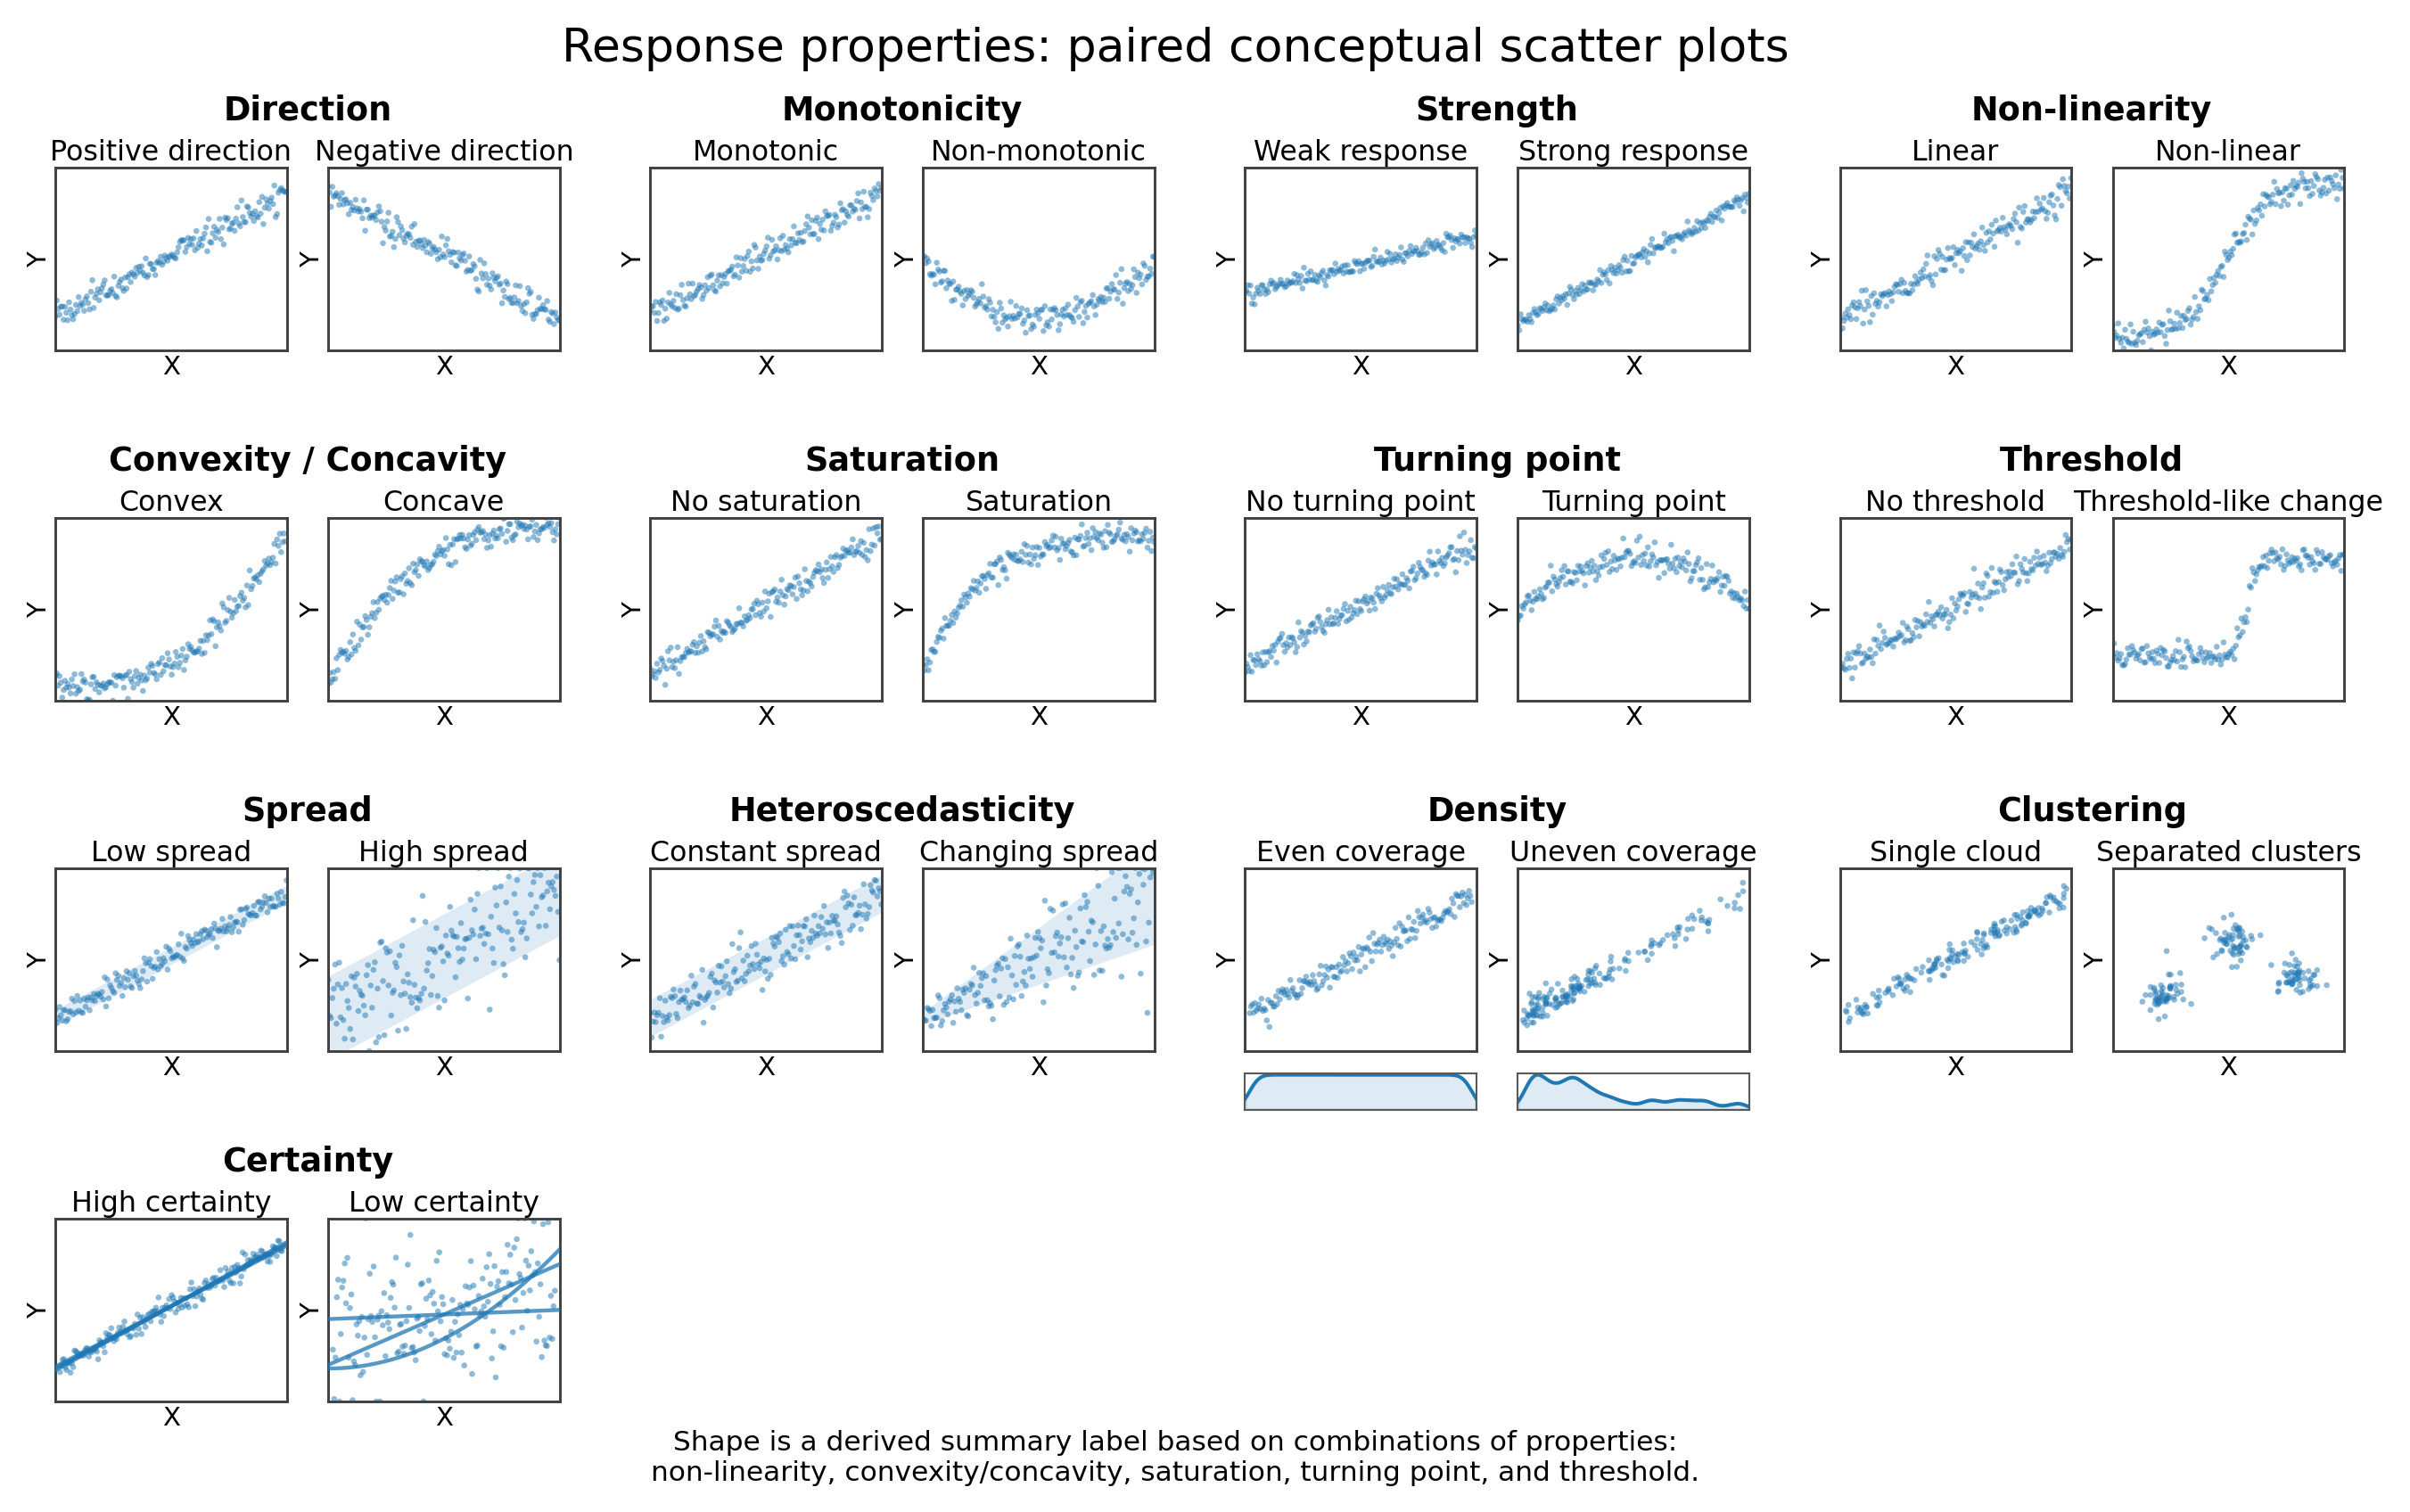

Excel file saved to: ./output/no_certainty.xlsx


,property,case,side,y_sd,pearson_r,spearman_rho,covariance,distance_covariance,distance_correlation,x_uniform_ks_distance,...,lowess_curve_amplitude_div_y_sd,lowess_r2,lowess_first_derivative_sign_changes,gam_residual_sd,gam_residual_sd_div_y_sd,gam_curve_amplitude,gam_curve_amplitude_div_y_sd,gam_r2,gam_first_derivative_sign_changes,n_valid
0,Direction,Positive direction,left,0.2006,0.9816,0.9825,0.0573,0.1715,0.9809,0.0059,...,3.3987,0.9650,0,0.0377,0.1882,0.6688,3.3343,0.9646,0,170
1,Direction,Negative direction,right,0.2061,-0.9793,-0.9806,-0.0588,0.1727,0.9748,0.0059,...,3.3672,0.9617,0,0.0404,0.1962,0.6931,3.3633,0.9615,0,170
2,Monotonicity,Monotonic,left,0.1979,0.9803,0.9807,0.0565,0.1700,0.9778,0.0059,...,3.3362,0.9622,0,0.0386,0.1950,0.6598,3.3344,0.9620,0,170
3,Monotonicity,Non-monotonic,right,0.1011,-0.0017,0.0115,-0.0001,0.0547,0.4525,0.0059,...,3.0390,0.8441,1,0.0401,0.3962,0.3107,3.0721,0.8430,1,170
4,Strength,Weak response,left,0.0953,0.9682,0.9715,0.0269,0.1157,0.9672,0.0059,...,3.2220,0.9382,0,0.0237,0.2485,0.3151,3.3061,0.9383,0,170
5,Strength,Strong response,right,0.2031,0.9931,0.9933,0.0587,0.1750,0.9914,0.0059,...,3.4672,0.9866,0,0.0236,0.1160,0.6987,3.4400,0.9865,0,170
6,Non-linearity,Linear,left,0.2121,0.9787,0.9805,0.0605,0.1755,0.9766,0.0059,...,3.4532,0.9594,0,0.0429,0.2020,0.7217,3.4018,0.9592,0,170
7,Non-linearity,Non-linear,right,0.3412,0.9622,0.9643,0.0956,0.2381,0.9722,0.0059,...,2.4516,0.9867,1,0.0396,0.1160,0.8347,2.4462,0.9865,1,170
8,Convexity / Concavity,Convex,left,0.2525,0.9147,0.9438,0.0673,0.1817,0.9368,0.0059,...,3.2914,0.9753,1,0.0396,0.1569,0.8350,3.3074,0.9754,1,170
9,Convexity / Concavity,Concave,right,0.2483,0.9204,0.9530,0.0665,0.1807,0.9409,0.0059,...,3.3603,0.9770,0,0.0377,0.1519,0.8352,3.3638,0.9769,0,170


In [7]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from scipy.stats import pearsonr, spearmanr, ks_2samp, wasserstein_distance
from scipy.spatial.distance import pdist, squareform
from statsmodels.nonparametric.smoothers_lowess import lowess


# ==========================================================
# 0. Basic settings
# ==========================================================

SEED = 88

np.random.seed(SEED)
rng = np.random.default_rng(SEED)

x = np.linspace(0, 1, 170)

POINT_COLOR = "C0"
BUFFER_COLOR = "C0"

properties = [
    ("Direction", "Positive direction", "Negative direction"),
    ("Monotonicity", "Monotonic", "Non-monotonic"),
    ("Strength", "Weak response", "Strong response"),
    ("Non-linearity", "Linear", "Non-linear"),
    ("Convexity / Concavity", "Convex", "Concave"),
    ("Saturation", "No saturation", "Saturation"),
    ("Turning point", "No turning point", "Turning point"),
    ("Threshold", "No threshold", "Threshold-like change"),
    ("Spread", "Low spread", "High spread"),
    ("Heteroscedasticity", "Constant spread", "Changing spread"),
    ("Density", "Even coverage", "Uneven coverage"),
    ("Clustering", "Single cloud", "Separated clusters"),
    ("Certainty", "High certainty", "Low certainty"),
]


# ==========================================================
# 1. Base curve / structure generation
# ==========================================================

def curve_data(prop):
    xx = x.copy()

    if prop == "Direction":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.86 - 0.68 * xx),
        )

    if prop == "Monotonicity":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 1.15 * (xx - 0.50) ** 2),
        )

    if prop == "Strength":
        return (
            (xx, 0.30 + 0.32 * xx),
            (xx, 0.14 + 0.70 * xx),
        )

    if prop == "Non-linearity":
        y_linear = 0.15 + 0.72 * xx
        y_nonlinear = 0.08 + 0.84 / (1 + np.exp(-11.0 * (xx - 0.50)))
        return (
            (xx, y_linear),
            (xx, y_nonlinear),
        )

    if prop == "Convexity / Concavity":
        y_convex = 0.08 + 0.86 * (xx ** 2.8)
        y_concave = 0.08 + 0.86 * (1 - (1 - xx) ** 2.8)
        return (
            (xx, y_convex),
            (xx, y_concave),
        )

    if prop == "Saturation":
        return (
            (xx, 0.14 + 0.76 * xx),
            (xx, 0.14 + 0.76 * (1 - np.exp(-4.5 * xx))),
        )

    if prop == "Turning point":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.78 - 1.10 * (xx - 0.52) ** 2),
        )

    if prop == "Threshold":
        y_no_threshold = 0.18 + 0.68 * xx
        threshold = 0.58
        y_threshold = 0.25 + 0.53 / (1 + np.exp(-45 * (xx - threshold)))
        return (
            (xx, y_no_threshold),
            (xx, y_threshold),
        )

    if prop == "Spread":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.68 * xx),
        )

    if prop == "Heteroscedasticity":
        return (
            (xx, 0.18 + 0.68 * xx),
            (xx, 0.18 + 0.68 * xx),
        )

    if prop == "Density":
        x_even = np.linspace(0.02, 0.98, 170)

        x_uneven = np.concatenate([
            rng.uniform(0.02, 0.34, 110),
            rng.uniform(0.34, 0.98, 60),
        ])
        x_uneven = np.sort(x_uneven)

        return (
            (x_even, 0.18 + 0.68 * x_even),
            (x_uneven, 0.18 + 0.68 * x_uneven),
        )

    if prop == "Clustering":
        x_single = rng.uniform(0.02, 0.98, 170)
        y_single = 0.18 + 0.68 * x_single

        n1, n2, n3 = 55, 60, 55

        x_c1 = rng.normal(0.22, 0.045, n1)
        y_c1 = rng.normal(0.30, 0.045, n1)

        x_c2 = rng.normal(0.52, 0.050, n2)
        y_c2 = rng.normal(0.60, 0.050, n2)

        x_c3 = rng.normal(0.80, 0.045, n3)
        y_c3 = rng.normal(0.40, 0.045, n3)

        x_cluster = np.concatenate([x_c1, x_c2, x_c3])
        y_cluster = np.concatenate([y_c1, y_c2, y_c3])

        x_cluster = np.clip(x_cluster, 0.02, 0.98)
        y_cluster = np.clip(y_cluster, 0.05, 0.95)

        return (
            (x_single, y_single),
            (x_cluster, y_cluster),
        )

    if prop == "Certainty":
        x_good = np.linspace(0.02, 0.98, 170)
        y_good = 0.18 + 0.68 * x_good

        x_bad = np.linspace(0.02, 0.98, 170)
        y_bad = 0.35 + 0.30 * x_bad

        return (
            (x_good, y_good),
            (x_bad, y_bad),
        )

    raise ValueError(f"Unknown property: {prop}")


# ==========================================================
# 2. Generate final scatter data
# This matches the noise logic in your plotting code.
# ==========================================================

def generate_scatter_data(prop, xx, yy, side):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    if prop == "Certainty":
        if side == 0:
            noise_sd = 0.030
            y_points = yy + np.random.normal(0, noise_sd, len(yy))
        else:
            noise_sd = 0.20
            y_points = yy + np.random.normal(0, noise_sd, len(yy))

    elif prop == "Strength":
        noise_sd = 0.025
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    elif prop == "Threshold":
        if side == 0:
            noise_sd = 0.040
            y_points = yy + np.random.normal(0, noise_sd, len(yy))
        else:
            noise_sd = 0.035
            y_points = yy + np.random.normal(0, noise_sd, len(yy))

    elif prop == "Spread":
        noise_sd = 0.035 if side == 0 else 0.17
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    elif prop == "Heteroscedasticity":
        if side == 0:
            noise_sd = np.full_like(xx, 0.075)
        else:
            noise_sd = 0.025 + 0.18 * xx

        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    elif prop == "Clustering":
        noise_sd = 0.035
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    else:
        noise_sd = 0.040
        y_points = yy + np.random.normal(0, noise_sd, len(yy))

    y_points = np.clip(y_points, 0, 1)

    return xx, y_points


# ==========================================================
# 3. Generate all final datasets once
# These datasets are used for BOTH plotting and metrics.
# ==========================================================

np.random.seed(SEED)
rng = np.random.default_rng(SEED)

plot_metric_data = {}

for prop, left_title, right_title in properties:
    (xl_base, yl_base), (xr_base, yr_base) = curve_data(prop)

    xl, yl = generate_scatter_data(prop, xl_base, yl_base, side=0)
    xr, yr = generate_scatter_data(prop, xr_base, yr_base, side=1)

    plot_metric_data[prop] = {
        "left_title": left_title,
        "right_title": right_title,
        "left": {
            "x": xl,
            "y": yl,
            "x_base": xl_base,
            "y_base": yl_base,
        },
        "right": {
            "x": xr,
            "y": yr,
            "x_base": xr_base,
            "y_base": yr_base,
        },
    }


# ==========================================================
# 4. Plotting helpers
# ==========================================================

def kde_manual(values, grid, bandwidth=0.035):
    values = np.asarray(values)
    grid = np.asarray(grid)

    dens = np.zeros_like(grid, dtype=float)

    for v in values:
        dens += np.exp(-0.5 * ((grid - v) / bandwidth) ** 2)

    dens /= max(len(values), 1)

    if dens.max() > 0:
        dens = dens / dens.max()

    return dens


def style_axis(ax):
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ["top", "right", "bottom", "left"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(0.70)
        ax.spines[spine].set_color("0.25")

    ax.set_xlabel("X", fontsize=7, labelpad=1)
    ax.set_ylabel("Y", fontsize=7, labelpad=1)


def add_buffer(ax, xx, yy, buffer_width, alpha=0.14):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    order = np.argsort(xx)
    xx_o = xx[order]
    yy_o = yy[order]

    if np.isscalar(buffer_width):
        bw = np.full_like(xx_o, buffer_width, dtype=float)
    else:
        bw = np.asarray(buffer_width)[order]

    ax.fill_between(
        xx_o,
        yy_o - bw,
        yy_o + bw,
        color=BUFFER_COLOR,
        alpha=alpha,
        linewidth=0,
        zorder=1,
    )


def draw_density_inset(ax, xx):
    grid = np.linspace(0, 1, 300)
    dens = kde_manual(xx, grid, bandwidth=0.035)

    ax_den = inset_axes(
        ax,
        width="100%",
        height="20%",
        loc="lower left",
        bbox_to_anchor=(0, -0.32, 1, 1),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )

    ax_den.plot(grid, dens, linewidth=0.95, color=POINT_COLOR)
    ax_den.fill_between(grid, 0, dens, color=BUFFER_COLOR, alpha=0.14)

    ax_den.set_xlim(0, 1)
    ax_den.set_ylim(0, 1.05)
    ax_den.set_xticks([])
    ax_den.set_yticks([])

    for spine in ["top", "right", "bottom", "left"]:
        ax_den.spines[spine].set_visible(True)
        ax_den.spines[spine].set_linewidth(0.50)
        ax_den.spines[spine].set_color("0.35")


def draw_panel_from_final_data(ax, xx, yy, x_base, y_base, title, prop, side):
    xx = np.asarray(xx)
    yy = np.asarray(yy)

    # Visual buffers only. Metrics are computed from xx, yy.
    if prop == "Spread":
        noise_sd = 0.035 if side == 0 else 0.17
        add_buffer(ax, x_base, y_base, noise_sd * 1.35, alpha=0.14)

    elif prop == "Heteroscedasticity":
        if side == 0:
            noise_sd = np.full_like(x_base, 0.075)
        else:
            noise_sd = 0.025 + 0.18 * x_base

        add_buffer(ax, x_base, y_base, noise_sd * 1.35, alpha=0.14)

    ax.scatter(
        xx,
        yy,
        s=2.5,
        alpha=0.5,
        color=POINT_COLOR,
        edgecolors="none",
        linewidths=0,
        zorder=2,
    )

    # Visual lines for certainty only.
    if prop == "Certainty":
        x_line = np.linspace(0, 1, 200)

        if side == 0:
            lines = [
                0.18 + 0.68 * x_line,
                0.19 + 0.66 * x_line,
                0.17 + 0.70 * x_line,
            ]
        else:
            lines = [
                0.20 + 0.55 * x_line,
                0.45 + 0.05 * x_line,
                0.18 + 0.65 * (x_line ** 2),
            ]

        for line in lines:
            ax.plot(
                x_line,
                np.clip(line, 0, 1),
                linewidth=1.05,
                alpha=0.75,
                color=POINT_COLOR,
                zorder=3,
            )

    ax.set_title(title, fontsize=7.6, pad=2)
    style_axis(ax)


# ==========================================================
# 5. Plot first
# ==========================================================

n_cols = 4
n_rows = int(np.ceil(len(properties) / n_cols))

fig = plt.figure(figsize=(9.2, 5.5), dpi=300)

outer = GridSpec(
    n_rows,
    n_cols,
    figure=fig,
    hspace=0.32,
    wspace=0.18,
)

for idx, (prop, left_title, right_title) in enumerate(properties):
    row = idx // n_cols
    col = idx % n_cols

    cell = GridSpecFromSubplotSpec(
        2,
        2,
        subplot_spec=outer[row, col],
        height_ratios=[0.20, 0.80],
        hspace=0.32,
        wspace=0.18,
    )

    title_ax = fig.add_subplot(cell[0, :])
    title_ax.axis("off")

    title_ax.text(
        0.5,
        0.45,
        prop,
        ha="center",
        va="center",
        fontsize=8.8,
        fontweight="bold",
    )

    data = plot_metric_data[prop]

    ax_l = fig.add_subplot(cell[1, 0])
    ax_r = fig.add_subplot(cell[1, 1])

    draw_panel_from_final_data(
        ax_l,
        data["left"]["x"],
        data["left"]["y"],
        data["left"]["x_base"],
        data["left"]["y_base"],
        data["left_title"],
        prop,
        side=0,
    )

    draw_panel_from_final_data(
        ax_r,
        data["right"]["x"],
        data["right"]["y"],
        data["right"]["x_base"],
        data["right"]["y_base"],
        data["right_title"],
        prop,
        side=1,
    )

    if prop == "Density":
        ax_l.set_xlabel("")
        ax_r.set_xlabel("")
        draw_density_inset(ax_l, data["left"]["x"])
        draw_density_inset(ax_r, data["right"]["x"])

if len(properties) % n_cols != 0:
    empty_ax = fig.add_subplot(outer[-1, -1])
    empty_ax.axis("off")

fig.suptitle(
    "Response properties: paired conceptual scatter plots",
    fontsize=12.5,
    y=0.995,
)

shape_note = (
    "Shape is a derived summary label based on combinations of properties:\n"
    "non-linearity, convexity/concavity, saturation, turning point, and threshold."
)

fig.text(
    0.5,
    0.022,
    shape_note,
    ha="center",
    va="center",
    fontsize=7.5,
)

plt.subplots_adjust(
    left=0.045,
    right=0.975,
    top=0.955,
    bottom=0.06,
)

plt.show()


# ==========================================================
# 6. Metric helper functions
# ==========================================================

def _to_valid_arrays(x, y):
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()

    valid = np.isfinite(x) & np.isfinite(y)
    return x[valid], y[valid]


def _safe_divide(a, b):
    if b == 0 or not np.isfinite(b):
        return np.nan
    return a / b


def _minmax_norm(v):
    v = np.asarray(v, dtype=float)

    v_min = np.nanmin(v)
    v_max = np.nanmax(v)

    if not np.isfinite(v_min) or not np.isfinite(v_max) or v_max == v_min:
        return np.full_like(v, np.nan, dtype=float)

    return (v - v_min) / (v_max - v_min)


def _endpoint_slope(x, y):
    if len(x) < 2:
        return np.nan

    return _safe_divide(y[-1] - y[0], x[-1] - x[0])


def _segment_masks_by_order(n):
    i1 = n // 3
    i2 = 2 * n // 3

    early = np.zeros(n, dtype=bool)
    middle = np.zeros(n, dtype=bool)
    late = np.zeros(n, dtype=bool)

    early[:i1] = True
    middle[i1:i2] = True
    late[i2:] = True

    return early, middle, late


def _residual_sd(y, y_hat):
    residuals = y - y_hat

    if len(residuals) < 2:
        return np.nan

    return np.nanstd(residuals, ddof=1)


def _r2_score(y, y_hat):
    ss_res = np.nansum((y - y_hat) ** 2)
    ss_tot = np.nansum((y - np.nanmean(y)) ** 2)

    if ss_tot == 0:
        return np.nan

    return 1 - ss_res / ss_tot


def _count_derivative_sign_changes(x_curve, y_curve, slope_tol=1e-6):
    x_curve = np.asarray(x_curve, dtype=float)
    y_curve = np.asarray(y_curve, dtype=float)

    valid = np.isfinite(x_curve) & np.isfinite(y_curve)
    x_curve = x_curve[valid]
    y_curve = y_curve[valid]

    if len(x_curve) < 4:
        return np.nan

    order = np.argsort(x_curve)
    x_curve = x_curve[order]
    y_curve = y_curve[order]

    dx = np.diff(x_curve)
    dy = np.diff(y_curve)

    valid_diff = dx != 0

    if valid_diff.sum() < 3:
        return np.nan

    slopes = dy[valid_diff] / dx[valid_diff]

    signs = np.zeros_like(slopes, dtype=int)
    signs[slopes > slope_tol] = 1
    signs[slopes < -slope_tol] = -1

    nonzero_signs = signs[signs != 0]

    if len(nonzero_signs) < 2:
        return 0

    return int(np.sum(nonzero_signs[1:] != nonzero_signs[:-1]))


# ==========================================================
# 7. Metric functions
# ==========================================================

def compute_x_coverage_metrics(x, n_bins=10):
    x = np.asarray(x, dtype=float).ravel()
    x = x[np.isfinite(x)]

    result = {
        "x_uniform_ks_distance": np.nan,
        "equal_width_bin_x_bin_count_cv": np.nan,
    }

    if len(x) < 3:
        return result

    x_min = np.nanmin(x)
    x_max = np.nanmax(x)

    if x_max > x_min:
        x_norm = (x - x_min) / (x_max - x_min)
        x_sorted = np.sort(x_norm)
        n = len(x_sorted)

        d_plus = np.max(np.arange(1, n + 1) / n - x_sorted)
        d_minus = np.max(x_sorted - np.arange(0, n) / n)

        result["x_uniform_ks_distance"] = max(d_plus, d_minus)

    if len(x) >= n_bins:
        counts, _ = np.histogram(x, bins=n_bins)

        mean_count = np.mean(counts)
        sd_count = np.std(counts, ddof=1)

        if mean_count > 0:
            result["equal_width_bin_x_bin_count_cv"] = sd_count / mean_count

    return result


def compute_correlation_metrics(x, y):
    x, y = _to_valid_arrays(x, y)

    result = {
        "pearson_r": np.nan,
        "spearman_rho": np.nan,
        "covariance": np.nan,
    }

    if len(x) < 3:
        return result

    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return result

    result["pearson_r"] = pearsonr(x, y)[0]
    result["spearman_rho"] = spearmanr(x, y)[0]
    result["covariance"] = np.cov(x, y, ddof=1)[0, 1]

    return result


def _double_center_distance_matrix(a):
    a = np.asarray(a, dtype=float).reshape(-1, 1)

    dist = squareform(pdist(a, metric="euclidean"))

    row_mean = dist.mean(axis=1, keepdims=True)
    col_mean = dist.mean(axis=0, keepdims=True)
    grand_mean = dist.mean()

    return dist - row_mean - col_mean + grand_mean


def compute_distance_metrics(x, y):
    x, y = _to_valid_arrays(x, y)

    result = {
        "distance_covariance": np.nan,
        "distance_correlation": np.nan,
    }

    if len(x) < 3:
        return result

    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return result

    A = _double_center_distance_matrix(x)
    B = _double_center_distance_matrix(y)

    dcov2_xy = np.mean(A * B)
    dcov2_xx = np.mean(A * A)
    dcov2_yy = np.mean(B * B)

    dcov_xy = np.sqrt(max(dcov2_xy, 0))
    dcov_xx = np.sqrt(max(dcov2_xx, 0))
    dcov_yy = np.sqrt(max(dcov2_yy, 0))

    result["distance_covariance"] = dcov_xy
    result["distance_correlation"] = _safe_divide(
        dcov_xy,
        np.sqrt(dcov_xx * dcov_yy),
    )

    return result


def _make_bins(x, n_bins=10, bin_type="equal_width"):
    x = np.asarray(x, dtype=float)

    if bin_type == "equal_width":
        bins = pd.cut(
            x,
            bins=n_bins,
            labels=False,
            include_lowest=True,
            duplicates="drop",
        )

    elif bin_type == "equal_count":
        bins = pd.qcut(
            x,
            q=n_bins,
            labels=False,
            duplicates="drop",
        )

    else:
        raise ValueError("bin_type must be 'equal_width' or 'equal_count'.")

    return np.asarray(bins, dtype=float)


def compute_distribution_metrics(x, y, n_bins=10, bin_type="equal_width"):
    x, y = _to_valid_arrays(x, y)

    prefix = f"{bin_type}_distribution"

    result = {
        f"{prefix}_ks_distance": np.nan,
        f"{prefix}_wasserstein_distance": np.nan,
    }

    if len(x) < n_bins:
        return result

    bins = _make_bins(x, n_bins=n_bins, bin_type=bin_type)

    df = pd.DataFrame({
        "x": x,
        "y": y,
        "bin": bins,
    }).dropna()

    if df.empty:
        return result

    valid_bins = np.sort(df["bin"].unique())

    if len(valid_bins) < 3:
        return result

    n_valid_bins = len(valid_bins)
    i1 = n_valid_bins // 3
    i2 = 2 * n_valid_bins // 3

    low_bins = valid_bins[:i1]
    high_bins = valid_bins[i2:]

    y_low = df[df["bin"].isin(low_bins)]["y"].values
    y_high = df[df["bin"].isin(high_bins)]["y"].values

    if len(y_low) < 2 or len(y_high) < 2:
        return result

    result[f"{prefix}_ks_distance"] = ks_2samp(y_low, y_high).statistic
    result[f"{prefix}_wasserstein_distance"] = wasserstein_distance(y_low, y_high)

    return result


def compute_slope_metrics(x, y, prefix="raw"):
    x, y = _to_valid_arrays(x, y)

    result = {
        f"{prefix}_overall_slope": np.nan,
        f"{prefix}_early_slope": np.nan,
        f"{prefix}_middle_slope": np.nan,
        f"{prefix}_late_slope": np.nan,
        f"{prefix}_segment_strength": np.nan,
    }

    if len(x) < 6:
        return result

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    result[f"{prefix}_overall_slope"] = _endpoint_slope(x_sorted, y_sorted)

    early_mask, middle_mask, late_mask = _segment_masks_by_order(len(x_sorted))

    segment_slopes = {}

    for name, mask in zip(
        ["early", "middle", "late"],
        [early_mask, middle_mask, late_mask],
    ):
        xs = x_sorted[mask]
        ys = y_sorted[mask]

        segment_slopes[name] = _endpoint_slope(xs, ys)
        result[f"{prefix}_{name}_slope"] = segment_slopes[name]

    result[f"{prefix}_segment_strength"] = np.nanmean([
        abs(segment_slopes["early"]),
        abs(segment_slopes["middle"]),
        abs(segment_slopes["late"]),
    ])

    return result


def compute_standardized_slope_metrics(x, y):
    x, y = _to_valid_arrays(x, y)

    x_norm = _minmax_norm(x)
    y_norm = _minmax_norm(y)

    return compute_slope_metrics(
        x_norm,
        y_norm,
        prefix="standardized",
    )


def compute_information_metrics(x, y):
    x, y = _to_valid_arrays(x, y)

    result = {
        "MIC": np.nan,
        "MAS": np.nan,
        "MEV": np.nan,
        "MCN": np.nan,
        "MIC_minus_r2": np.nan,
    }

    if len(x) < 5:
        return result

    try:
        from minepy import MINE

        mine = MINE(alpha=0.6, c=15)
        mine.compute_score(x, y)

        mic = mine.mic()
        mas = mine.mas()
        mev = mine.mev()
        mcn = mine.mcn()

        r = pearsonr(x, y)[0] if np.nanstd(x) > 0 and np.nanstd(y) > 0 else np.nan

        result["MIC"] = mic
        result["MAS"] = mas
        result["MEV"] = mev
        result["MCN"] = mcn
        result["MIC_minus_r2"] = mic - r ** 2 if np.isfinite(r) else np.nan

    except Exception:
        pass

    return result


def compute_bin_metrics(
    x,
    y,
    n_bins=10,
    bin_type="equal_width",
    buffer_method="q95_q05",
    min_count_per_bin=5,
):
    x, y = _to_valid_arrays(x, y)

    prefix = f"{bin_type}_bin"

    result = {
        f"{prefix}_amplitude": np.nan,
        f"{prefix}_eta_squared": np.nan,
        f"{prefix}_buffer_width_mean": np.nan,
        f"{prefix}_early_buffer_width": np.nan,
        f"{prefix}_middle_buffer_width": np.nan,
        f"{prefix}_late_buffer_width": np.nan,
        f"{prefix}_n_valid_bins": 0,
    }

    if len(x) < n_bins:
        return result

    bins = _make_bins(x, n_bins=n_bins, bin_type=bin_type)

    df = pd.DataFrame({
        "x": x,
        "y": y,
        "bin": bins,
    }).dropna()

    if df.empty:
        return result

    bin_stats = []

    for bin_id, g in df.groupby("bin", observed=True):
        if len(g) < min_count_per_bin:
            continue

        y_values = g["y"].values

        if buffer_method == "q95_q05":
            bw = np.nanpercentile(y_values, 95) - np.nanpercentile(y_values, 5)
        elif buffer_method == "q75_q25":
            bw = np.nanpercentile(y_values, 75) - np.nanpercentile(y_values, 25)
        elif buffer_method == "sd":
            bw = np.nanstd(y_values, ddof=1)
        else:
            raise ValueError("Unknown buffer_method.")

        bin_stats.append({
            "bin": bin_id,
            "x_mean": np.nanmean(g["x"]),
            "y_mean": np.nanmean(g["y"]),
            "buffer_width": bw,
            "count": len(g),
        })

    if len(bin_stats) < 2:
        return result

    bin_df = pd.DataFrame(bin_stats).sort_values("x_mean").reset_index(drop=True)

    result[f"{prefix}_amplitude"] = (
        np.nanmax(bin_df["y_mean"]) - np.nanmin(bin_df["y_mean"])
    )

    y_all = df["y"].values
    y_global_mean = np.nanmean(y_all)

    ss_total = np.nansum((y_all - y_global_mean) ** 2)

    ss_between = 0.0
    for _, row in bin_df.iterrows():
        g = df[df["bin"] == row["bin"]]
        ss_between += len(g) * (row["y_mean"] - y_global_mean) ** 2

    result[f"{prefix}_eta_squared"] = _safe_divide(ss_between, ss_total)

    result[f"{prefix}_buffer_width_mean"] = np.nanmean(bin_df["buffer_width"])
    result[f"{prefix}_n_valid_bins"] = len(bin_df)

    n_valid_bins = len(bin_df)
    i1 = n_valid_bins // 3
    i2 = 2 * n_valid_bins // 3

    result[f"{prefix}_early_buffer_width"] = np.nanmean(
        bin_df.iloc[:i1]["buffer_width"]
    )
    result[f"{prefix}_middle_buffer_width"] = np.nanmean(
        bin_df.iloc[i1:i2]["buffer_width"]
    )
    result[f"{prefix}_late_buffer_width"] = np.nanmean(
        bin_df.iloc[i2:]["buffer_width"]
    )

    return result


def fit_lowess_curve(x, y, frac=0.25):
    x, y = _to_valid_arrays(x, y)

    if len(x) < 5:
        return None, None

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    fitted = lowess(
        endog=y_sorted,
        exog=x_sorted,
        frac=frac,
        return_sorted=True,
    )

    return fitted[:, 0], fitted[:, 1]


def compute_curve_metrics_from_fit(
    x,
    y,
    x_curve,
    y_curve,
    prefix,
    derivative_slope_tol=1e-6,
):
    x, y = _to_valid_arrays(x, y)

    result = {
        f"{prefix}_residual_sd": np.nan,
        f"{prefix}_curve_amplitude": np.nan,
        f"{prefix}_r2": np.nan,
        f"{prefix}_first_derivative_sign_changes": np.nan,
    }

    if x_curve is None or y_curve is None:
        return result

    x_curve = np.asarray(x_curve, dtype=float)
    y_curve = np.asarray(y_curve, dtype=float)

    valid_curve = np.isfinite(x_curve) & np.isfinite(y_curve)
    x_curve = x_curve[valid_curve]
    y_curve = y_curve[valid_curve]

    if len(x_curve) < 2:
        return result

    order = np.argsort(x_curve)
    x_curve = x_curve[order]
    y_curve = y_curve[order]

    y_hat = np.interp(x, x_curve, y_curve)

    result[f"{prefix}_residual_sd"] = _residual_sd(y, y_hat)
    result[f"{prefix}_curve_amplitude"] = np.nanmax(y_curve) - np.nanmin(y_curve)
    result[f"{prefix}_r2"] = _r2_score(y, y_hat)

    result[f"{prefix}_first_derivative_sign_changes"] = (
        _count_derivative_sign_changes(
            x_curve,
            y_curve,
            slope_tol=derivative_slope_tol,
        )
    )

    return result


def compute_lowess_metrics(x, y, frac=0.25):
    x_curve, y_curve = fit_lowess_curve(x, y, frac=frac)

    return compute_curve_metrics_from_fit(
        x,
        y,
        x_curve,
        y_curve,
        prefix="lowess",
    )


def fit_gam_curve(x, y, n_splines=10, lam=0.6, grid_size=200):
    x, y = _to_valid_arrays(x, y)

    if len(x) < 10:
        return None, None

    try:
        from pygam import LinearGAM, s

        X = x.reshape(-1, 1)

        gam = LinearGAM(
            s(0, n_splines=n_splines),
            lam=lam,
        ).fit(X, y)

        x_curve = np.linspace(np.nanmin(x), np.nanmax(x), grid_size)
        y_curve = gam.predict(x_curve.reshape(-1, 1))

        return x_curve, y_curve

    except Exception:
        return None, None


def compute_gam_metrics(
    x,
    y,
    n_splines=10,
    lam=0.6,
    grid_size=200,
):
    x_curve, y_curve = fit_gam_curve(
        x,
        y,
        n_splines=n_splines,
        lam=lam,
        grid_size=grid_size,
    )

    return compute_curve_metrics_from_fit(
        x,
        y,
        x_curve,
        y_curve,
        prefix="gam",
    )


def compute_y_sd_normalized_metrics(x, y, metrics):
    x, y = _to_valid_arrays(x, y)

    result = {}

    y_sd = np.nanstd(y, ddof=1)
    result["y_sd"] = y_sd

    y_scale_metrics = [
        "equal_width_distribution_wasserstein_distance",
        "equal_count_distribution_wasserstein_distance",

        "equal_width_bin_amplitude",
        "equal_width_bin_buffer_width_mean",
        "equal_width_bin_early_buffer_width",
        "equal_width_bin_middle_buffer_width",
        "equal_width_bin_late_buffer_width",

        "equal_count_bin_amplitude",
        "equal_count_bin_buffer_width_mean",
        "equal_count_bin_early_buffer_width",
        "equal_count_bin_middle_buffer_width",
        "equal_count_bin_late_buffer_width",

        "lowess_residual_sd",
        "lowess_curve_amplitude",

        "gam_residual_sd",
        "gam_curve_amplitude",
    ]

    for m in y_scale_metrics:
        if m in metrics:
            result[f"{m}_div_y_sd"] = _safe_divide(metrics[m], y_sd)

    return result


def compute_all_response_metrics(
    x,
    y,
    n_bins=10,
    min_count_per_bin=5,
    lowess_frac=0.25,
    gam_n_splines=10,
    gam_lam=0.6,
):
    x, y = _to_valid_arrays(x, y)

    results = {}

    results.update(compute_correlation_metrics(x, y))
    results.update(compute_distance_metrics(x, y))
    results.update(compute_x_coverage_metrics(x, n_bins=n_bins))

    results.update(
        compute_distribution_metrics(
            x,
            y,
            n_bins=n_bins,
            bin_type="equal_width",
        )
    )

    results.update(
        compute_distribution_metrics(
            x,
            y,
            n_bins=n_bins,
            bin_type="equal_count",
        )
    )

    results.update(compute_slope_metrics(x, y, prefix="raw"))
    results.update(compute_standardized_slope_metrics(x, y))
    results.update(compute_information_metrics(x, y))

    results.update(
        compute_bin_metrics(
            x,
            y,
            n_bins=n_bins,
            bin_type="equal_width",
            min_count_per_bin=min_count_per_bin,
        )
    )

    results.update(
        compute_bin_metrics(
            x,
            y,
            n_bins=n_bins,
            bin_type="equal_count",
            min_count_per_bin=min_count_per_bin,
        )
    )

    results.update(compute_lowess_metrics(x, y, frac=lowess_frac))

    results.update(
        compute_gam_metrics(
            x,
            y,
            n_splines=gam_n_splines,
            lam=gam_lam,
        )
    )

    results.update(
        compute_y_sd_normalized_metrics(
            x,
            y,
            results,
        )
    )

    results["n_valid"] = len(x)

    return results

# ==========================================================

# 8. Compute metrics using the SAME plotted data

# ==========================================================

all_property_metrics = []

for prop, left_title, right_title in properties:

    data = plot_metric_data[prop]

    xl = data["left"]["x"]

    yl = data["left"]["y"]

    xr = data["right"]["x"]

    yr = data["right"]["y"]

    left_metrics = compute_all_response_metrics(

        xl,

        yl,

        n_bins=10,

        min_count_per_bin=5,

        lowess_frac=0.25,

        gam_n_splines=10,

        gam_lam=0.6,

    )

    left_metrics["property"] = prop

    left_metrics["case"] = left_title

    left_metrics["side"] = "left"

    right_metrics = compute_all_response_metrics(

        xr,

        yr,

        n_bins=10,

        min_count_per_bin=5,

        lowess_frac=0.25,

        gam_n_splines=10,

        gam_lam=0.6,

    )

    right_metrics["property"] = prop

    right_metrics["case"] = right_title

    right_metrics["side"] = "right"

    all_property_metrics.append(left_metrics)

    all_property_metrics.append(right_metrics)

property_metrics_df = pd.DataFrame(all_property_metrics)

id_cols = ["property", "case", "side"]

metric_cols = [c for c in property_metrics_df.columns if c not in id_cols]

property_metrics_df = property_metrics_df[id_cols + metric_cols]

# ==========================================================

# 8.1 Remove Certainty rows

# ==========================================================

# Remove:

# - Certainty | High certainty

# - Certainty | Low certainty

#

# After this step, the table has 24 rows instead of 26 rows.

property_metrics_df = property_metrics_df[

    property_metrics_df["property"] != "Certainty"

].reset_index(drop=True)

# ==========================================================

# 9. Select columns and export one table

# ==========================================================

selected_cols = [

    "property",

    "case",

    "side",

    "y_sd",

    "pearson_r",

    "spearman_rho",

    "covariance",

    "distance_covariance",

    "distance_correlation",

    "x_uniform_ks_distance",

    "equal_width_bin_x_bin_count_cv",

    "equal_width_distribution_ks_distance",

    "equal_width_distribution_wasserstein_distance",

    "equal_width_distribution_wasserstein_distance_div_y_sd",

    "equal_count_distribution_ks_distance",

    "equal_count_distribution_wasserstein_distance",

    "equal_count_distribution_wasserstein_distance_div_y_sd",

    "raw_overall_slope",

    "raw_early_slope",

    "raw_middle_slope",

    "raw_late_slope",

    "raw_segment_strength",

    "standardized_overall_slope",

    "standardized_early_slope",

    "standardized_middle_slope",

    "standardized_late_slope",

    "standardized_segment_strength",

    "MIC",

    "MAS",

    "MEV",

    "MCN",

    "MIC_minus_r2",

    "equal_width_bin_amplitude",

    "equal_width_bin_amplitude_div_y_sd",

    "equal_width_bin_eta_squared",

    "equal_width_bin_buffer_width_mean",

    "equal_width_bin_buffer_width_mean_div_y_sd",

    "equal_width_bin_early_buffer_width",

    "equal_width_bin_early_buffer_width_div_y_sd",

    "equal_width_bin_middle_buffer_width",

    "equal_width_bin_middle_buffer_width_div_y_sd",

    "equal_width_bin_late_buffer_width",

    "equal_width_bin_late_buffer_width_div_y_sd",

    "equal_width_bin_n_valid_bins",

    "equal_count_bin_amplitude",

    "equal_count_bin_amplitude_div_y_sd",

    "equal_count_bin_eta_squared",

    "equal_count_bin_buffer_width_mean",

    "equal_count_bin_buffer_width_mean_div_y_sd",

    "equal_count_bin_early_buffer_width",

    "equal_count_bin_early_buffer_width_div_y_sd",

    "equal_count_bin_middle_buffer_width",

    "equal_count_bin_middle_buffer_width_div_y_sd",

    "equal_count_bin_late_buffer_width",

    "equal_count_bin_late_buffer_width_div_y_sd",

    "equal_count_bin_n_valid_bins",

    "lowess_residual_sd",

    "lowess_residual_sd_div_y_sd",

    "lowess_curve_amplitude",

    "lowess_curve_amplitude_div_y_sd",

    "lowess_r2",

    "lowess_first_derivative_sign_changes",

    "gam_residual_sd",

    "gam_residual_sd_div_y_sd",

    "gam_curve_amplitude",

    "gam_curve_amplitude_div_y_sd",

    "gam_r2",

    "gam_first_derivative_sign_changes",

    "n_valid",

]

selected_cols_existing = [

    c for c in selected_cols

    if c in property_metrics_df.columns

]

selected_metrics_df = property_metrics_df[selected_cols_existing].copy()

selected_metrics_df_rounded = selected_metrics_df.copy()

numeric_cols = selected_metrics_df_rounded.select_dtypes(include=[np.number]).columns

selected_metrics_df_rounded[numeric_cols] = (

    selected_metrics_df_rounded[numeric_cols].round(4)

)

output_dir = "./output"

os.makedirs(output_dir, exist_ok=True)

output_excel = os.path.join(

    output_dir,

    "no_certainty.xlsx",

)

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:

    selected_metrics_df_rounded.to_excel(

        writer,

        sheet_name="metrics_no_certainty",

        index=False,

    )

print(f"Excel file saved to: {output_excel}")

selected_metrics_df_rounded

## 保存未归一化的 metrics 表

In [17]:
# ==========================================================
# Step 1. Save raw metrics and /SD(Y) metrics
# ==========================================================
# This table keeps the original metric values.
# It includes:
# - raw metrics
# - Y-scale metrics divided by SD(Y)
# But it does NOT apply Min-Max normalization or sign-preserving normalization.

selected_metrics_df_rounded = selected_metrics_df.copy()

numeric_cols = selected_metrics_df_rounded.select_dtypes(include=[np.number]).columns
selected_metrics_df_rounded[numeric_cols] = (
    selected_metrics_df_rounded[numeric_cols].round(4)
)

raw_metrics_output_excel = os.path.join(
    output_dir,
    "metrics_raw_and_y_sd.xlsx",
)

with pd.ExcelWriter(raw_metrics_output_excel, engine="openpyxl") as writer:
    selected_metrics_df_rounded.to_excel(
        writer,
        sheet_name="raw_and_y_sd_metrics",
        index=False,
    )

print(f"Raw and /SD(Y) metrics Excel file saved to: {raw_metrics_output_excel}")

selected_metrics_df_rounded

Raw and /SD(Y) metrics Excel file saved to: ./output/metrics_raw_and_y_sd.xlsx


,property,case,side,y_sd,pearson_r,spearman_rho,covariance,distance_covariance,distance_correlation,x_uniform_ks_distance,...,lowess_curve_amplitude_div_y_sd,lowess_r2,lowess_first_derivative_sign_changes,gam_residual_sd,gam_residual_sd_div_y_sd,gam_curve_amplitude,gam_curve_amplitude_div_y_sd,gam_r2,gam_first_derivative_sign_changes,n_valid
0,Direction,Positive direction,left,0.2006,0.9816,0.9825,0.0573,0.1715,0.9809,0.0059,...,3.3987,0.9650,0,0.0377,0.1882,0.6688,3.3343,0.9646,0,170
1,Direction,Negative direction,right,0.2061,-0.9793,-0.9806,-0.0588,0.1727,0.9748,0.0059,...,3.3672,0.9617,0,0.0404,0.1962,0.6931,3.3633,0.9615,0,170
2,Monotonicity,Monotonic,left,0.1979,0.9803,0.9807,0.0565,0.1700,0.9778,0.0059,...,3.3362,0.9622,0,0.0386,0.1950,0.6598,3.3344,0.9620,0,170
3,Monotonicity,Non-monotonic,right,0.1011,-0.0017,0.0115,-0.0001,0.0547,0.4525,0.0059,...,3.0390,0.8441,1,0.0401,0.3962,0.3107,3.0721,0.8430,1,170
4,Strength,Weak response,left,0.0953,0.9682,0.9715,0.0269,0.1157,0.9672,0.0059,...,3.2220,0.9382,0,0.0237,0.2485,0.3151,3.3061,0.9383,0,170
5,Strength,Strong response,right,0.2031,0.9931,0.9933,0.0587,0.1750,0.9914,0.0059,...,3.4672,0.9866,0,0.0236,0.1160,0.6987,3.4400,0.9865,0,170
6,Non-linearity,Linear,left,0.2121,0.9787,0.9805,0.0605,0.1755,0.9766,0.0059,...,3.4532,0.9594,0,0.0429,0.2020,0.7217,3.4018,0.9592,0,170
7,Non-linearity,Non-linear,right,0.3412,0.9622,0.9643,0.0956,0.2381,0.9722,0.0059,...,2.4516,0.9867,1,0.0396,0.1160,0.8347,2.4462,0.9865,1,170
8,Convexity / Concavity,Convex,left,0.2525,0.9147,0.9438,0.0673,0.1817,0.9368,0.0059,...,3.2914,0.9753,1,0.0396,0.1569,0.8350,3.3074,0.9754,1,170
9,Convexity / Concavity,Concave,right,0.2483,0.9204,0.9530,0.0665,0.1807,0.9409,0.0059,...,3.3603,0.9770,0,0.0377,0.1519,0.8352,3.3638,0.9769,0,170


## 基于 Step 1 的表再归一化

In [22]:
# ==========================================================
# Step 2. Normalize metrics for visualization and distance analysis
# ==========================================================
# This step uses selected_metrics_df from Step 1.
#
# Rule:
# 1. Signed metrics are normalized by max absolute value and kept in [-1, 1].
#    This preserves positive/negative direction information.
#
# 2. Unsigned metrics are normalized by Min-Max scaling to [0, 1].
#
# 3. Non-informative columns are excluded from normalization and distance analysis.

def normalize_metric_columns_preserve_sign(df, id_cols):
    """
    Normalize metric columns while preserving sign information.

    Signed metrics:
        value / max(abs(value)) -> range [-1, 1]

    Unsigned metrics:
        (value - min) / (max - min) -> range [0, 1]

    ID columns are kept unchanged.
    """
    out = df.copy()

    # ------------------------------------------------------
    # Signed metrics: preserve positive / negative meaning
    # ------------------------------------------------------
    signed_metric_cols = [
        # Correlation-based signed metrics
        "pearson_r",
        "spearman_rho",
        "covariance",

        # Raw slope-based signed metrics
        "raw_overall_slope",
        "raw_early_slope",
        "raw_middle_slope",
        "raw_late_slope",

        # Min-max normalized slope-based signed metrics
        "standardized_overall_slope",
        "standardized_early_slope",
        "standardized_middle_slope",
        "standardized_late_slope",

        # MIC_minus_r2 can theoretically be negative
        "MIC_minus_r2",
    ]

    signed_metric_cols = [
        c for c in signed_metric_cols
        if c in out.columns
    ]

    # ------------------------------------------------------
    # Columns excluded from normalization / distance analysis
    # ------------------------------------------------------
    # exclude_metric_cols = [
    #     # sample-size / bookkeeping columns
    #     "n_valid",
    #     "equal_width_bin_n_valid_bins",
    #     "equal_count_bin_n_valid_bins",

    #     # scale reference, not a response metric
    #     "y_sd",
    # ]

    exclude_metric_cols = [
        # sample-size / bookkeeping columns
        "n_valid",
        "equal_width_bin_n_valid_bins",
        "equal_count_bin_n_valid_bins",

        # scale reference
        "y_sd",

        # keep raw count, do not normalize
        "lowess_first_derivative_sign_changes",
        "gam_first_derivative_sign_changes",
    ]

    exclude_metric_cols = [
        c for c in exclude_metric_cols
        if c in out.columns
    ]

    # ------------------------------------------------------
    # Other metric columns are treated as unsigned
    # ------------------------------------------------------
    metric_cols = [
        c for c in out.columns
        if c not in id_cols
        and c not in exclude_metric_cols
    ]

    unsigned_metric_cols = [
        c for c in metric_cols
        if c not in signed_metric_cols
    ]

    # ------------------------------------------------------
    # Normalize signed metrics to [-1, 1]
    # ------------------------------------------------------
    for c in signed_metric_cols:
        values = pd.to_numeric(out[c], errors="coerce")

        max_abs = np.nanmax(np.abs(values))

        if not np.isfinite(max_abs) or max_abs == 0:
            out[c] = np.nan
        else:
            out[c] = values / max_abs

    # ------------------------------------------------------
    # Normalize unsigned metrics to [0, 1]
    # ------------------------------------------------------
    for c in unsigned_metric_cols:
        values = pd.to_numeric(out[c], errors="coerce")

        v_min = np.nanmin(values)
        v_max = np.nanmax(values)

        if not np.isfinite(v_min) or not np.isfinite(v_max) or v_max == v_min:
            out[c] = np.nan
        else:
            out[c] = (values - v_min) / (v_max - v_min)

    return out, signed_metric_cols, unsigned_metric_cols, exclude_metric_cols


id_cols = ["property", "case", "side"]

normalized_metrics_df, signed_metric_cols, unsigned_metric_cols, exclude_metric_cols = (
    normalize_metric_columns_preserve_sign(
        selected_metrics_df,
        id_cols=id_cols,
    )
)

normalized_metrics_df_rounded = normalized_metrics_df.copy()

numeric_cols = normalized_metrics_df_rounded.select_dtypes(include=[np.number]).columns
normalized_metrics_df_rounded[numeric_cols] = (
    normalized_metrics_df_rounded[numeric_cols].round(4)
)

print("Signed metrics normalized to [-1, 1]:")
print(signed_metric_cols)

print("\nUnsigned metrics normalized to [0, 1]:")
print(unsigned_metric_cols)

print("\nExcluded columns:")
print(exclude_metric_cols)


# ==========================================================
# Save normalized metrics as a separate Excel file
# ==========================================================

normalized_output_excel = os.path.join(
    output_dir,
    "metrics_normalized_preserve_sign2.xlsx",
)

with pd.ExcelWriter(normalized_output_excel, engine="openpyxl") as writer:
    normalized_metrics_df_rounded.to_excel(
        writer,
        sheet_name="normalized_preserve_sign",
        index=False,
    )

print(f"Normalized metrics Excel file saved to: {normalized_output_excel}")

normalized_metrics_df_rounded

Signed metrics normalized to [-1, 1]:
['pearson_r', 'spearman_rho', 'covariance', 'raw_overall_slope', 'raw_early_slope', 'raw_middle_slope', 'raw_late_slope', 'standardized_overall_slope', 'standardized_early_slope', 'standardized_middle_slope', 'standardized_late_slope', 'MIC_minus_r2']

Unsigned metrics normalized to [0, 1]:
['distance_covariance', 'distance_correlation', 'x_uniform_ks_distance', 'equal_width_bin_x_bin_count_cv', 'equal_width_distribution_ks_distance', 'equal_width_distribution_wasserstein_distance', 'equal_width_distribution_wasserstein_distance_div_y_sd', 'equal_count_distribution_ks_distance', 'equal_count_distribution_wasserstein_distance', 'equal_count_distribution_wasserstein_distance_div_y_sd', 'raw_segment_strength', 'standardized_segment_strength', 'MIC', 'MAS', 'MEV', 'MCN', 'equal_width_bin_amplitude', 'equal_width_bin_amplitude_div_y_sd', 'equal_width_bin_eta_squared', 'equal_width_bin_buffer_width_mean', 'equal_width_bin_buffer_width_mean_div_y_sd', 'eq

,property,case,side,y_sd,pearson_r,spearman_rho,covariance,distance_covariance,distance_correlation,x_uniform_ks_distance,...,lowess_curve_amplitude_div_y_sd,lowess_r2,lowess_first_derivative_sign_changes,gam_residual_sd,gam_residual_sd_div_y_sd,gam_curve_amplitude,gam_curve_amplitude_div_y_sd,gam_r2,gam_first_derivative_sign_changes,n_valid
0,Direction,Positive direction,left,0.2006,0.9884,0.9892,0.5996,0.6431,0.9806,0.0000,...,0.7959,0.9402,0,0.1077,0.1451,0.6895,0.7749,0.9395,0,170
1,Direction,Negative direction,right,0.2061,-0.9861,-0.9873,-0.6146,0.6493,0.9693,0.0000,...,0.7764,0.9311,0,0.1282,0.1612,0.7350,0.7959,0.9310,0,170
2,Monotonicity,Monotonic,left,0.1979,0.9871,0.9874,0.5907,0.6351,0.9749,0.0000,...,0.7572,0.9325,0,0.1141,0.1588,0.6728,0.7751,0.9323,0,170
3,Monotonicity,Non-monotonic,right,0.1011,-0.0017,0.0116,-0.0005,0.0170,0.0048,0.0000,...,0.5733,0.6069,1,0.1254,0.5632,0.0214,0.5859,0.6046,1,170
4,Strength,Weak response,left,0.0953,0.9749,0.9781,0.2811,0.3441,0.9554,0.0000,...,0.6866,0.8665,0,0.0010,0.2663,0.0297,0.7546,0.8670,0,170
5,Strength,Strong response,right,0.2031,1.0000,1.0000,0.6143,0.6617,1.0000,0.0000,...,0.8384,0.9999,0,0.0000,0.0000,0.7454,0.8511,1.0000,0,170
6,Non-linearity,Linear,left,0.2121,0.9855,0.9872,0.6324,0.6644,0.9727,0.0000,...,0.8297,0.9247,0,0.1466,0.1729,0.7883,0.8236,0.9247,0,170
7,Non-linearity,Non-linear,right,0.3412,0.9689,0.9709,1.0000,1.0000,0.9646,0.0000,...,0.2096,1.0000,1,0.1217,0.0000,0.9992,0.1347,1.0000,1,170
8,Convexity / Concavity,Convex,left,0.2525,0.9211,0.9502,0.7033,0.6979,0.8991,0.0000,...,0.7295,0.9687,1,0.1219,0.0822,0.9996,0.7555,0.9692,1,170
9,Convexity / Concavity,Concave,right,0.2483,0.9267,0.9595,0.6959,0.6920,0.9068,0.0000,...,0.7721,0.9732,0,0.1075,0.0722,1.0000,0.7963,0.9735,0,170


## 按类型给metrics分等级

In [24]:
# ==========================================================
# Step 3. Classify normalized metrics into classes
# ==========================================================
# This version does NOT require metric_group_info.
# It only requires:
# - normalized_metrics_df
# - exclude_metric_cols
#
# It assumes normalized_metrics_df has already been created by Step 2.
#
# Important:
# first_derivative_sign_changes metrics are treated as raw count diagnostics:
# 0   = no sign change
# 1   = one sign change
# >=2 = multiple sign changes

import numpy as np
import pandas as pd
import os

id_cols = ["property", "case", "side"]

# ----------------------------------------------------------
# 1. Define metric groups directly
# ----------------------------------------------------------

correlation_signed_cols = [
    "pearson_r",
    "spearman_rho",
    "covariance",
]

slope_signed_cols = [
    "raw_overall_slope",
    "raw_early_slope",
    "raw_middle_slope",
    "raw_late_slope",
    "standardized_overall_slope",
    "standardized_early_slope",
    "standardized_middle_slope",
    "standardized_late_slope",
]

other_signed_cols = [
    "MIC_minus_r2",
]

count_diagnostic_cols = [
    "lowess_first_derivative_sign_changes",
    "gam_first_derivative_sign_changes",
]

# Keep only columns that exist
correlation_signed_cols = [
    c for c in correlation_signed_cols
    if c in normalized_metrics_df.columns
]

slope_signed_cols = [
    c for c in slope_signed_cols
    if c in normalized_metrics_df.columns
]

other_signed_cols = [
    c for c in other_signed_cols
    if c in normalized_metrics_df.columns
]

count_diagnostic_cols = [
    c for c in count_diagnostic_cols
    if c in normalized_metrics_df.columns
]

# Y-scale metrics: already /SD(Y), then normalized to [0, 1]
y_scale_cols = [
    c for c in normalized_metrics_df.columns
    if c.endswith("_div_y_sd")
]

# Make sure exclude_metric_cols exists
if "exclude_metric_cols" not in globals():
    exclude_metric_cols = [
        "n_valid",
        "equal_width_bin_n_valid_bins",
        "equal_count_bin_n_valid_bins",
        "y_sd",
        "lowess_first_derivative_sign_changes",
        "gam_first_derivative_sign_changes",
    ]

exclude_metric_cols = [
    c for c in exclude_metric_cols
    if c in normalized_metrics_df.columns
]

# All metric columns except ID and excluded columns
all_metric_cols = [
    c for c in normalized_metrics_df.columns
    if c not in id_cols
    and c not in exclude_metric_cols
]

# Signed metrics
signed_all_cols = (
    correlation_signed_cols
    + slope_signed_cols
    + other_signed_cols
)

# Unsigned metrics: not signed and not count diagnostic
unsigned_metric_cols_for_class = [
    c for c in all_metric_cols
    if c not in signed_all_cols
    and c not in count_diagnostic_cols
]


# ----------------------------------------------------------
# 2. Define classification functions
# ----------------------------------------------------------

def classify_correlation_signed(v):
    if pd.isna(v):
        return np.nan

    if v < -0.70:
        return "Strong negative"
    elif v < -0.40:
        return "Moderate negative"
    elif v < -0.10:
        return "Weak negative"
    elif v <= 0.10:
        return "Near zero"
    elif v <= 0.40:
        return "Weak positive"
    elif v <= 0.70:
        return "Moderate positive"
    else:
        return "Strong positive"


def classify_slope_signed(v):
    if pd.isna(v):
        return np.nan

    if v < -0.70:
        return "Strong decreasing"
    elif v < -0.40:
        return "Moderate decreasing"
    elif v < -0.10:
        return "Weak decreasing"
    elif v <= 0.10:
        return "Flat / near zero"
    elif v <= 0.40:
        return "Weak increasing"
    elif v <= 0.70:
        return "Moderate increasing"
    else:
        return "Strong increasing"


def classify_unsigned_01(v):
    if pd.isna(v):
        return np.nan

    if v < 0.20:
        return "Very low"
    elif v < 0.40:
        return "Low"
    elif v < 0.60:
        return "Moderate"
    elif v < 0.80:
        return "High"
    else:
        return "Very high"


def classify_count_diagnostic(v):
    """
    Classify derivative sign-change count metrics.

    0   -> No sign change
    1   -> One sign change
    >=2 -> Multiple sign changes
    """
    if pd.isna(v):
        return np.nan

    v = int(round(v))

    if v == 0:
        return "0"
    elif v == 1:
        return "1"
    elif v >= 2:
        return ">1"
    else:
        return np.nan


# ----------------------------------------------------------
# 3. Apply class labels
# ----------------------------------------------------------

classified_metrics_df = normalized_metrics_df.copy()

# Correlation signed metrics: 7 classes
for c in correlation_signed_cols:
    classified_metrics_df[f"{c}_class"] = classified_metrics_df[c].apply(
        classify_correlation_signed
    )

# Slope signed metrics: 7 classes
for c in slope_signed_cols:
    classified_metrics_df[f"{c}_class"] = classified_metrics_df[c].apply(
        classify_slope_signed
    )

# Other signed metrics: 7 classes
for c in other_signed_cols:
    classified_metrics_df[f"{c}_class"] = classified_metrics_df[c].apply(
        classify_correlation_signed
    )

# Unsigned metrics: 5 classes
for c in unsigned_metric_cols_for_class:
    classified_metrics_df[f"{c}_class"] = classified_metrics_df[c].apply(
        classify_unsigned_01
    )

# Count diagnostic metrics: 0 / 1 / >=2
for c in count_diagnostic_cols:
    values = pd.to_numeric(classified_metrics_df[c], errors="coerce")

    classified_metrics_df[f"{c}_class"] = values.apply(
        classify_count_diagnostic
    )


# ----------------------------------------------------------
# 4. Save classified table
# ----------------------------------------------------------

classified_output_excel = os.path.join(
    output_dir,
    "metrics_normalized_with_classes2.xlsx",
)

with pd.ExcelWriter(classified_output_excel, engine="openpyxl") as writer:
    classified_metrics_df.to_excel(
        writer,
        sheet_name="normalized_with_classes",
        index=False,
    )

print(f"Classified metrics saved to: {classified_output_excel}")

classified_metrics_df

Classified metrics saved to: ./output/metrics_normalized_with_classes2.xlsx


,property,case,side,y_sd,pearson_r,spearman_rho,covariance,distance_covariance,distance_correlation,x_uniform_ks_distance,...,lowess_curve_amplitude_class,lowess_curve_amplitude_div_y_sd_class,lowess_r2_class,gam_residual_sd_class,gam_residual_sd_div_y_sd_class,gam_curve_amplitude_class,gam_curve_amplitude_div_y_sd_class,gam_r2_class,lowess_first_derivative_sign_changes_class,gam_first_derivative_sign_changes_class
0,Direction,Positive direction,left,0.200573,0.988413,0.989209,0.599619,0.643067,0.980595,0.000000,...,High,High,Very high,Very low,Very low,High,High,Very high,0,0
1,Direction,Negative direction,right,0.206082,-0.986081,-0.987279,-0.614635,0.649287,0.969299,0.000000,...,High,High,Very high,Very low,Very low,High,High,Very high,0,0
2,Monotonicity,Monotonic,left,0.197868,0.987101,0.987387,0.590748,0.635126,0.974930,0.000000,...,High,High,Very high,Very low,Very low,High,High,Very high,0,0
3,Monotonicity,Non-monotonic,right,0.101140,-0.001720,0.011564,-0.000526,0.017014,0.004763,0.000000,...,Very low,Moderate,High,Very low,Moderate,Very low,Moderate,High,1,1
4,Strength,Weak response,left,0.095323,0.974934,0.978114,0.281085,0.344119,0.955404,0.000000,...,Very low,High,Very high,Very low,Low,Very low,High,Very high,0,0
5,Strength,Strong response,right,0.203109,1.000000,1.000000,0.614319,0.661704,1.000000,0.000000,...,High,Very high,Very high,Very low,Very low,High,Very high,Very high,0,0
6,Non-linearity,Linear,left,0.212143,0.985533,0.987161,0.632360,0.664409,0.972690,0.000000,...,Very high,Very high,Very high,Very low,Very low,High,Very high,Very high,0,0
7,Non-linearity,Non-linear,right,0.341230,0.968920,0.970854,1.000000,1.000000,0.964619,0.000000,...,Very high,Low,Very high,Very low,Very low,Very high,Very low,Very high,1,1
8,Convexity / Concavity,Convex,left,0.252453,0.921058,0.950182,0.703285,0.697875,0.899145,0.000000,...,Very high,High,Very high,Very low,Very low,Very high,High,Very high,1,1
9,Convexity / Concavity,Concave,right,0.248274,0.926746,0.959474,0.695915,0.692046,0.906804,0.000000,...,Very high,High,Very high,Very low,Very low,Very high,High,Very high,0,0


## 画四张图

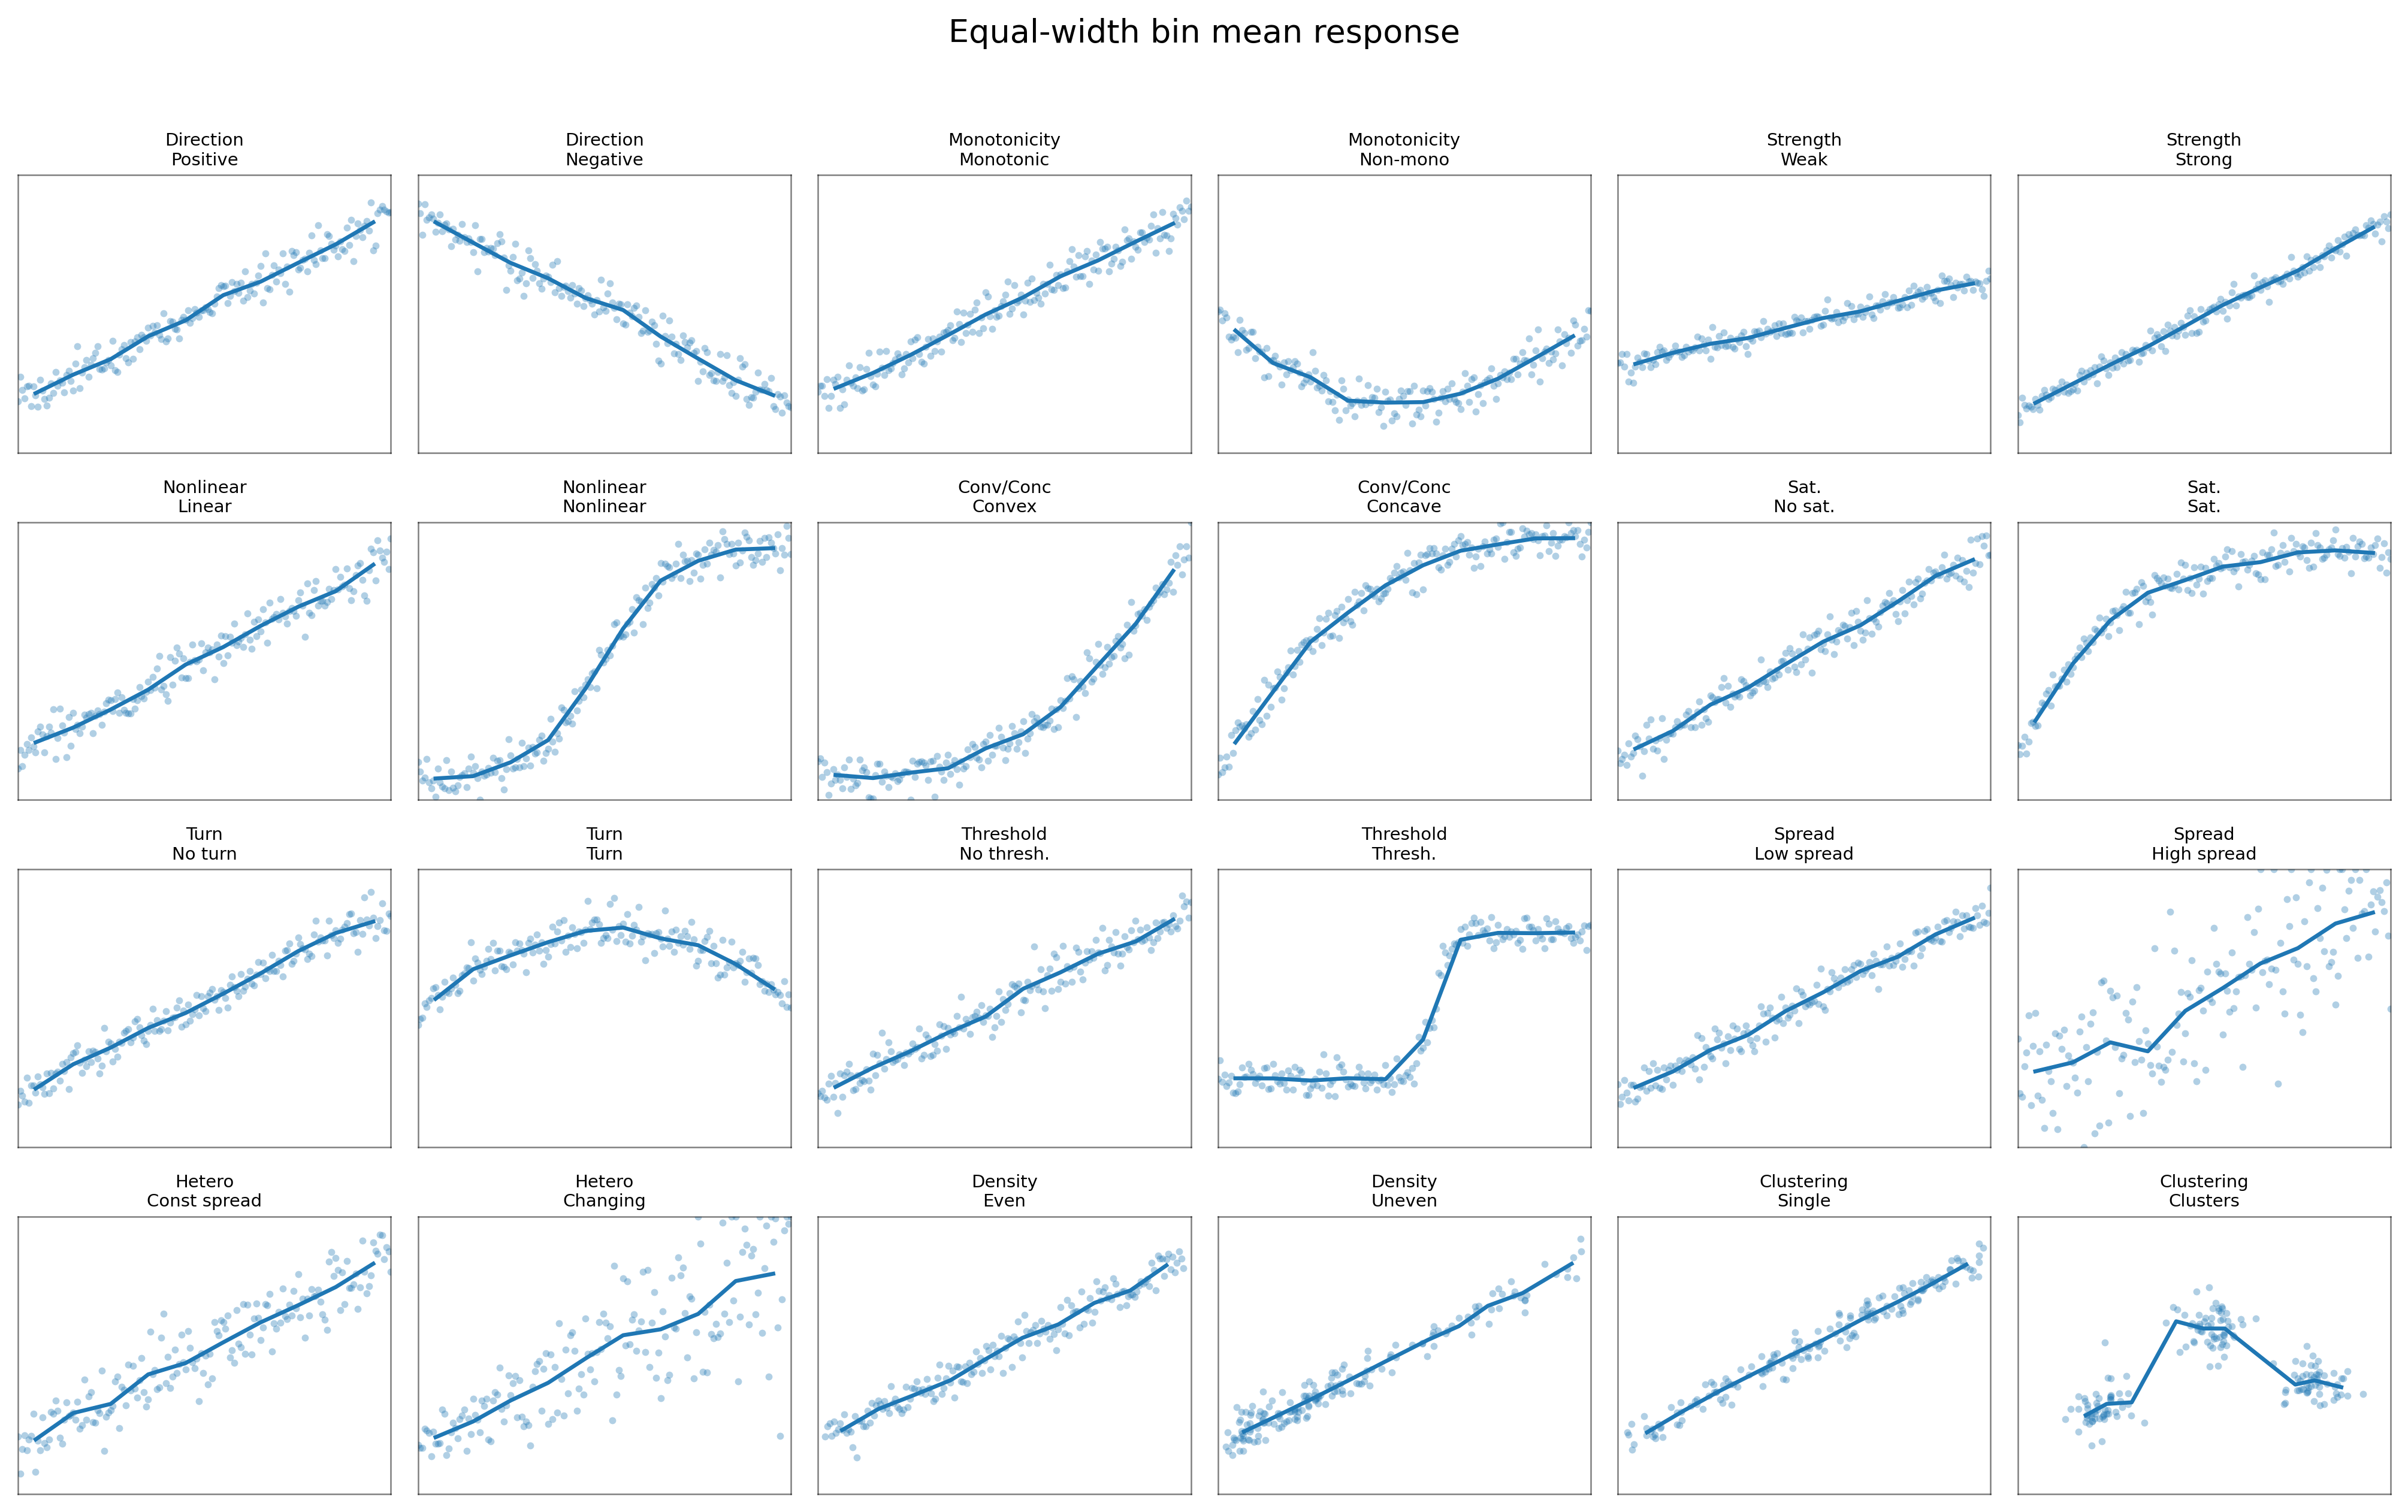

Equal-width bin mean response figure saved to: ./output/plot_metric_data_24_cases_equal_width_bin_mean_response.png


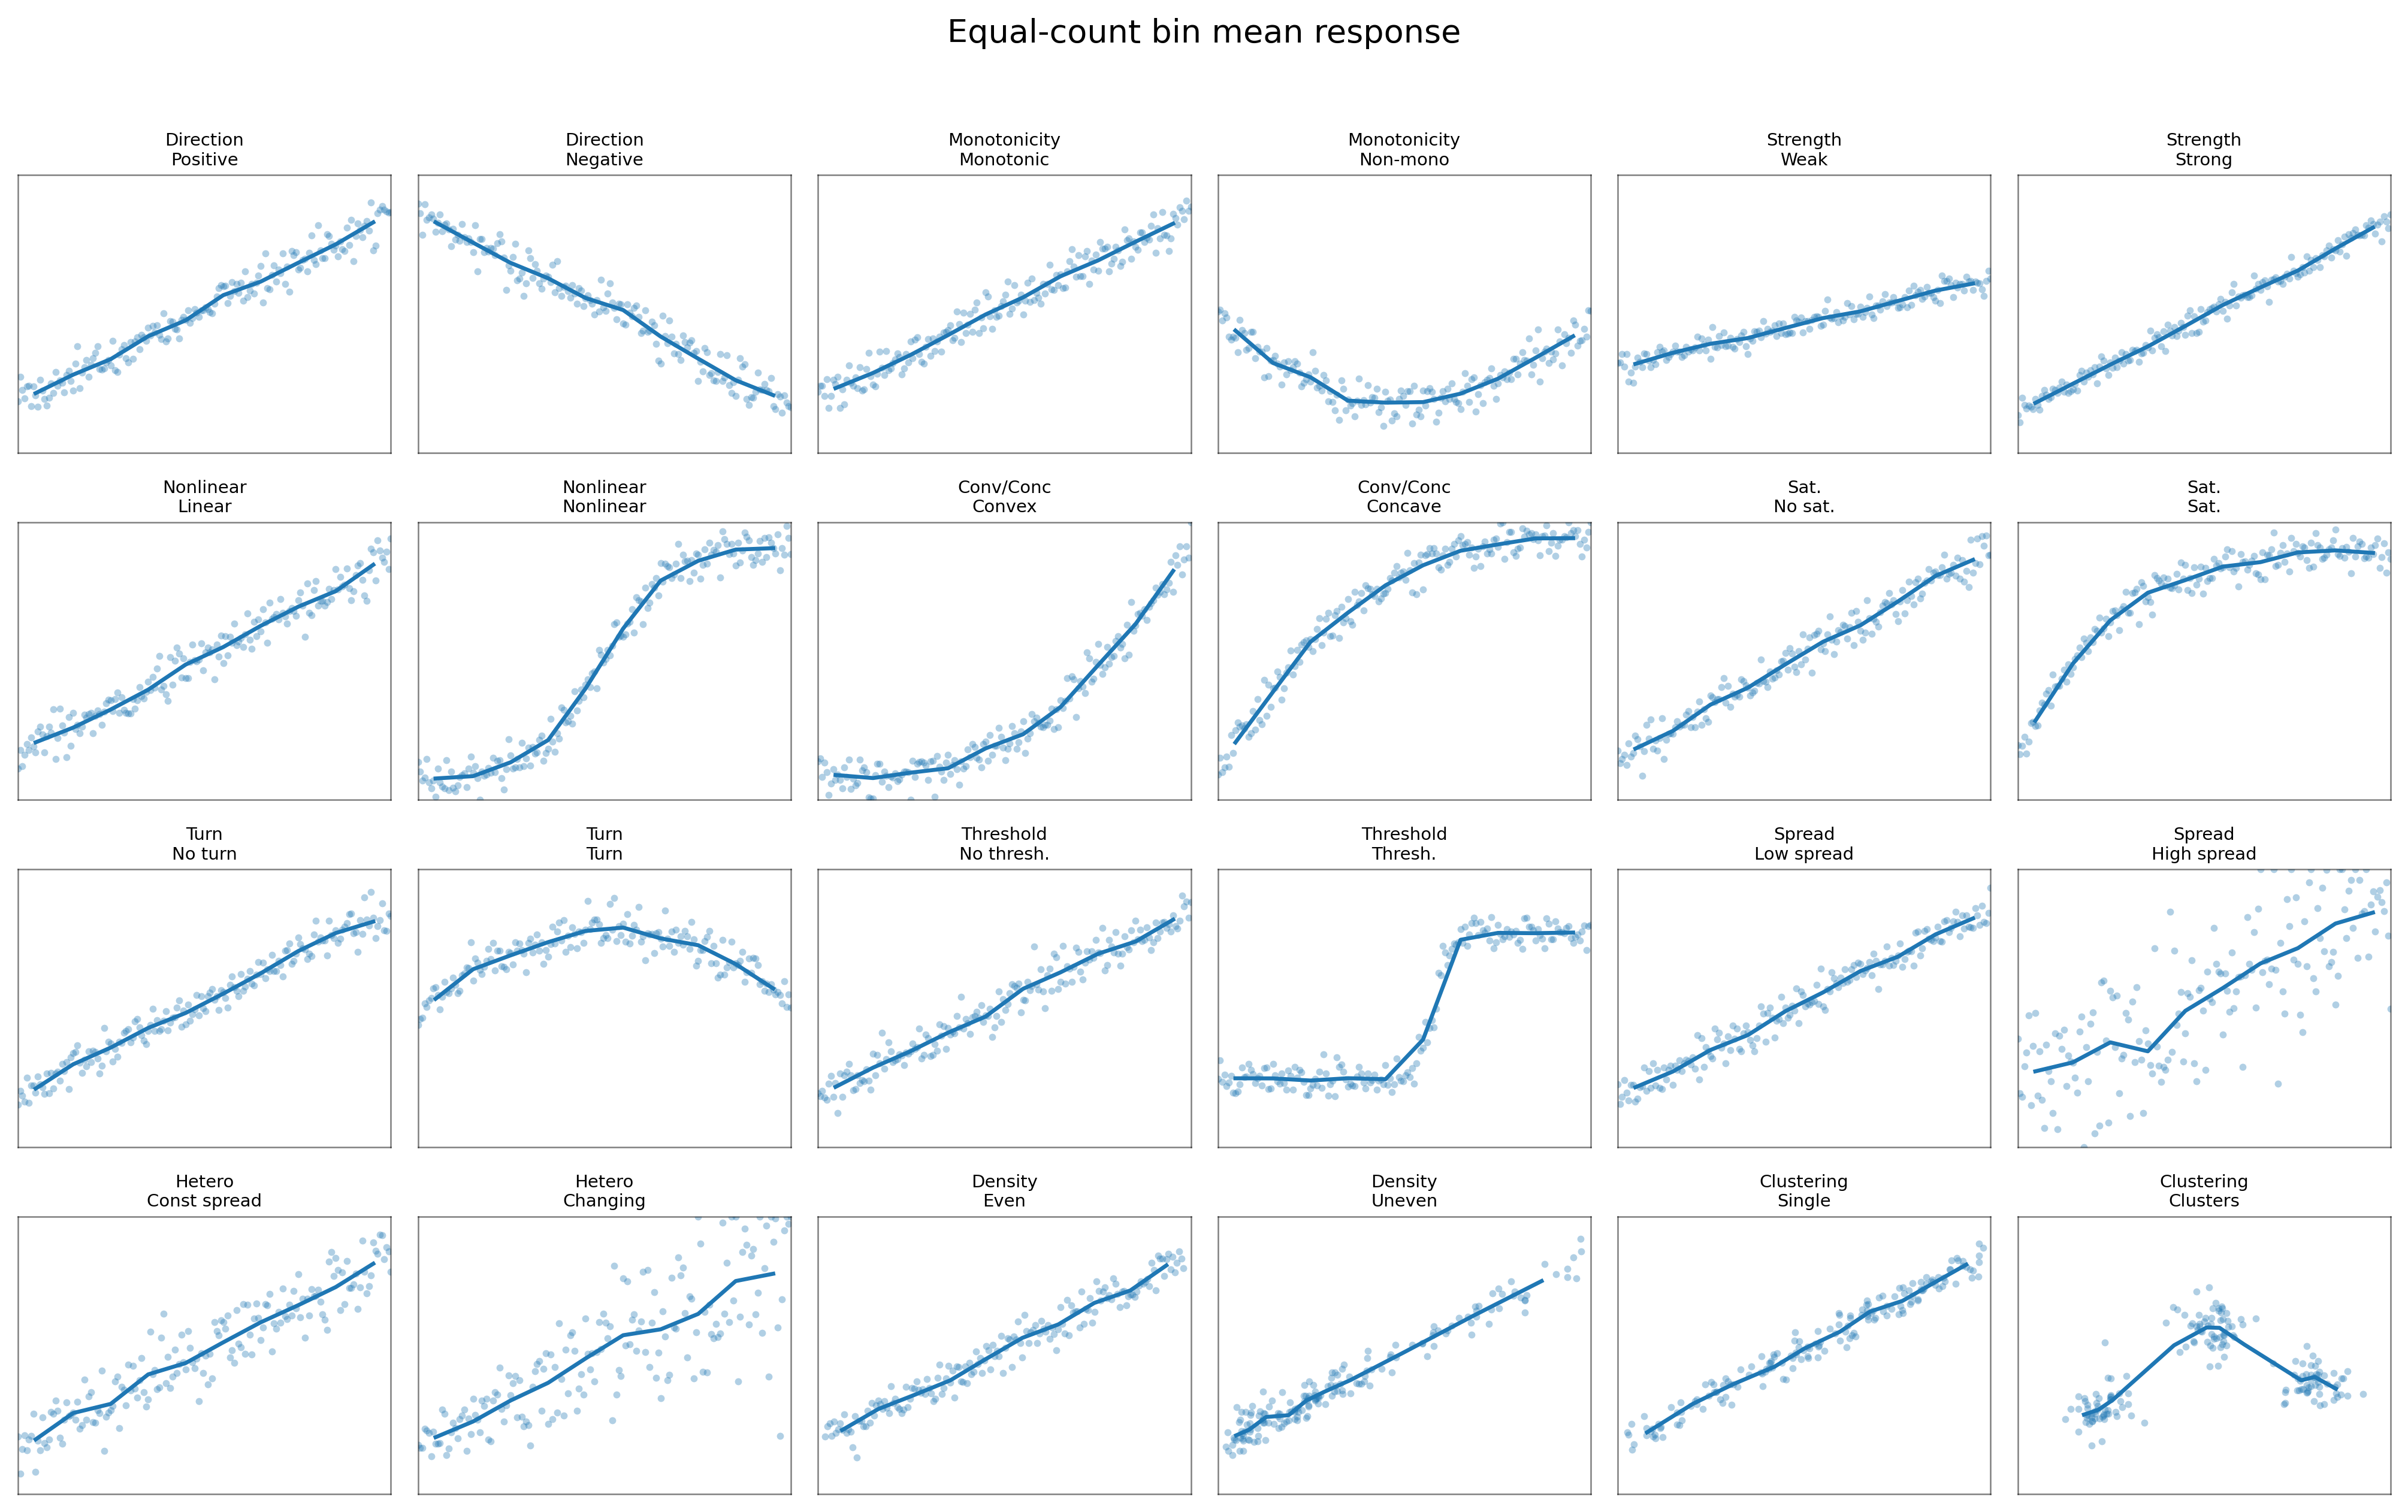

Equal-count bin mean response figure saved to: ./output/plot_metric_data_24_cases_equal_count_bin_mean_response.png


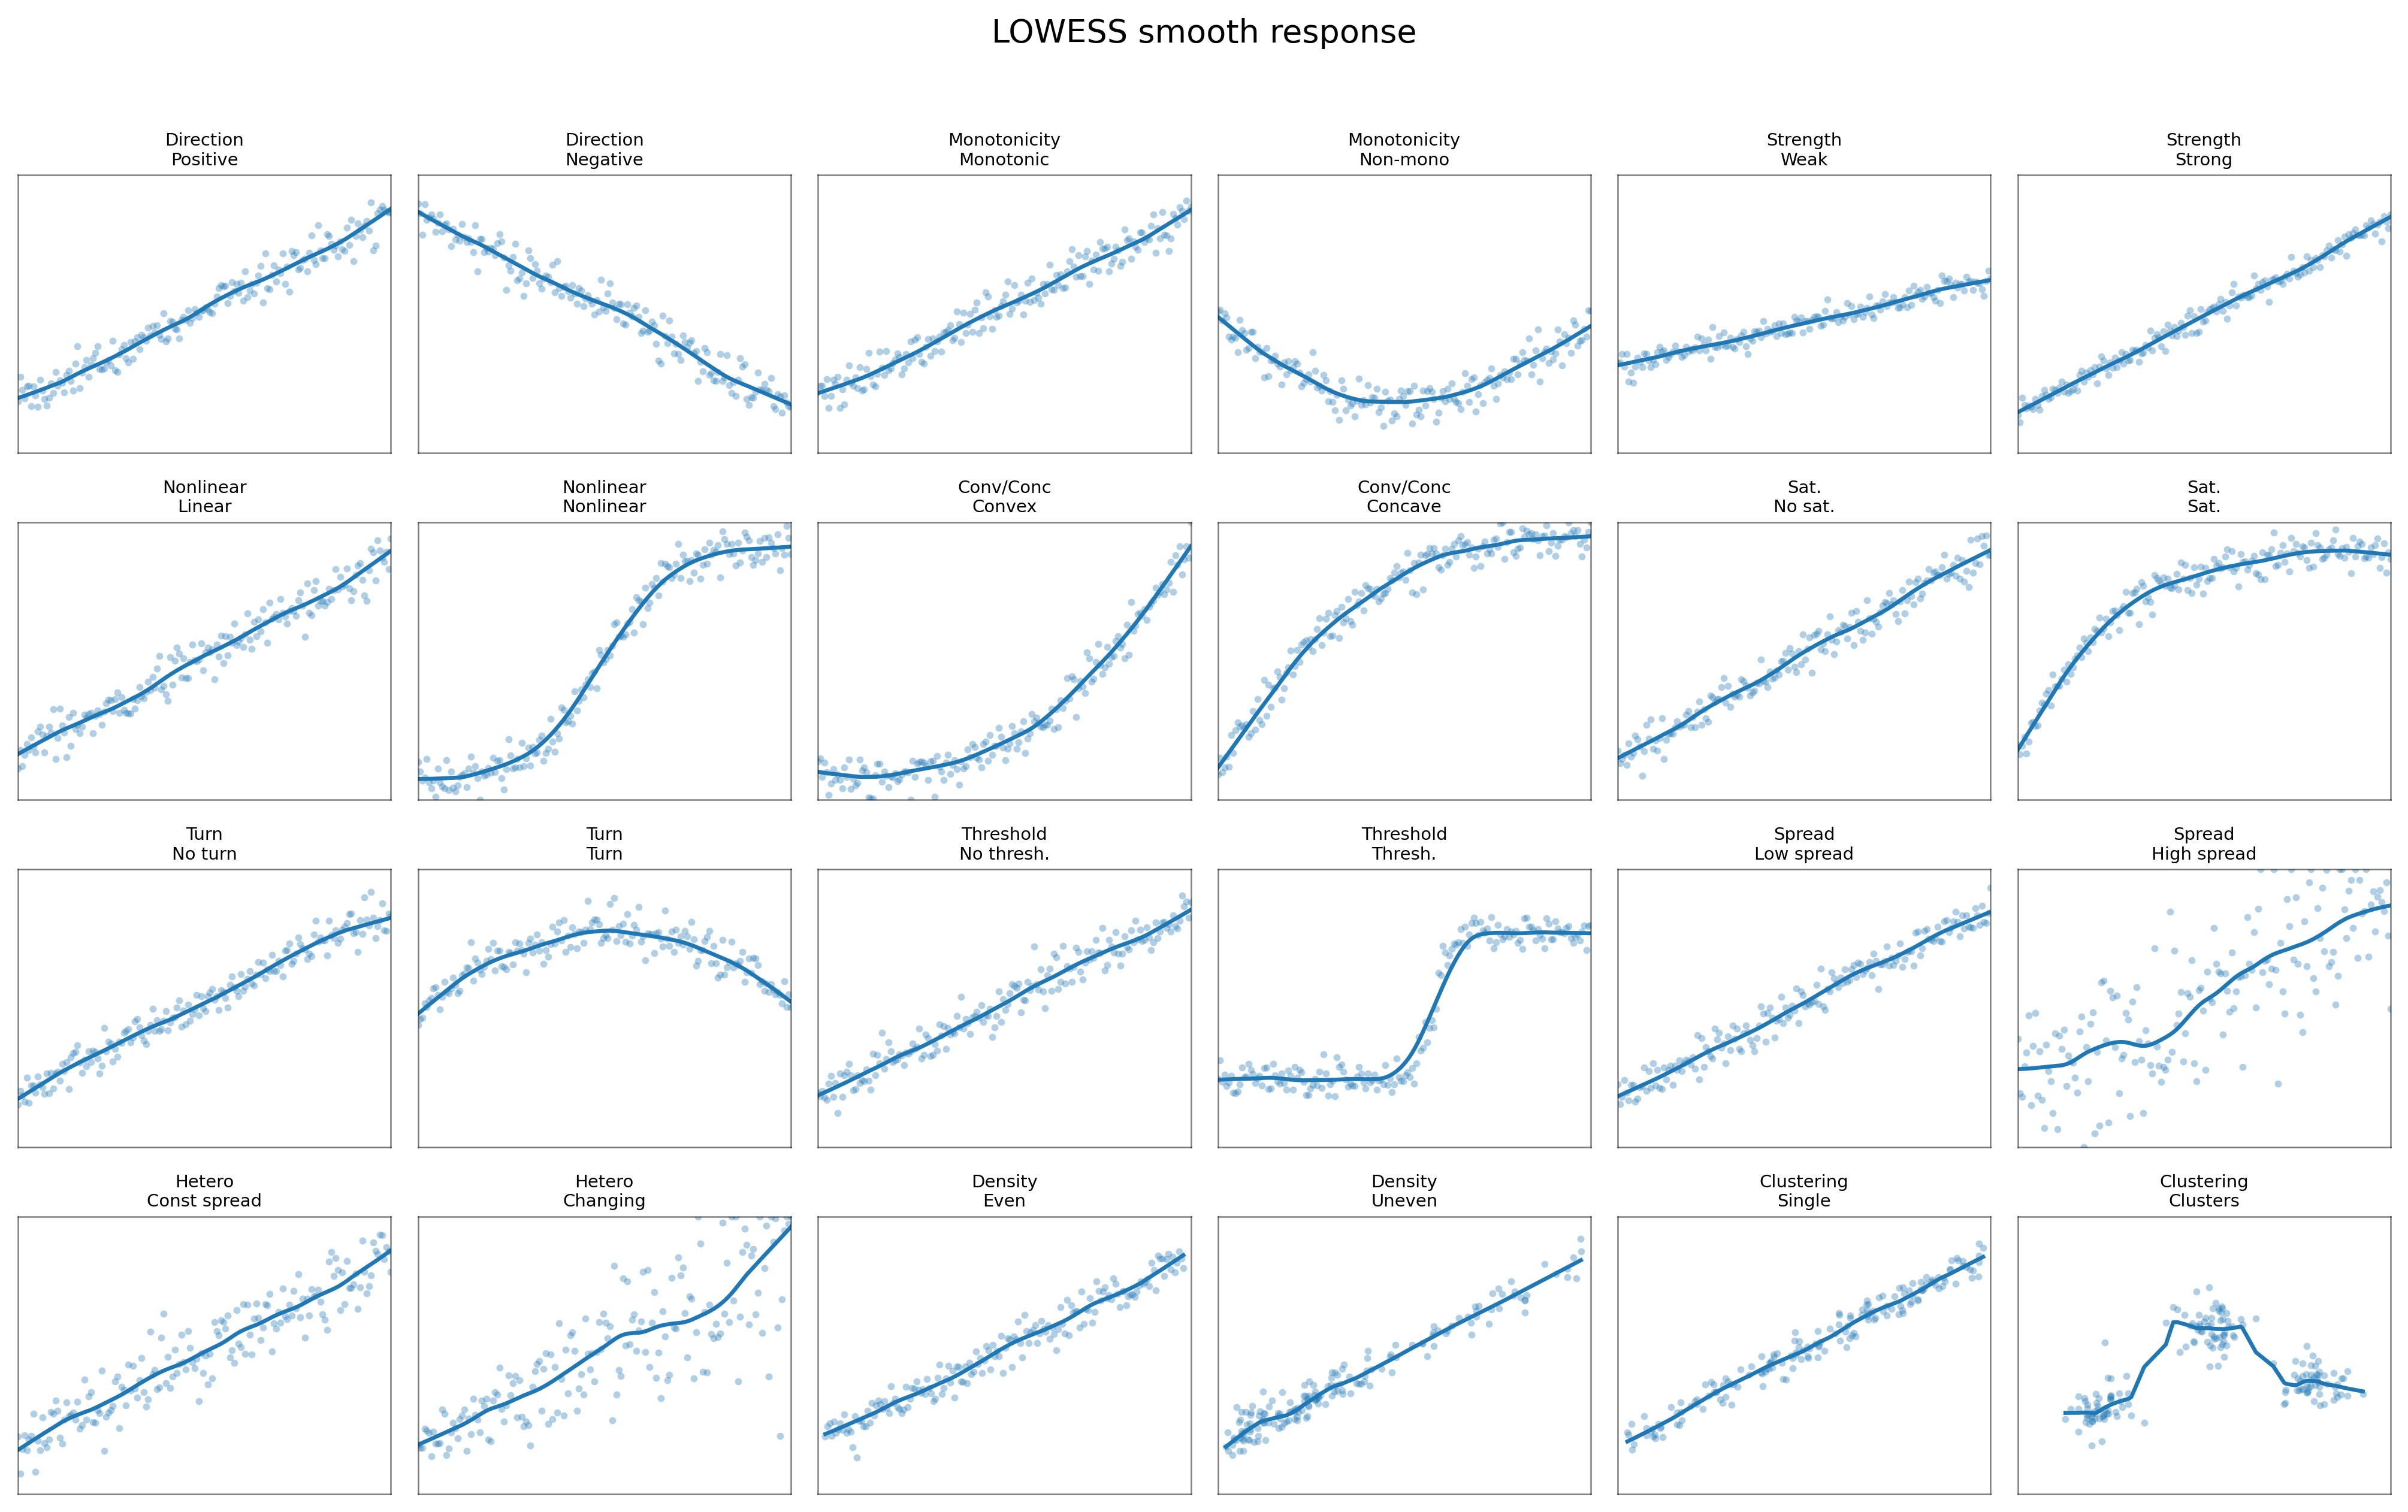

LOWESS smooth response figure saved to: ./output/plot_metric_data_24_cases_lowess_smooth_response.png


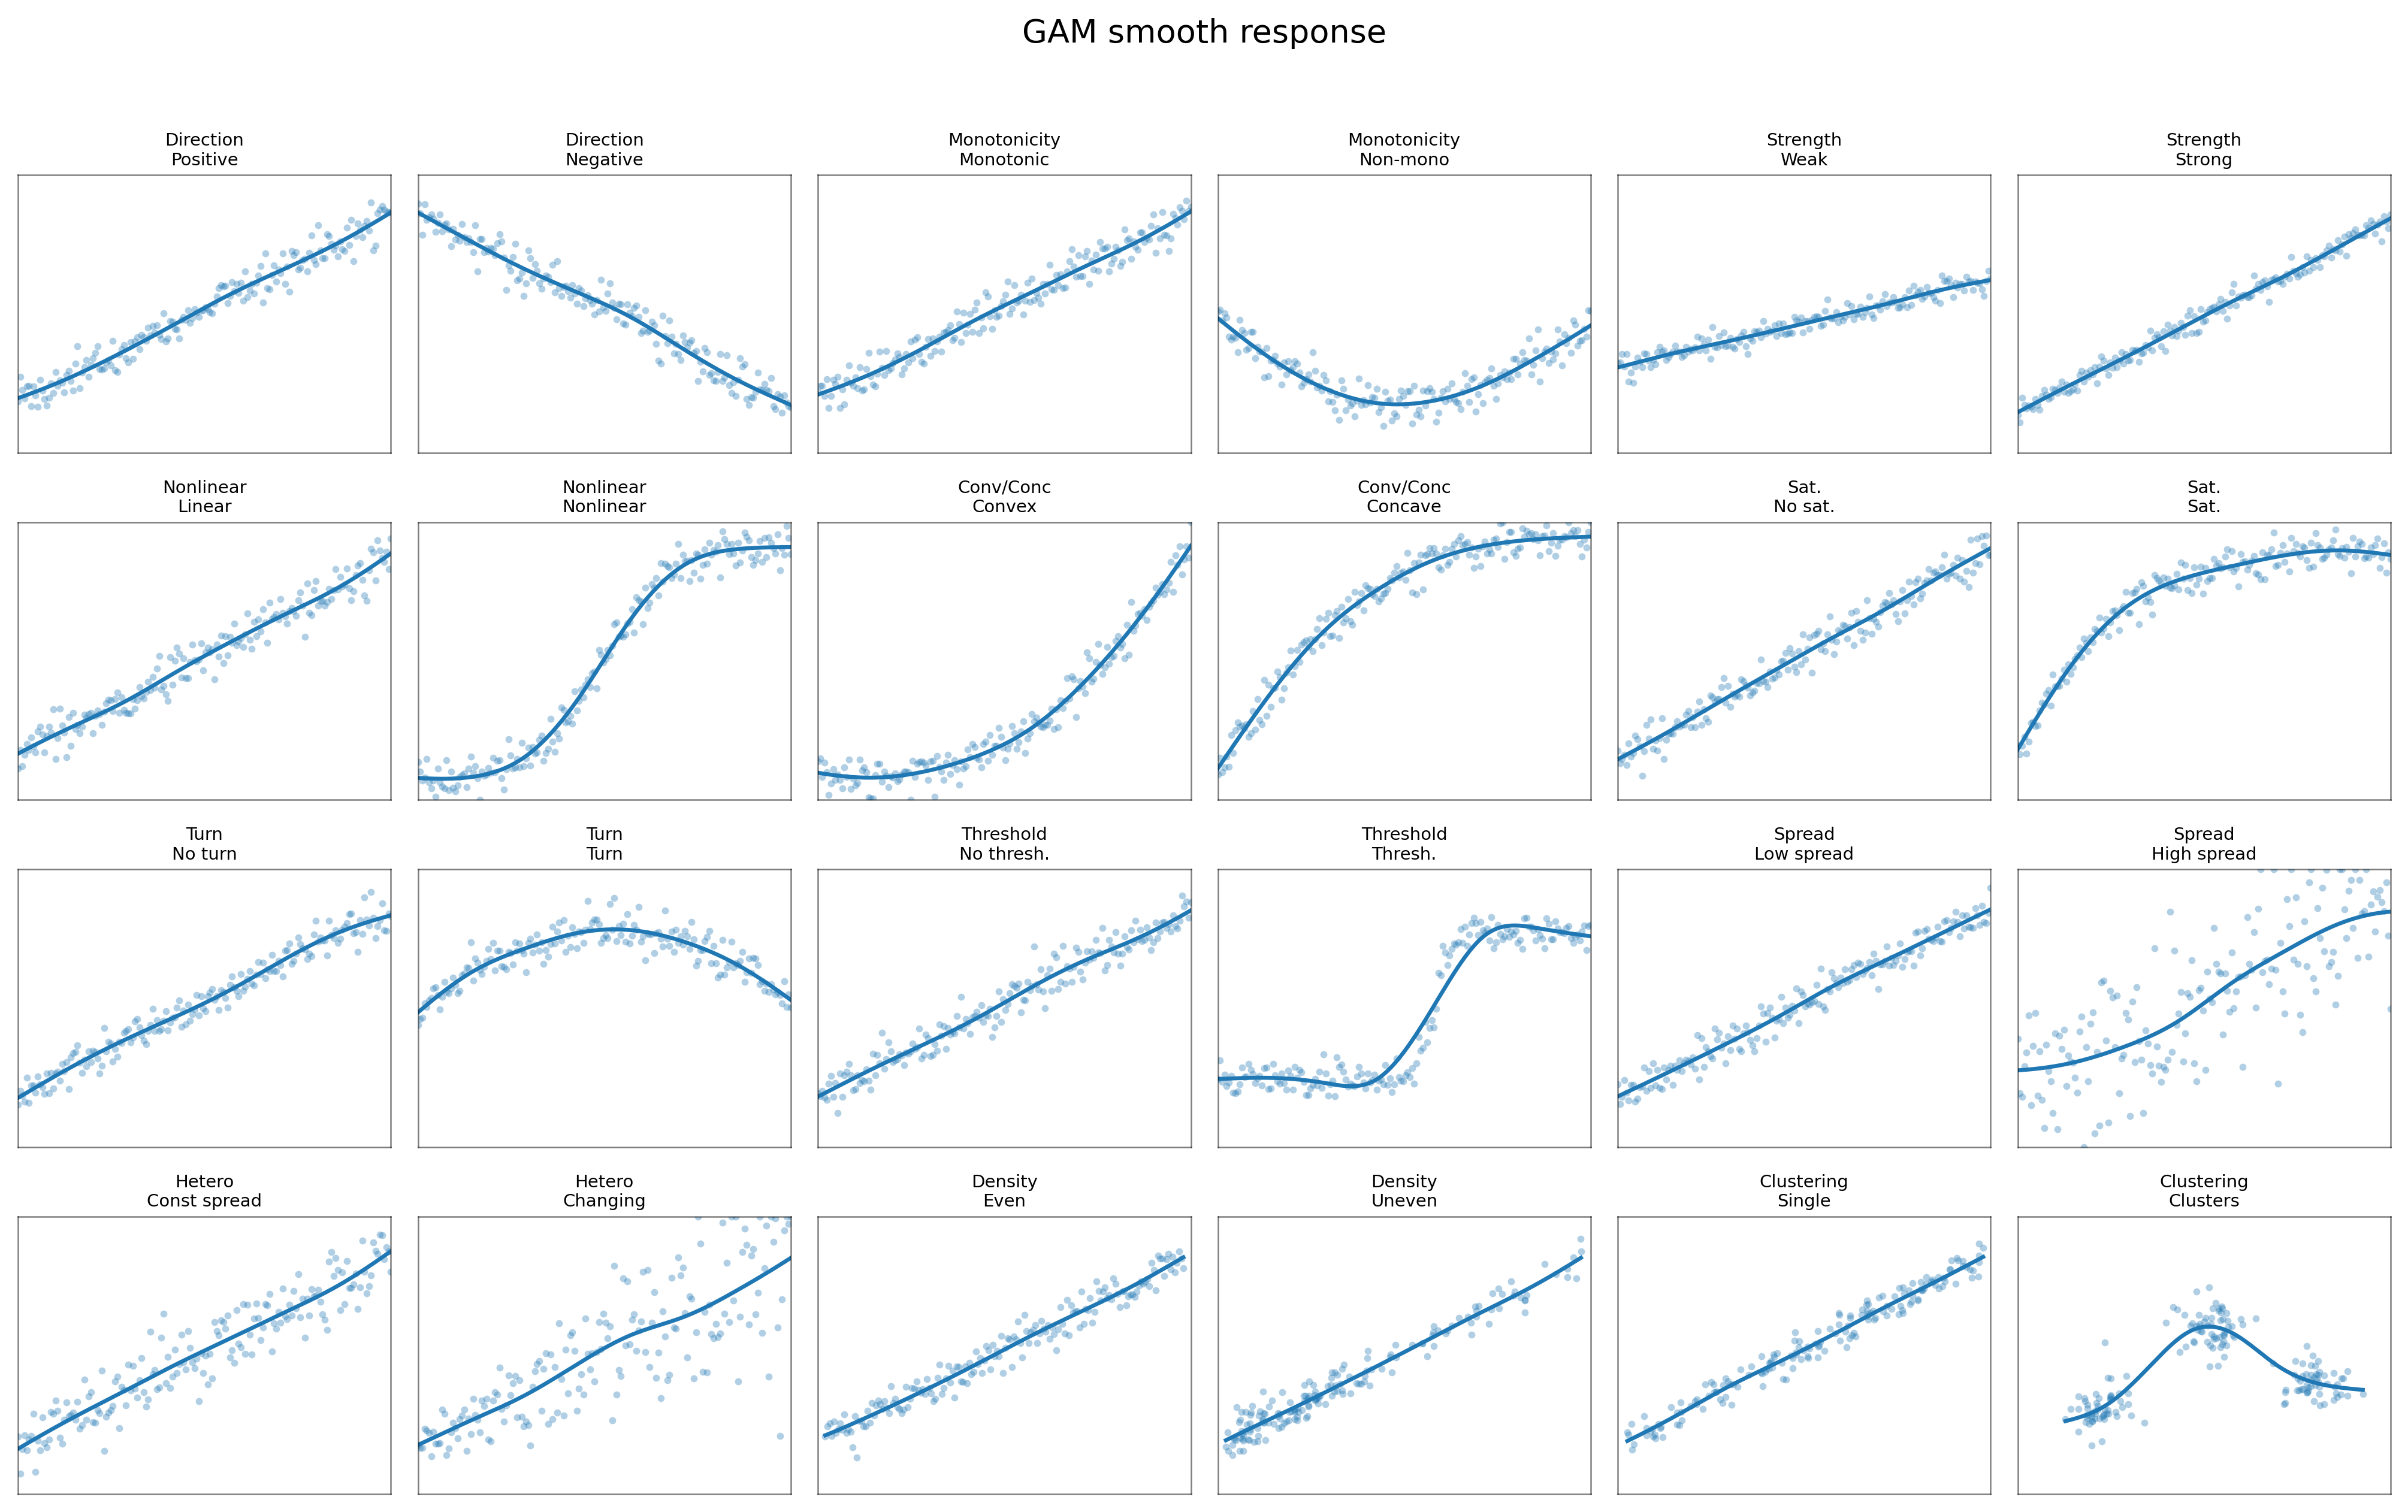

GAM smooth response figure saved to: ./output/plot_metric_data_24_cases_gam_smooth_response.png


In [34]:
# ==========================================================
# Plot fitting lines from plot_metric_data
# ==========================================================
# This code uses the final scatter points stored in plot_metric_data.
# It does NOT use the base curves directly.
#
# It generates four figures:
# 1. Equal-width bin mean response
# 2. Equal-count bin mean response
# 3. LOWESS smooth response
# 4. GAM smooth response
# ==========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.nonparametric.smoothers_lowess import lowess


# ==========================================================
# 1. Basic helper functions
# ==========================================================

def _to_valid_arrays(x, y):
    """
    Convert x and y to valid numeric arrays.
    Remove NaN and infinite values.
    """
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()

    valid = np.isfinite(x) & np.isfinite(y)

    return x[valid], y[valid]


def _make_bins(x, n_bins=10, bin_type="equal_width"):
    """
    Create bin labels for x.

    equal_width:
        divide X range into equal-width intervals.

    equal_count:
        divide X into quantile bins with similar numbers of points.
    """
    x = np.asarray(x, dtype=float)

    if bin_type == "equal_width":
        bins = pd.cut(
            x,
            bins=n_bins,
            labels=False,
            include_lowest=True,
            duplicates="drop",
        )

    elif bin_type == "equal_count":
        bins = pd.qcut(
            x,
            q=n_bins,
            labels=False,
            duplicates="drop",
        )

    else:
        raise ValueError("bin_type must be 'equal_width' or 'equal_count'.")

    return np.asarray(bins, dtype=float)


# ==========================================================
# 2. Equal-width / equal-count bin mean fitting
# ==========================================================

def fit_bin_mean_curve_same_as_metrics(
    x,
    y,
    n_bins=10,
    bin_type="equal_width",
    min_count_per_bin=5,
):
    """
    Fit a bin-mean response line using the same logic as metric calculation.

    For each X bin:
    - calculate mean X
    - calculate mean Y
    - connect these bin means as the fitted response line.

    Parameters
    ----------
    x, y : array-like
        Scatter points.
    n_bins : int
        Number of bins.
    bin_type : str
        "equal_width" or "equal_count".
    min_count_per_bin : int
        Minimum number of points required in a bin.

    Returns
    -------
    x_fit, y_fit : ndarray
        Bin mean X and bin mean Y.
    """
    x, y = _to_valid_arrays(x, y)

    if len(x) < n_bins:
        return np.array([]), np.array([])

    bins = _make_bins(
        x,
        n_bins=n_bins,
        bin_type=bin_type,
    )

    df_bin = pd.DataFrame({
        "x": x,
        "y": y,
        "bin": bins,
    }).dropna()

    if df_bin.empty:
        return np.array([]), np.array([])

    bin_stats = []

    for bin_id, g in df_bin.groupby("bin", observed=True):
        if len(g) < min_count_per_bin:
            continue

        bin_stats.append({
            "bin": bin_id,
            "x_mean": np.nanmean(g["x"]),
            "y_mean": np.nanmean(g["y"]),
            "count": len(g),
        })

    if len(bin_stats) < 2:
        return np.array([]), np.array([])

    bin_df = (
        pd.DataFrame(bin_stats)
        .sort_values("x_mean")
        .reset_index(drop=True)
    )

    x_fit = bin_df["x_mean"].to_numpy(dtype=float)
    y_fit = bin_df["y_mean"].to_numpy(dtype=float)

    return x_fit, y_fit


# ==========================================================
# 3. LOWESS fitting
# ==========================================================

def fit_lowess_curve_for_plot(
    x,
    y,
    frac=0.25,
):
    """
    Fit LOWESS smooth curve.
    """
    x, y = _to_valid_arrays(x, y)

    if len(x) < 5:
        return np.array([]), np.array([])

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    fitted = lowess(
        endog=y_sorted,
        exog=x_sorted,
        frac=frac,
        return_sorted=True,
    )

    return fitted[:, 0], fitted[:, 1]


# ==========================================================
# 4. GAM fitting
# ==========================================================

def fit_gam_curve_for_plot(
    x,
    y,
    n_splines=10,
    lam=0.6,
    grid_size=200,
):
    """
    Fit GAM smooth curve using pygam.

    If pygam is unavailable, this function returns empty arrays.
    It does not use polynomial fallback, because that would not be GAM.
    """
    x, y = _to_valid_arrays(x, y)

    if len(x) < 10:
        return np.array([]), np.array([])

    try:
        from pygam import LinearGAM, s

        X = x.reshape(-1, 1)

        gam = LinearGAM(
            s(0, n_splines=n_splines),
            lam=lam,
        ).fit(X, y)

        x_curve = np.linspace(
            np.nanmin(x),
            np.nanmax(x),
            grid_size,
        )

        y_curve = gam.predict(
            x_curve.reshape(-1, 1)
        )

        return x_curve, y_curve

    except Exception as e:
        print(f"GAM unavailable or failed: {e}")
        return np.array([]), np.array([])


# ==========================================================
# 5. Title helper
# ==========================================================

def shorten_case_title(prop, case):
    """
    Shorten subplot titles.
    """
    replacements = {
        "Direction": "Direction",
        "Monotonicity": "Monotonicity",
        "Strength": "Strength",
        "Non-linearity": "Nonlinear",
        "Convexity / Concavity": "Conv/Conc",
        "Saturation": "Saturation",
        "Turning point": "Turning",
        "Threshold": "Threshold",
        "Spread": "Spread",
        "Heteroscedasticity": "Hetero",
        "Density": "Density",
        "Clustering": "Clustering",
        "Certainty": "Certainty",

        "Positive direction": "Positive",
        "Negative direction": "Negative",
        "Monotonic": "Monotonic",
        "Non-monotonic": "Non-mono",
        "Weak response": "Weak",
        "Strong response": "Strong",
        "Linear": "Linear",
        "Non-linear": "Nonlinear",
        "Convex": "Convex",
        "Concave": "Concave",
        "No saturation": "No sat.",
        "Saturation": "Sat.",
        "No turning point": "No turn",
        "Turning point": "Turn",
        "No threshold": "No thresh.",
        "Threshold-like change": "Thresh.",
        "Low spread": "Low spread",
        "High spread": "High spread",
        "Constant spread": "Const spread",
        "Changing spread": "Changing",
        "Even coverage": "Even",
        "Uneven coverage": "Uneven",
        "Single cloud": "Single",
        "Separated clusters": "Clusters",
        "High certainty": "High cert.",
        "Low certainty": "Low cert.",
    }

    prop_short = replacements.get(prop, prop)
    case_short = replacements.get(case, case)

    return f"{prop_short}\n{case_short}"


# ==========================================================
# 6. Main plotting function
# ==========================================================

def plot_all_cases_with_fit_from_plot_metric_data(
    plot_metric_data,
    fit_method,
    method_name,
    output_dir="./output",
    n_cols=6,
    point_size=8,
    point_alpha=0.35,
    line_width=1.6,
    include_certainty=False,
):
    """
    Plot all conceptual cases using final scatter points stored in plot_metric_data.

    This is the safest version because plot_metric_data already contains
    the scatter points used for metric calculation.

    If include_certainty=False:
        12 properties × 2 cases = 24 plots

    If include_certainty=True:
        13 properties × 2 cases = 26 plots
    """

    plot_items = []

    for prop, data in plot_metric_data.items():
        if (not include_certainty) and prop == "Certainty":
            continue

        # Left case
        plot_items.append({
            "property": prop,
            "case": data["left_title"],
            "side": "left",
            "x": data["left"]["x"],
            "y": data["left"]["y"],
        })

        # Right case
        plot_items.append({
            "property": prop,
            "case": data["right_title"],
            "side": "right",
            "x": data["right"]["x"],
            "y": data["right"]["y"],
        })

    n_cases = len(plot_items)
    n_rows = int(np.ceil(n_cases / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(n_cols * 2.25, n_rows * 2.05),
        dpi=300,
    )

    axes = np.asarray(axes).reshape(-1)

    for i, item in enumerate(plot_items):
        ax = axes[i]

        x = np.asarray(item["x"], dtype=float)
        y = np.asarray(item["y"], dtype=float)

        x, y = _to_valid_arrays(x, y)

        # Scatter points
        ax.scatter(
            x,
            y,
            s=point_size,
            alpha=point_alpha,
            linewidths=0,
        )

        # Fitted line
        x_fit, y_fit = fit_method(x, y)

        if x_fit is not None and y_fit is not None:
            x_fit = np.asarray(x_fit, dtype=float)
            y_fit = np.asarray(y_fit, dtype=float)

            valid_fit = np.isfinite(x_fit) & np.isfinite(y_fit)

            if valid_fit.sum() >= 2:
                order = np.argsort(x_fit[valid_fit])

                ax.plot(
                    x_fit[valid_fit][order],
                    y_fit[valid_fit][order],
                    linewidth=line_width,
                )

        ax.set_title(
            shorten_case_title(
                item["property"],
                item["case"],
            ),
            fontsize=7,
            pad=4,
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)

        ax.set_xticks([])
        ax.set_yticks([])

        for spine in ax.spines.values():
            spine.set_linewidth(0.6)
            spine.set_alpha(0.5)

    # Remove empty axes
    for j in range(n_cases, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        method_name,
        fontsize=13,
        y=1.02,
    )

    plt.tight_layout()

    os.makedirs(output_dir, exist_ok=True)

    safe_name = (
        method_name.lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
    )

    output_path = os.path.join(
        output_dir,
        f"plot_metric_data_24_cases_{safe_name}.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(f"{method_name} figure saved to: {output_path}")


# ==========================================================
# 7. Plot four fitting-method figures
# ==========================================================

output_dir = "./output"

# ----------------------------------------------------------
# Figure 1. Equal-width bin mean response
# ----------------------------------------------------------
plot_all_cases_with_fit_from_plot_metric_data(
    plot_metric_data=plot_metric_data,
    fit_method=lambda x, y: fit_bin_mean_curve_same_as_metrics(
        x,
        y,
        n_bins=10,
        bin_type="equal_width",
        min_count_per_bin=5,
    ),
    method_name="Equal-width bin mean response",
    output_dir=output_dir,
    n_cols=6,
    include_certainty=False,
)


# ----------------------------------------------------------
# Figure 2. Equal-count bin mean response
# ----------------------------------------------------------
plot_all_cases_with_fit_from_plot_metric_data(
    plot_metric_data=plot_metric_data,
    fit_method=lambda x, y: fit_bin_mean_curve_same_as_metrics(
        x,
        y,
        n_bins=10,
        bin_type="equal_count",
        min_count_per_bin=5,
    ),
    method_name="Equal-count bin mean response",
    output_dir=output_dir,
    n_cols=6,
    include_certainty=False,
)


# ----------------------------------------------------------
# Figure 3. LOWESS smooth response
# ----------------------------------------------------------
plot_all_cases_with_fit_from_plot_metric_data(
    plot_metric_data=plot_metric_data,
    fit_method=lambda x, y: fit_lowess_curve_for_plot(
        x,
        y,
        frac=0.25,
    ),
    method_name="LOWESS smooth response",
    output_dir=output_dir,
    n_cols=6,
    include_certainty=False,
)


# ----------------------------------------------------------
# Figure 4. GAM smooth response
# ----------------------------------------------------------
plot_all_cases_with_fit_from_plot_metric_data(
    plot_metric_data=plot_metric_data,
    fit_method=lambda x, y: fit_gam_curve_for_plot(
        x,
        y,
        n_splines=10,
        lam=0.6,
        grid_size=200,
    ),
    method_name="GAM smooth response",
    output_dir=output_dir,
    n_cols=6,
    include_certainty=False,
)

In [16]:
# # ==========================================================
# # 10. Mixed normalization for visualization and distance analysis
# # ==========================================================
# # This block should be run after selected_metrics_df has been created.
# #
# # Rule:
# # 1. Signed metrics are normalized by max absolute value and kept in [-1, 1].
# #    This preserves direction/sign information.
# #
# # 2. Non-negative / unsigned metrics are normalized by Min-Max to [0, 1].
# #
# # 3. ID columns and non-informative columns are kept unchanged or excluded.

# def normalize_metric_columns_preserve_sign(df, id_cols):
#     """
#     Normalize metric columns while preserving sign information.

#     Signed metrics:
#         value / max(abs(value))  -> range [-1, 1]

#     Unsigned metrics:
#         (value - min) / (max - min) -> range [0, 1]

#     ID columns are kept unchanged.
#     """
#     out = df.copy()

#     # ------------------------------------------------------
#     # Signed metrics: preserve positive / negative meaning
#     # ------------------------------------------------------
#     signed_metric_cols = [
#         # Correlation-based signed metrics
#         "pearson_r",
#         "spearman_rho",
#         "covariance",

#         # Raw slope-based signed metrics
#         "raw_overall_slope",
#         "raw_early_slope",
#         "raw_middle_slope",
#         "raw_late_slope",

#         # Min-max normalized slope-based signed metrics
#         "standardized_overall_slope",
#         "standardized_early_slope",
#         "standardized_middle_slope",
#         "standardized_late_slope",

#         # MIC minus r2 can theoretically be negative
#         "MIC_minus_r2",
#     ]

#     signed_metric_cols = [
#         c for c in signed_metric_cols
#         if c in out.columns
#     ]

#     # ------------------------------------------------------
#     # Columns that should not be normalized for distance
#     # ------------------------------------------------------
#     exclude_metric_cols = [
#         # sample-size / bookkeeping columns
#         "n_valid",
#         "equal_width_bin_n_valid_bins",
#         "equal_count_bin_n_valid_bins",

#         # scale reference, not a response metric for similarity
#         "y_sd",
#     ]

#     exclude_metric_cols = [
#         c for c in exclude_metric_cols
#         if c in out.columns
#     ]

#     # ------------------------------------------------------
#     # Other metric columns are treated as unsigned
#     # ------------------------------------------------------
#     metric_cols = [
#         c for c in out.columns
#         if c not in id_cols
#         and c not in exclude_metric_cols
#     ]

#     unsigned_metric_cols = [
#         c for c in metric_cols
#         if c not in signed_metric_cols
#     ]

#     # ------------------------------------------------------
#     # Normalize signed metrics to [-1, 1]
#     # ------------------------------------------------------
#     for c in signed_metric_cols:
#         values = pd.to_numeric(out[c], errors="coerce")

#         max_abs = np.nanmax(np.abs(values))

#         if not np.isfinite(max_abs) or max_abs == 0:
#             out[c] = np.nan
#         else:
#             out[c] = values / max_abs

#     # ------------------------------------------------------
#     # Normalize unsigned metrics to [0, 1]
#     # ------------------------------------------------------
#     for c in unsigned_metric_cols:
#         values = pd.to_numeric(out[c], errors="coerce")

#         v_min = np.nanmin(values)
#         v_max = np.nanmax(values)

#         if not np.isfinite(v_min) or not np.isfinite(v_max) or v_max == v_min:
#             out[c] = np.nan
#         else:
#             out[c] = (values - v_min) / (v_max - v_min)

#     return out, signed_metric_cols, unsigned_metric_cols, exclude_metric_cols


# id_cols = ["property", "case", "side"]

# normalized_metrics_df, signed_metric_cols, unsigned_metric_cols, exclude_metric_cols = (
#     normalize_metric_columns_preserve_sign(
#         selected_metrics_df,
#         id_cols=id_cols,
#     )
# )

# normalized_metrics_df_rounded = normalized_metrics_df.copy()

# numeric_cols = normalized_metrics_df_rounded.select_dtypes(include=[np.number]).columns
# normalized_metrics_df_rounded[numeric_cols] = (
#     normalized_metrics_df_rounded[numeric_cols].round(4)
# )

# print("Signed metrics normalized to [-1, 1]:")
# print(signed_metric_cols)

# print("\nUnsigned metrics normalized to [0, 1]:")
# print(unsigned_metric_cols)

# print("\nExcluded columns:")
# print(exclude_metric_cols)


# # ==========================================================
# # 11. Save normalized table as a separate Excel file
# # ==========================================================

# normalized_output_excel = os.path.join(
#     output_dir,
#     "normalized_metrics_preserve_sign.xlsx",
# )

# with pd.ExcelWriter(normalized_output_excel, engine="openpyxl") as writer:
#     normalized_metrics_df_rounded.to_excel(
#         writer,
#         sheet_name="normalized_preserve_sign",
#         index=False,
#     )

# print(f"Normalized Excel file saved to: {normalized_output_excel}")

# normalized_metrics_df_rounded

Signed metrics normalized to [-1, 1]:
['pearson_r', 'spearman_rho', 'covariance', 'raw_overall_slope', 'raw_early_slope', 'raw_middle_slope', 'raw_late_slope', 'standardized_overall_slope', 'standardized_early_slope', 'standardized_middle_slope', 'standardized_late_slope', 'MIC_minus_r2']

Unsigned metrics normalized to [0, 1]:
['distance_covariance', 'distance_correlation', 'x_uniform_ks_distance', 'equal_width_bin_x_bin_count_cv', 'equal_width_distribution_ks_distance', 'equal_width_distribution_wasserstein_distance', 'equal_width_distribution_wasserstein_distance_div_y_sd', 'equal_count_distribution_ks_distance', 'equal_count_distribution_wasserstein_distance', 'equal_count_distribution_wasserstein_distance_div_y_sd', 'raw_segment_strength', 'standardized_segment_strength', 'MIC', 'MAS', 'MEV', 'MCN', 'equal_width_bin_amplitude', 'equal_width_bin_amplitude_div_y_sd', 'equal_width_bin_eta_squared', 'equal_width_bin_buffer_width_mean', 'equal_width_bin_buffer_width_mean_div_y_sd', 'eq

,property,case,side,y_sd,pearson_r,spearman_rho,covariance,distance_covariance,distance_correlation,x_uniform_ks_distance,...,lowess_curve_amplitude_div_y_sd,lowess_r2,lowess_first_derivative_sign_changes,gam_residual_sd,gam_residual_sd_div_y_sd,gam_curve_amplitude,gam_curve_amplitude_div_y_sd,gam_r2,gam_first_derivative_sign_changes,n_valid
0,Direction,Positive direction,left,0.2006,0.9884,0.9892,0.5996,0.6431,0.9806,0.0000,...,0.7959,0.9402,0.0000,0.1077,0.1451,0.6895,0.7749,0.9395,0.0000,170
1,Direction,Negative direction,right,0.2061,-0.9861,-0.9873,-0.6146,0.6493,0.9693,0.0000,...,0.7764,0.9311,0.0000,0.1282,0.1612,0.7350,0.7959,0.9310,0.0000,170
2,Monotonicity,Monotonic,left,0.1979,0.9871,0.9874,0.5907,0.6351,0.9749,0.0000,...,0.7572,0.9325,0.0000,0.1141,0.1588,0.6728,0.7751,0.9323,0.0000,170
3,Monotonicity,Non-monotonic,right,0.1011,-0.0017,0.0116,-0.0005,0.0170,0.0048,0.0000,...,0.5733,0.6069,0.0667,0.1254,0.5632,0.0214,0.5859,0.6046,0.3333,170
4,Strength,Weak response,left,0.0953,0.9749,0.9781,0.2811,0.3441,0.9554,0.0000,...,0.6866,0.8665,0.0000,0.0010,0.2663,0.0297,0.7546,0.8670,0.0000,170
5,Strength,Strong response,right,0.2031,1.0000,1.0000,0.6143,0.6617,1.0000,0.0000,...,0.8384,0.9999,0.0000,0.0000,0.0000,0.7454,0.8511,1.0000,0.0000,170
6,Non-linearity,Linear,left,0.2121,0.9855,0.9872,0.6324,0.6644,0.9727,0.0000,...,0.8297,0.9247,0.0000,0.1466,0.1729,0.7883,0.8236,0.9247,0.0000,170
7,Non-linearity,Non-linear,right,0.3412,0.9689,0.9709,1.0000,1.0000,0.9646,0.0000,...,0.2096,1.0000,0.0667,0.1217,0.0000,0.9992,0.1347,1.0000,0.3333,170
8,Convexity / Concavity,Convex,left,0.2525,0.9211,0.9502,0.7033,0.6979,0.8991,0.0000,...,0.7295,0.9687,0.0667,0.1219,0.0822,0.9996,0.7555,0.9692,0.3333,170
9,Convexity / Concavity,Concave,right,0.2483,0.9267,0.9595,0.6959,0.6920,0.9068,0.0000,...,0.7721,0.9732,0.0000,0.1075,0.0722,1.0000,0.7963,0.9735,0.0000,170


In [35]:
# ==========================================================
# 12. Compute Euclidean distance matrix between cases
#     using raw metric values
# ==========================================================
# Each row is treated as a raw metric vector.
#
# Important:
# - This version does NOT normalize metrics.
# - Metrics with larger numeric scales will dominate the distance.
# - Use this only when you want to inspect distance based on original values.
#
# Input:
# - raw_metrics_df: original metric table without normalization
#
# Output:
# - raw_distance_matrix_df: 24 × 24 case-by-case Euclidean distance matrix
# ==========================================================

import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform


# ----------------------------------------------------------
# 1. Choose the raw metric table
# ----------------------------------------------------------
# Change this to your actual original metric dataframe name.
# For example:
# raw_metrics_df = selected_metrics_df.copy()
# raw_metrics_df = no_certainty_df.copy()
# raw_metrics_df = metric_summary_df.copy()

raw_metrics_df = selected_metrics_df.copy()


# ----------------------------------------------------------
# 2. ID columns
# ----------------------------------------------------------

id_cols = ["property", "case", "side"]


# ----------------------------------------------------------
# 3. Use metric columns only
# ----------------------------------------------------------

metric_cols = [
    c for c in raw_metrics_df.columns
    if c not in id_cols
]


# ----------------------------------------------------------
# 4. Build case labels
# ----------------------------------------------------------

case_labels = (
    raw_metrics_df["property"].astype(str)
    + " | "
    + raw_metrics_df["case"].astype(str)
)


# ----------------------------------------------------------
# 5. Convert raw metric table to numeric matrix
# ----------------------------------------------------------

X_raw = raw_metrics_df[metric_cols].apply(
    pd.to_numeric,
    errors="coerce"
)


# ----------------------------------------------------------
# 6. Drop columns that are completely NaN
# ----------------------------------------------------------

all_nan_cols = X_raw.columns[X_raw.isna().all()].tolist()

if len(all_nan_cols) > 0:
    print("Dropped all-NaN metric columns:")
    print(all_nan_cols)

    X_raw = X_raw.drop(columns=all_nan_cols)


# ----------------------------------------------------------
# 7. Fill remaining NaN with column mean
# ----------------------------------------------------------

X_filled = X_raw.copy()

for c in X_filled.columns:
    col_mean = X_filled[c].mean(skipna=True)
    X_filled[c] = X_filled[c].fillna(col_mean)


# ----------------------------------------------------------
# 8. Compute Euclidean distance matrix using raw values
# ----------------------------------------------------------

raw_distance_array = squareform(
    pdist(X_filled.values, metric="euclidean")
)


raw_distance_matrix_df = pd.DataFrame(
    raw_distance_array,
    index=case_labels,
    columns=case_labels,
)


raw_distance_matrix_df_rounded = raw_distance_matrix_df.round(4)

raw_distance_matrix_df_rounded

,Direction | Positive direction,Direction | Negative direction,Monotonicity | Monotonic,Monotonicity | Non-monotonic,Strength | Weak response,Strength | Strong response,Non-linearity | Linear,Non-linearity | Non-linear,Convexity / Concavity | Convex,Convexity / Concavity | Concave,...,Threshold | No threshold,Threshold | Threshold-like change,Spread | Low spread,Spread | High spread,Heteroscedasticity | Constant spread,Heteroscedasticity | Changing spread,Density | Even coverage,Density | Uneven coverage,Clustering | Single cloud,Clustering | Separated clusters
Direction | Positive direction,0.0000,5.6119,0.6209,6.3237,1.6905,0.6765,0.8722,2.9642,2.2279,1.9059,...,0.8982,8.1692,0.6429,5.3995,1.8118,3.5668,0.6273,1.6306,0.7646,15.9312
Direction | Negative direction,5.6119,0.0000,5.3757,5.9132,4.8307,5.6144,5.9577,6.0069,5.8250,5.8002,...,5.3789,9.7043,5.4631,6.0253,5.0197,7.0745,5.2664,6.0746,5.3922,16.0486
Monotonicity | Monotonic,0.6209,5.3757,0.0000,6.2296,1.3082,1.0415,0.8655,3.0738,2.3196,1.6580,...,0.3712,8.2171,0.6431,5.1132,1.3385,3.4827,0.3314,1.5634,0.5918,15.8106
Monotonicity | Non-monotonic,6.3237,5.9132,6.2296,0.0000,5.8066,6.5373,6.4547,6.7076,5.3427,7.3025,...,6.3088,8.9901,6.1053,5.8693,6.0293,6.0946,6.1055,6.9865,6.3507,15.5227
Strength | Weak response,1.6905,4.8307,1.3082,5.8066,0.0000,1.8781,2.0057,3.5503,2.8250,2.3672,...,1.3230,8.3236,1.5577,4.8422,1.4666,3.9727,1.2569,2.3376,1.4558,15.6998
Strength | Strong response,0.6765,5.6144,1.0415,6.5373,1.8781,0.0000,1.2981,2.9949,2.3904,1.9484,...,1.1987,8.1912,0.9722,5.7512,2.1022,4.0401,0.9931,1.8276,0.9275,15.9815
Non-linearity | Linear,0.8722,5.9577,0.8655,6.4547,2.0057,1.2981,0.0000,3.4628,2.3213,1.8221,...,0.8851,8.3800,1.0715,5.4835,1.8279,3.0981,1.0340,1.3313,1.0332,15.9167
Non-linearity | Non-linear,2.9642,6.0069,3.0738,6.7076,3.5503,2.9949,3.4628,0.0000,3.2951,3.4408,...,3.2535,6.4463,2.9094,4.8730,3.4396,5.0487,3.0768,3.9297,3.2864,15.0703
Convexity / Concavity | Convex,2.2279,5.8250,2.3196,5.3427,2.8250,2.3904,2.3213,3.2951,0.0000,3.5143,...,2.4699,7.2627,2.0726,5.5883,3.0131,3.8365,2.2052,3.1354,2.3210,15.2100
Convexity / Concavity | Concave,1.9059,5.8002,1.6580,7.3025,2.3672,1.9484,1.8221,3.4408,3.5143,0.0000,...,1.4738,8.4422,2.0637,5.4708,1.9477,4.2572,1.8609,1.6139,1.7475,15.6872


In [36]:
# ==========================================================
# 13. Save Euclidean distance matrix as a separate Excel file
# ==========================================================

distance_output_excel = os.path.join(
    output_dir,
    "distance_matrix.xlsx",
)

with pd.ExcelWriter(distance_output_excel, engine="openpyxl") as writer:
    raw_distance_matrix_df_rounded.to_excel(
        writer,
        sheet_name="euclidean_distance_matrix",
        index=True,
    )

print(f"Distance matrix Excel file saved to: {distance_output_excel}")

Distance matrix Excel file saved to: ./output/distance_matrix.xlsx


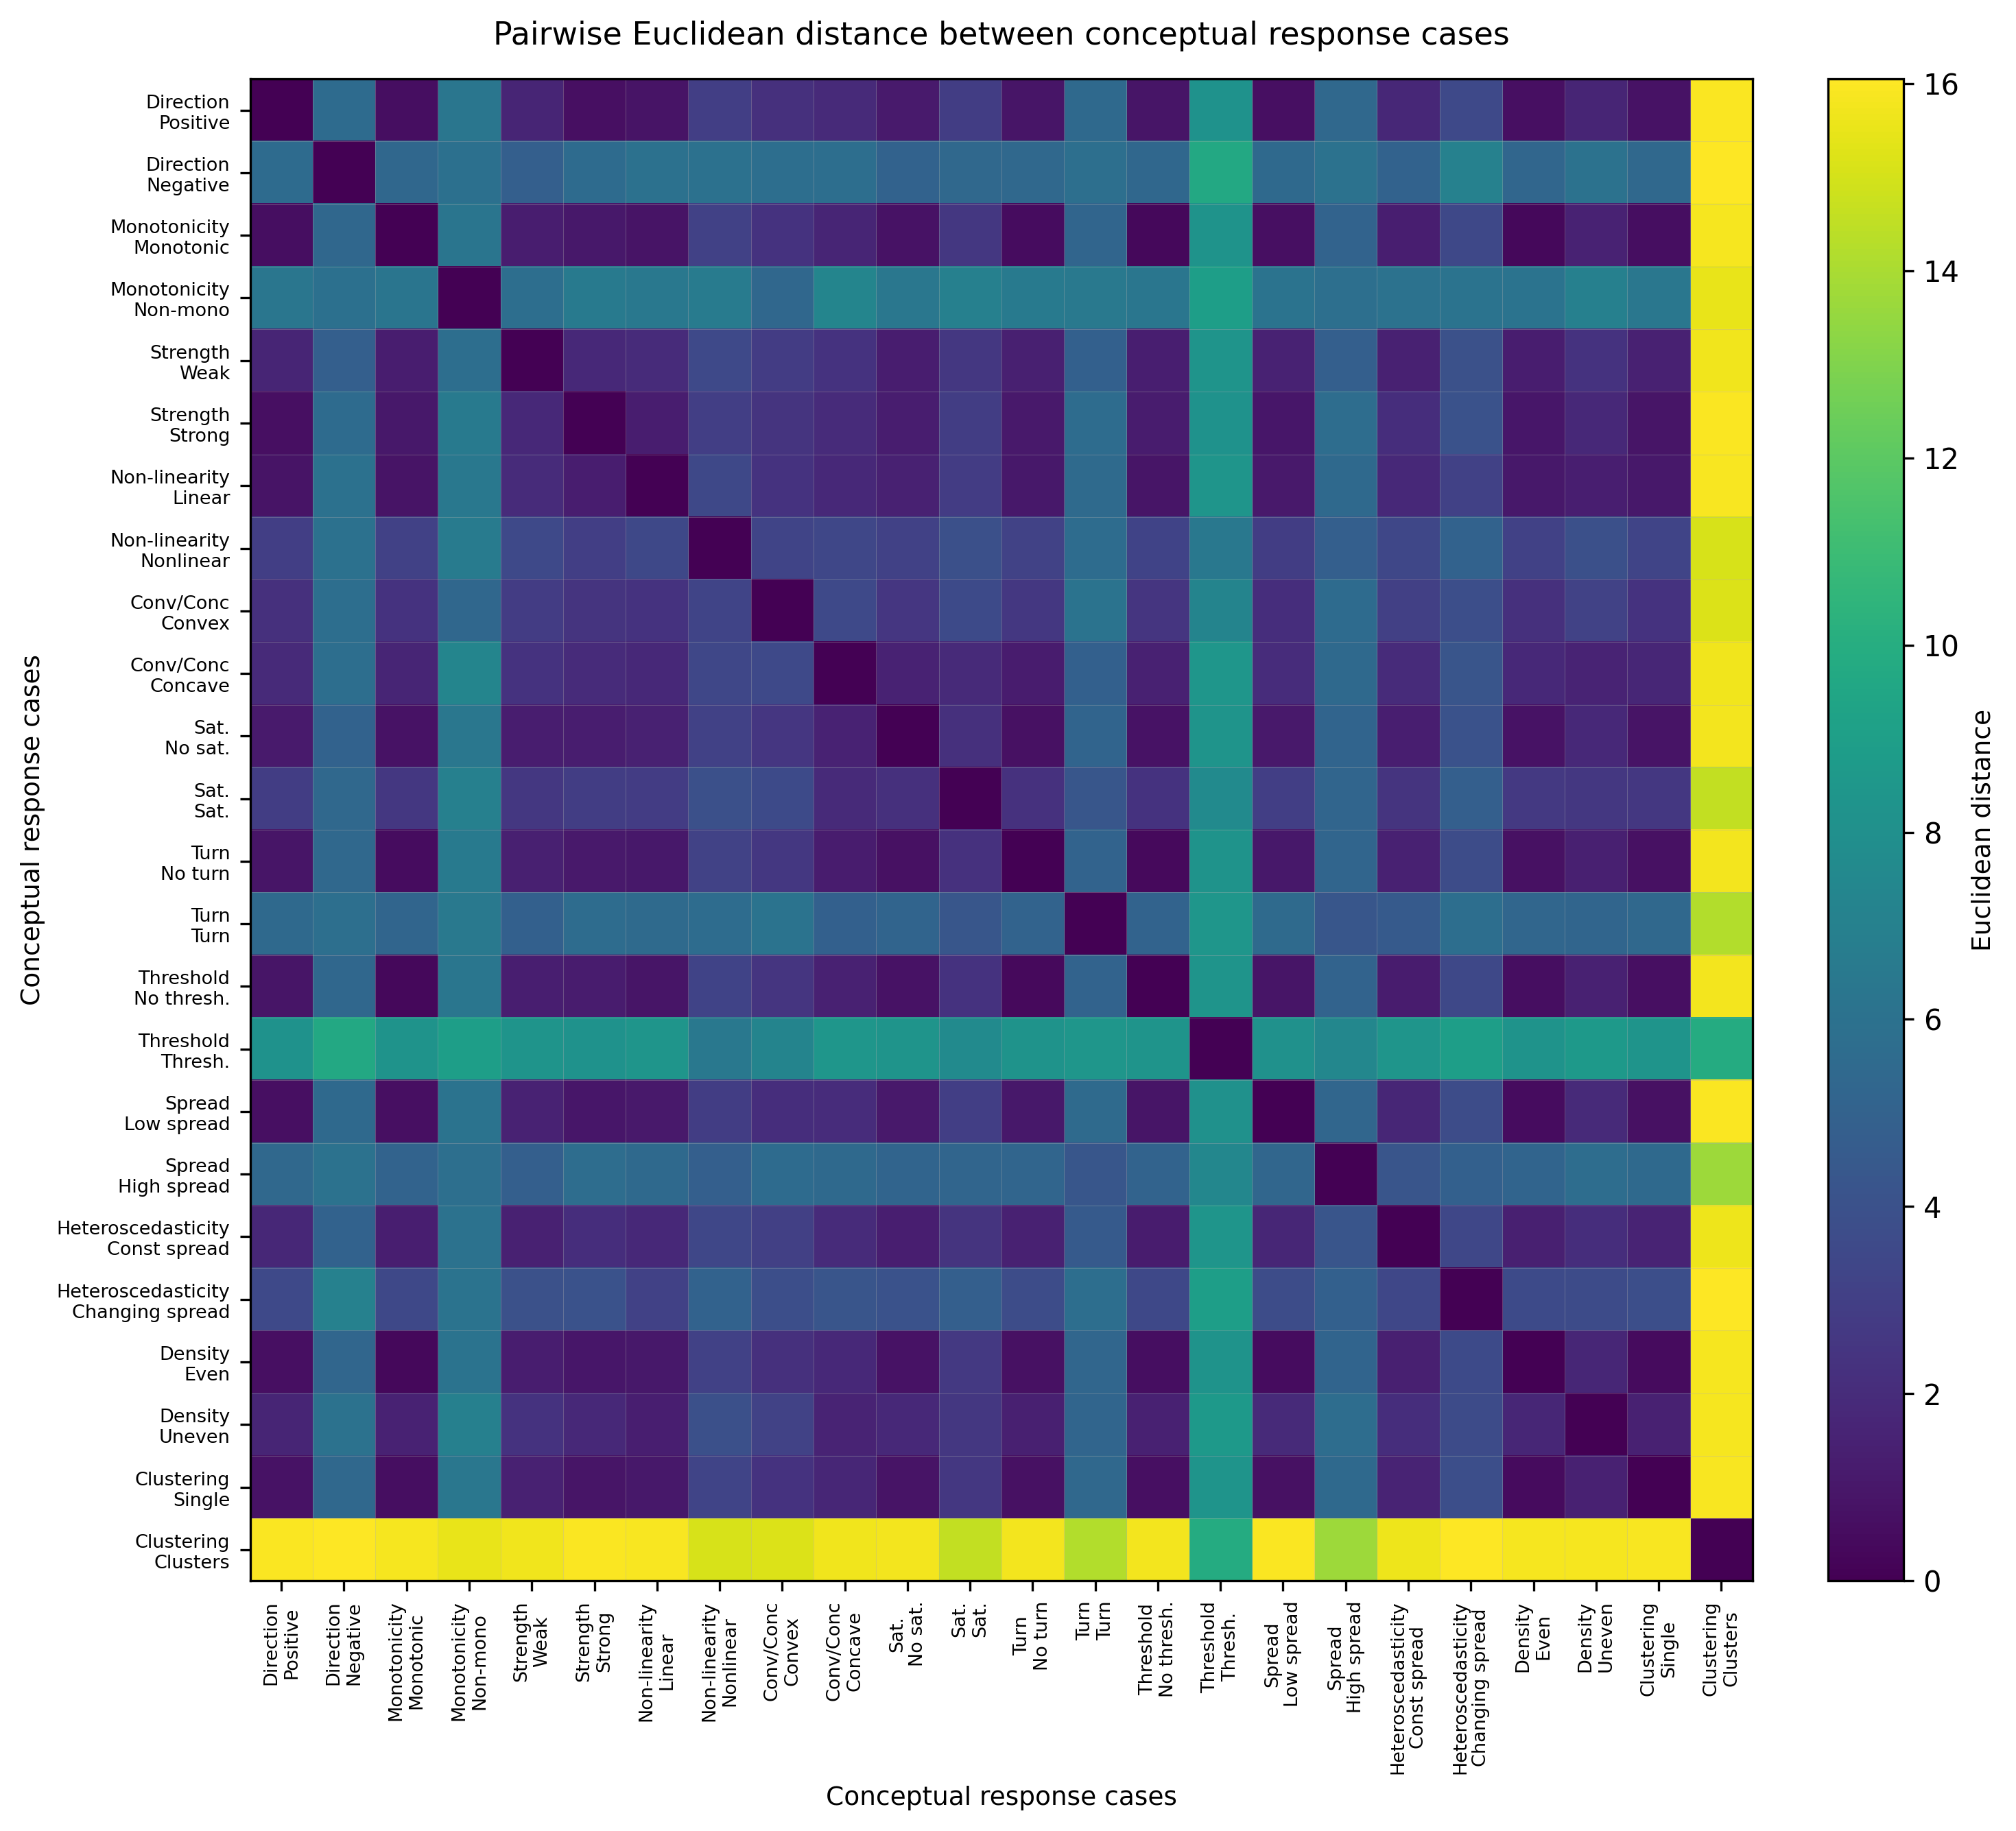

In [37]:
# ==========================================================
# 14. Visualize Euclidean distance matrix as heatmap
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np
import os

# Use rounded or unrounded distance matrix
# distance_matrix_df_rounded is easier to inspect visually
dist_df = raw_distance_matrix_df_rounded.copy()

# ==========================================================
# Optional: shorten labels for better display
# ==========================================================

def shorten_case_label(label):
    """
    Convert labels like:
    'Direction | Positive direction'
    into:
    'Direction\nPositive'
    """
    label = str(label)

    replacements = {
        "Positive direction": "Positive",
        "Negative direction": "Negative",
        "Non-monotonic": "Non-mono",
        "Weak response": "Weak",
        "Strong response": "Strong",
        "Non-linear": "Nonlinear",
        "Convexity / Concavity": "Conv/Conc",
        "No saturation": "No sat.",
        "Saturation": "Sat.",
        "No turning point": "No turn",
        "Turning point": "Turn",
        "No threshold": "No thresh.",
        "Threshold-like change": "Thresh.",
        "Low spread": "Low spread",
        "High spread": "High spread",
        "Constant spread": "Const spread",
        "Changing spread": "Changing spread",
        "Even coverage": "Even",
        "Uneven coverage": "Uneven",
        "Single cloud": "Single",
        "Separated clusters": "Clusters",
        "High certainty": "High cert.",
        "Low certainty": "Low cert.",
    }

    if " | " in label:
        prop, case = label.split(" | ", 1)
    else:
        prop, case = "", label

    prop_short = replacements.get(prop, prop)
    case_short = replacements.get(case, case)

    return f"{prop_short}\n{case_short}"


short_labels = [shorten_case_label(label) for label in dist_df.index]

# ==========================================================
# Plot heatmap
# ==========================================================

fig, ax = plt.subplots(figsize=(10.5, 9), dpi=300)

im = ax.imshow(
    dist_df.values,
    aspect="equal",
    interpolation="nearest",
)

# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)

cbar.set_label(
    "Euclidean distance",
    fontsize=9,
)

# Axis ticks
ax.set_xticks(np.arange(len(short_labels)))
ax.set_yticks(np.arange(len(short_labels)))

ax.set_xticklabels(
    short_labels,
    rotation=90,
    fontsize=6.5,
)

ax.set_yticklabels(
    short_labels,
    fontsize=6.5,
)

# Axis labels and title
ax.set_title(
    "Pairwise Euclidean distance between conceptual response cases",
    fontsize=11,
    pad=12,
)

ax.set_xlabel(
    "Conceptual response cases",
    fontsize=9,
)

ax.set_ylabel(
    "Conceptual response cases",
    fontsize=9,
)

# Add thin grid lines
ax.set_xticks(
    np.arange(-0.5, len(short_labels), 1),
    minor=True,
)

ax.set_yticks(
    np.arange(-0.5, len(short_labels), 1),
    minor=True,
)

ax.grid(
    which="minor",
    linewidth=0.25,
    alpha=0.35,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

plt.tight_layout()

# ==========================================================
# Save figure
# ==========================================================

# heatmap_output_path = os.path.join(
#     output_dir,
#     "conceptual_response_case_distance_heatmap.png",
# )

# plt.savefig(
#     heatmap_output_path,
#     dpi=300,
#     bbox_inches="tight",
# )

plt.show()

# print(f"Distance heatmap saved to: {heatmap_output_path}")

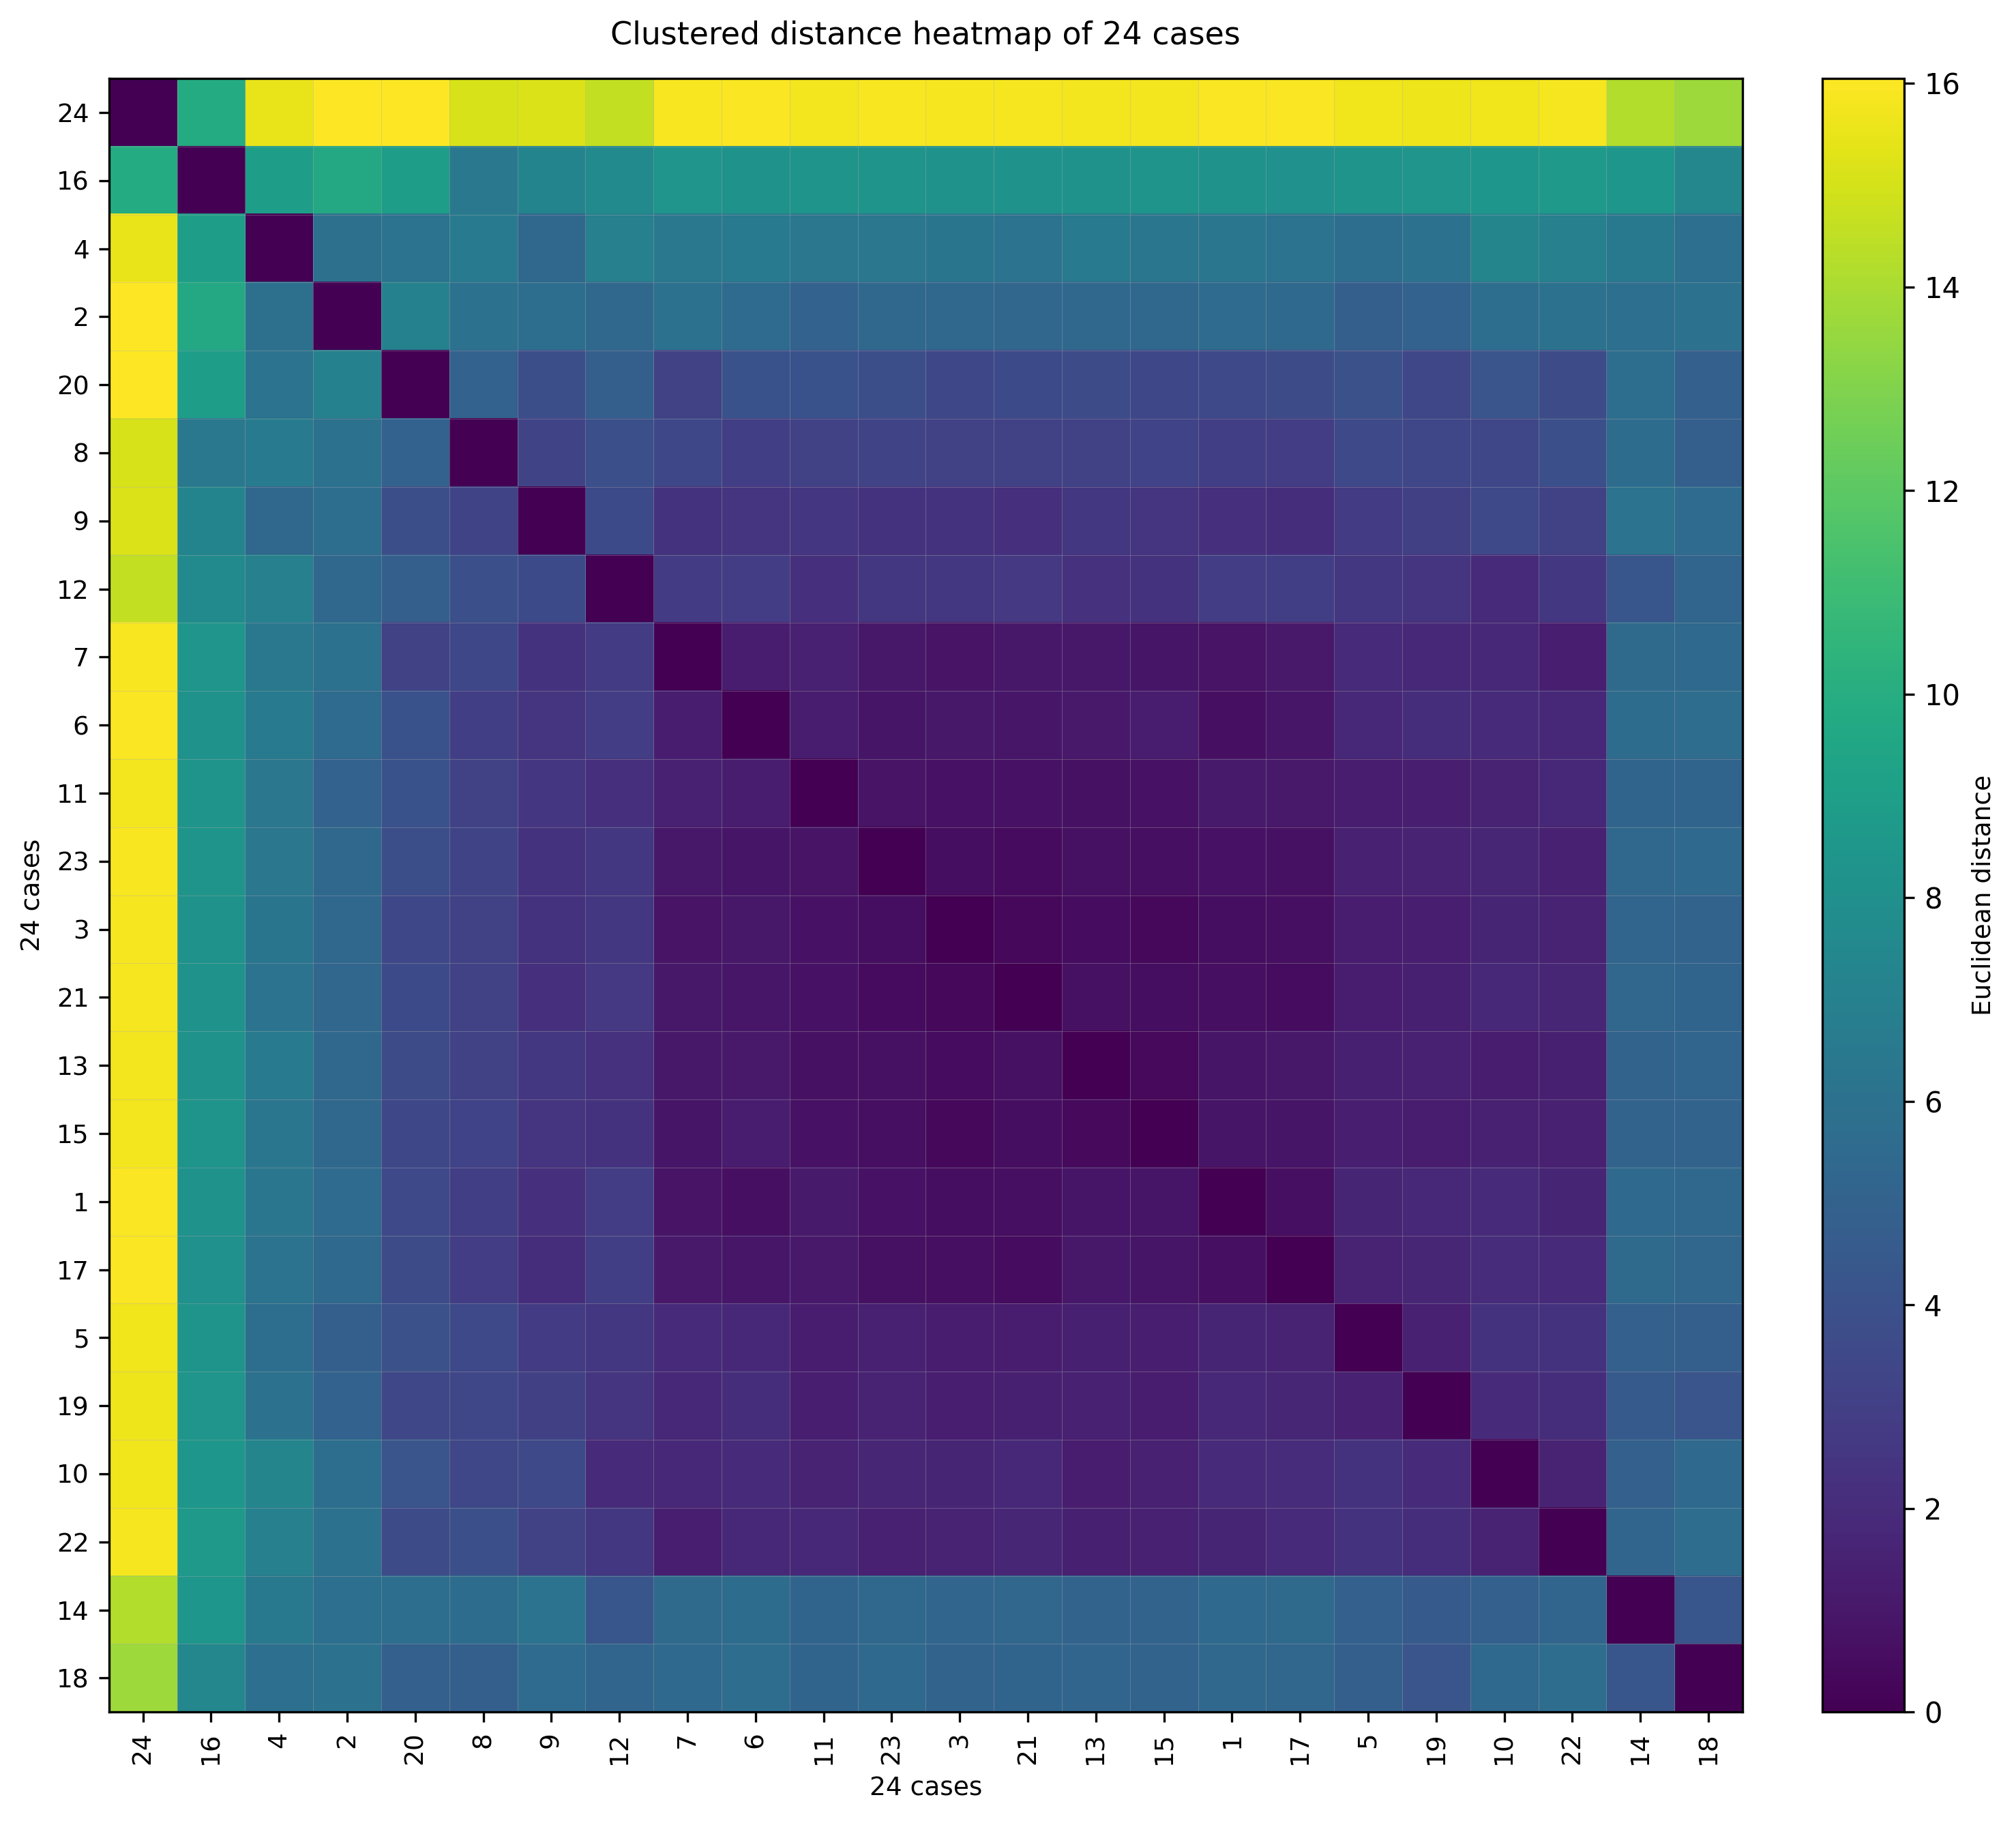

In [44]:
# ==========================================================
# 16. Hierarchical clustering based on distance matrix
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform


# ----------------------------------------------------------
# 1. Prepare distance matrix
# ----------------------------------------------------------

dist_df = raw_distance_matrix_df.copy()

# Make sure the matrix is numeric
dist_values = dist_df.values.astype(float)

# squareform converts a symmetric distance matrix into condensed form
# required by scipy linkage
condensed_dist = squareform(dist_values, checks=False)


# ----------------------------------------------------------
# 2. Hierarchical clustering
# ----------------------------------------------------------
# method options:
# - "average": balanced and commonly used
# - "complete": stricter clusters
# - "ward": requires original feature matrix, not distance matrix
#
# Here we use average linkage on the distance matrix.

Z = linkage(condensed_dist, method="average")


# ----------------------------------------------------------
# 3. Get reordered case order from dendrogram
# ----------------------------------------------------------

dendro = dendrogram(
    Z,
    labels=dist_df.index.tolist(),
    no_plot=True,
)

ordered_labels = dendro["ivl"]

reordered_dist_df = dist_df.loc[
    ordered_labels,
    ordered_labels,
]


# ----------------------------------------------------------
# 4. Plot reordered distance heatmap
# ----------------------------------------------------------

case_number_map = {
    "Positive direction": "1",
    "Negative direction": "2",
    "Monotonic": "3",
    "Non-monotonic": "4",
    "Weak response": "5",
    "Strong response": "6",
    "Linear": "7",
    "Non-linear": "8",
    "Convex": "9",
    "Concave": "10",
    "No saturation": "11",
    "Saturation": "12",
    "No turning point": "13",
    "Turning point": "14",
    "No threshold": "15",
    "Threshold-like change": "16",
    "Low spread": "17",
    "High spread": "18",
    "Constant spread": "19",
    "Changing spread": "20",
    "Even coverage": "21",
    "Uneven coverage": "22",
    "Single cloud": "23",
    "Separated clusters": "24",
}

def shorten_case_label(label):
    label = str(label)

    if " | " in label:
        prop, case = label.split(" | ", 1)
    else:
        case = label

    return case_number_map.get(case, case)

# def shorten_case_label(label):
#     label = str(label)

#     replacements = {
#         "Positive direction": "Positive",
#         "Negative direction": "Negative",
#         "Non-monotonic": "Non-mono",
#         "Weak response": "Weak",
#         "Strong response": "Strong",
#         "Non-linear": "Nonlinear",
#         "Convexity / Concavity": "Conv/Conc",
#         "No saturation": "No sat.",
#         "Saturation": "Sat.",
#         "No turning point": "No turn",
#         "Turning point": "Turn",
#         "No threshold": "No thresh.",
#         "Threshold-like change": "Thresh.",
#         "Constant spread": "Const spread",
#         "Changing spread": "Changing spread",
#         "Even coverage": "Even",
#         "Uneven coverage": "Uneven",
#         "Single cloud": "Single",
#         "Separated clusters": "Clusters",
#         "High certainty": "High cert.",
#         "Low certainty": "Low cert.",
#     }

#     if " | " in label:
#         prop, case = label.split(" | ", 1)
#     else:
#         prop, case = "", label

#     prop_short = replacements.get(prop, prop)
#     case_short = replacements.get(case, case)

#     return f"{prop_short}\n{case_short}"


short_labels = [
    shorten_case_label(label)
    for label in reordered_dist_df.index
]

fig, ax = plt.subplots(figsize=(10.5, 9), dpi=300)

im = ax.imshow(
    reordered_dist_df.values,
    aspect="equal",
    interpolation="nearest",
    vmin=0,
    vmax=np.nanmax(reordered_dist_df.values),
)

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04,
)

cbar.set_label(
    "Euclidean distance",
    fontsize=9,
)

ax.set_xticks(np.arange(len(short_labels)))
ax.set_yticks(np.arange(len(short_labels)))

ax.set_xticklabels(
    short_labels,
    rotation=90,
    fontsize=9,
)

ax.set_yticklabels(
    short_labels,
    fontsize=9,
)

ax.set_title(
    "Clustered distance heatmap of 24 cases",
    fontsize=11,
    pad=12,
)

ax.set_xlabel(
    "24 cases",
    fontsize=9,
)

ax.set_ylabel(
    "24 cases",
    fontsize=9,
)

# Add grid lines
ax.set_xticks(
    np.arange(-0.5, len(short_labels), 1),
    minor=True,
)

ax.set_yticks(
    np.arange(-0.5, len(short_labels), 1),
    minor=True,
)

ax.grid(
    which="minor",
    linewidth=0.25,
    alpha=0.35,
)

ax.tick_params(
    which="minor",
    bottom=False,
    left=False,
)

plt.tight_layout()

# clustered_heatmap_path = os.path.join(
#     output_dir,
#     "conceptual_response_case_distance_heatmap_clustered.png",
# )

# plt.savefig(
#     clustered_heatmap_path,
#     dpi=300,
#     bbox_inches="tight",
# )

plt.show()

# print(f"Clustered heatmap saved to: {clustered_heatmap_path}")

In [54]:
# # ==========================================================
# # 18. Automatically choose number of clusters
# #     based on silhouette score
# # ==========================================================

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from scipy.cluster.hierarchy import fcluster
# from sklearn.metrics import silhouette_score


# # ----------------------------------------------------------
# # 1. Prepare distance matrix
# # ----------------------------------------------------------

# dist_values = dist_df.values.astype(float)

# # Force symmetry and zero diagonal
# dist_values = (dist_values + dist_values.T) / 2
# np.fill_diagonal(dist_values, 0)


# # ----------------------------------------------------------
# # 2. Try different numbers of clusters
# # ----------------------------------------------------------
# # For 24 cases, testing k = 2 to 10 is usually enough.
# # You can change max_k if needed.

# min_k = 2
# max_k = 10

# silhouette_records = []

# for k in range(min_k, max_k + 1):

#     labels_k = fcluster(
#         Z,
#         t=k,
#         criterion="maxclust",
#     )

#     # Silhouette score requires at least 2 clusters
#     # and less than n clusters
#     if len(np.unique(labels_k)) < 2:
#         continue

#     score = silhouette_score(
#         dist_values,
#         labels_k,
#         metric="precomputed",
#     )

#     silhouette_records.append({
#         "n_clusters": k,
#         "silhouette_score": score,
#     })


# silhouette_df = pd.DataFrame(silhouette_records)

# best_k = int(
#     silhouette_df.loc[
#         silhouette_df["silhouette_score"].idxmax(),
#         "n_clusters"
#     ]
# )

# print(f"Best number of clusters selected automatically: {best_k}")

# silhouette_df

Best number of clusters selected automatically: 2


,n_clusters,silhouette_score
0,2,0.717672
1,3,0.556008
2,4,0.465595
3,5,0.439878
4,6,0.473990
5,7,0.448104
6,8,0.380836
7,9,0.347187
8,10,0.289390


In [60]:
# ==========================================================
# 18. Create cluster table with case numbers
# ==========================================================

from scipy.cluster.hierarchy import fcluster
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

n_clusters = 12

cluster_labels = fcluster(
    Z,
    t=n_clusters,
    criterion="maxclust",
)

cluster_df = pd.DataFrame({
    "case": dist_df.index.astype(str),
    "cluster": cluster_labels,
})

# Correct split: escape "|"
split_cols = cluster_df["case"].str.split(
    r" \| ",
    n=1,
    expand=True,
)

if split_cols.shape[1] == 2:
    cluster_df["property"] = split_cols[0]
    cluster_df["case_name"] = split_cols[1]
else:
    cluster_df["property"] = ""
    cluster_df["case_name"] = cluster_df["case"]

# If case label has no " | ", use the full case string as case_name
cluster_df["case_name"] = cluster_df["case_name"].fillna(cluster_df["case"])

# Remove extra spaces
cluster_df["case_name"] = cluster_df["case_name"].astype(str).str.strip()


# ----------------------------------------------------------
# Case name to number mapping
# ----------------------------------------------------------

case_number_map = {
    "Positive direction": 1,
    "Negative direction": 2,
    "Monotonic": 3,
    "Non-monotonic": 4,
    "Weak response": 5,
    "Strong response": 6,
    "Linear": 7,
    "Non-linear": 8,
    "Convex": 9,
    "Concave": 10,
    "No saturation": 11,
    "Saturation": 12,
    "No turning point": 13,
    "Turning point": 14,
    "No threshold": 15,
    "Threshold-like change": 16,
    "Low spread": 17,
    "High spread": 18,
    "Constant spread": 19,
    "Changing spread": 20,
    "Even coverage": 21,
    "Uneven coverage": 22,
    "Single cloud": 23,
    "Separated clusters": 24,
}

cluster_df["case_number"] = cluster_df["case_name"].map(case_number_map)


# ----------------------------------------------------------
# Check unmatched case names
# ----------------------------------------------------------

unmatched = cluster_df.loc[
    cluster_df["case_number"].isna(),
    ["case", "property", "case_name"]
]

if len(unmatched) > 0:
    print("Unmatched case names:")
    display(unmatched)


cluster_df = cluster_df[
    ["cluster", "case_number", "property", "case_name", "case"]
].sort_values(
    ["cluster", "case_number"]
).reset_index(drop=True)

cluster_df

,cluster,case_number,property,case_name,case
0,1,1,Direction,Positive direction,Direction | Positive direction
1,1,3,Monotonicity,Monotonic,Monotonicity | Monotonic
2,1,5,Strength,Weak response,Strength | Weak response
3,1,6,Strength,Strong response,Strength | Strong response
4,1,7,Non-linearity,Linear,Non-linearity | Linear
5,1,11,Saturation,No saturation,Saturation | No saturation
6,1,13,Turning point,No turning point,Turning point | No turning point
7,1,15,Threshold,No threshold,Threshold | No threshold
8,1,17,Spread,Low spread,Spread | Low spread
9,1,19,Heteroscedasticity,Constant spread,Heteroscedasticity | Constant spread


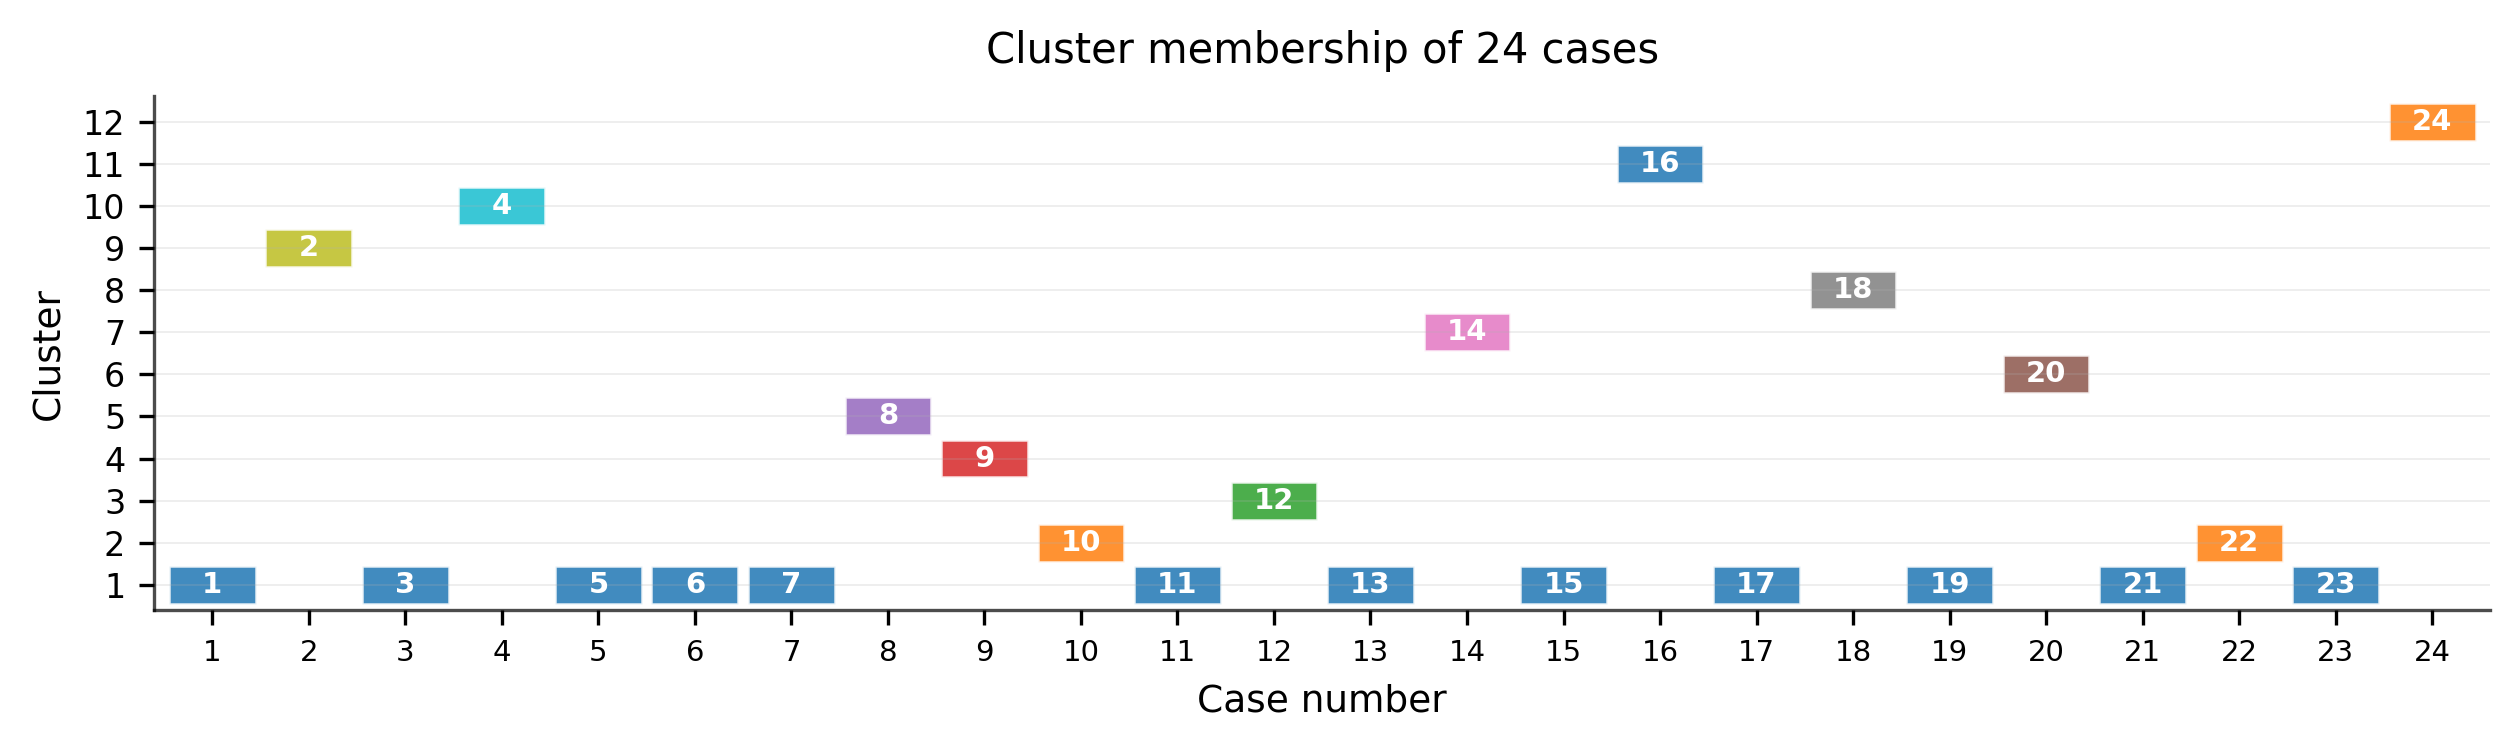

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches


# ==========================================================
# Plot cluster membership as a clean tile plot
# ==========================================================

plot_df = cluster_df.sort_values("case_number").copy()

fig, ax = plt.subplots(
    figsize=(8.5, 2.6),
    dpi=300,
)

# Draw one tile for each case
for _, row in plot_df.iterrows():
    x = row["case_number"]
    y = row["cluster"]

    rect = patches.Rectangle(
        (x - 0.45, y - 0.45),
        0.90,
        0.90,
        linewidth=0.6,
        edgecolor="white",
        facecolor=plt.cm.tab10((int(y) - 1) % 10),
        alpha=0.85,
    )
    ax.add_patch(rect)

    ax.text(
        x,
        y,
        str(int(x)),
        ha="center",
        va="center",
        fontsize=7,
        color="white",
        fontweight="bold",
    )

ax.set_xlim(0.4, 24.6)
ax.set_ylim(0.4, n_clusters + 0.6)

ax.set_xticks(np.arange(1, 25, 1))
ax.set_yticks(np.arange(1, n_clusters + 1, 1))

ax.set_xlabel("Case number", fontsize=9)
ax.set_ylabel("Cluster", fontsize=9)

ax.set_title(
    "Cluster membership of 24 cases",
    fontsize=10,
    pad=8,
)

ax.tick_params(axis="x", labelsize=7)
ax.tick_params(axis="y", labelsize=8)

ax.grid(
    axis="y",
    linewidth=0.4,
    alpha=0.25,
)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.8)
    ax.spines[spine].set_alpha(0.7)

plt.tight_layout()
plt.show()

In [46]:
# ==========================================================
# 19. Summarize cases in each cluster
# ==========================================================

cluster_summary_df = (
    cluster_df
    .groupby("cluster")["case"]
    .apply(lambda x: "; ".join(x))
    .reset_index()
)

cluster_summary_df.columns = ["cluster", "cases_in_cluster"]

cluster_summary_df

,cluster,cases_in_cluster
0,1,Clustering | Single cloud; Convexity / Concavi...
1,2,Convexity / Concavity | Convex
2,3,Non-linearity | Non-linear
3,4,Heteroscedasticity | Changing spread
4,5,Turning point | Turning point
5,6,Spread | High spread
6,7,Direction | Negative direction
7,8,Monotonicity | Non-monotonic
8,9,Threshold | Threshold-like change
9,10,Clustering | Separated clusters


## 可以用来计算扰动的东西

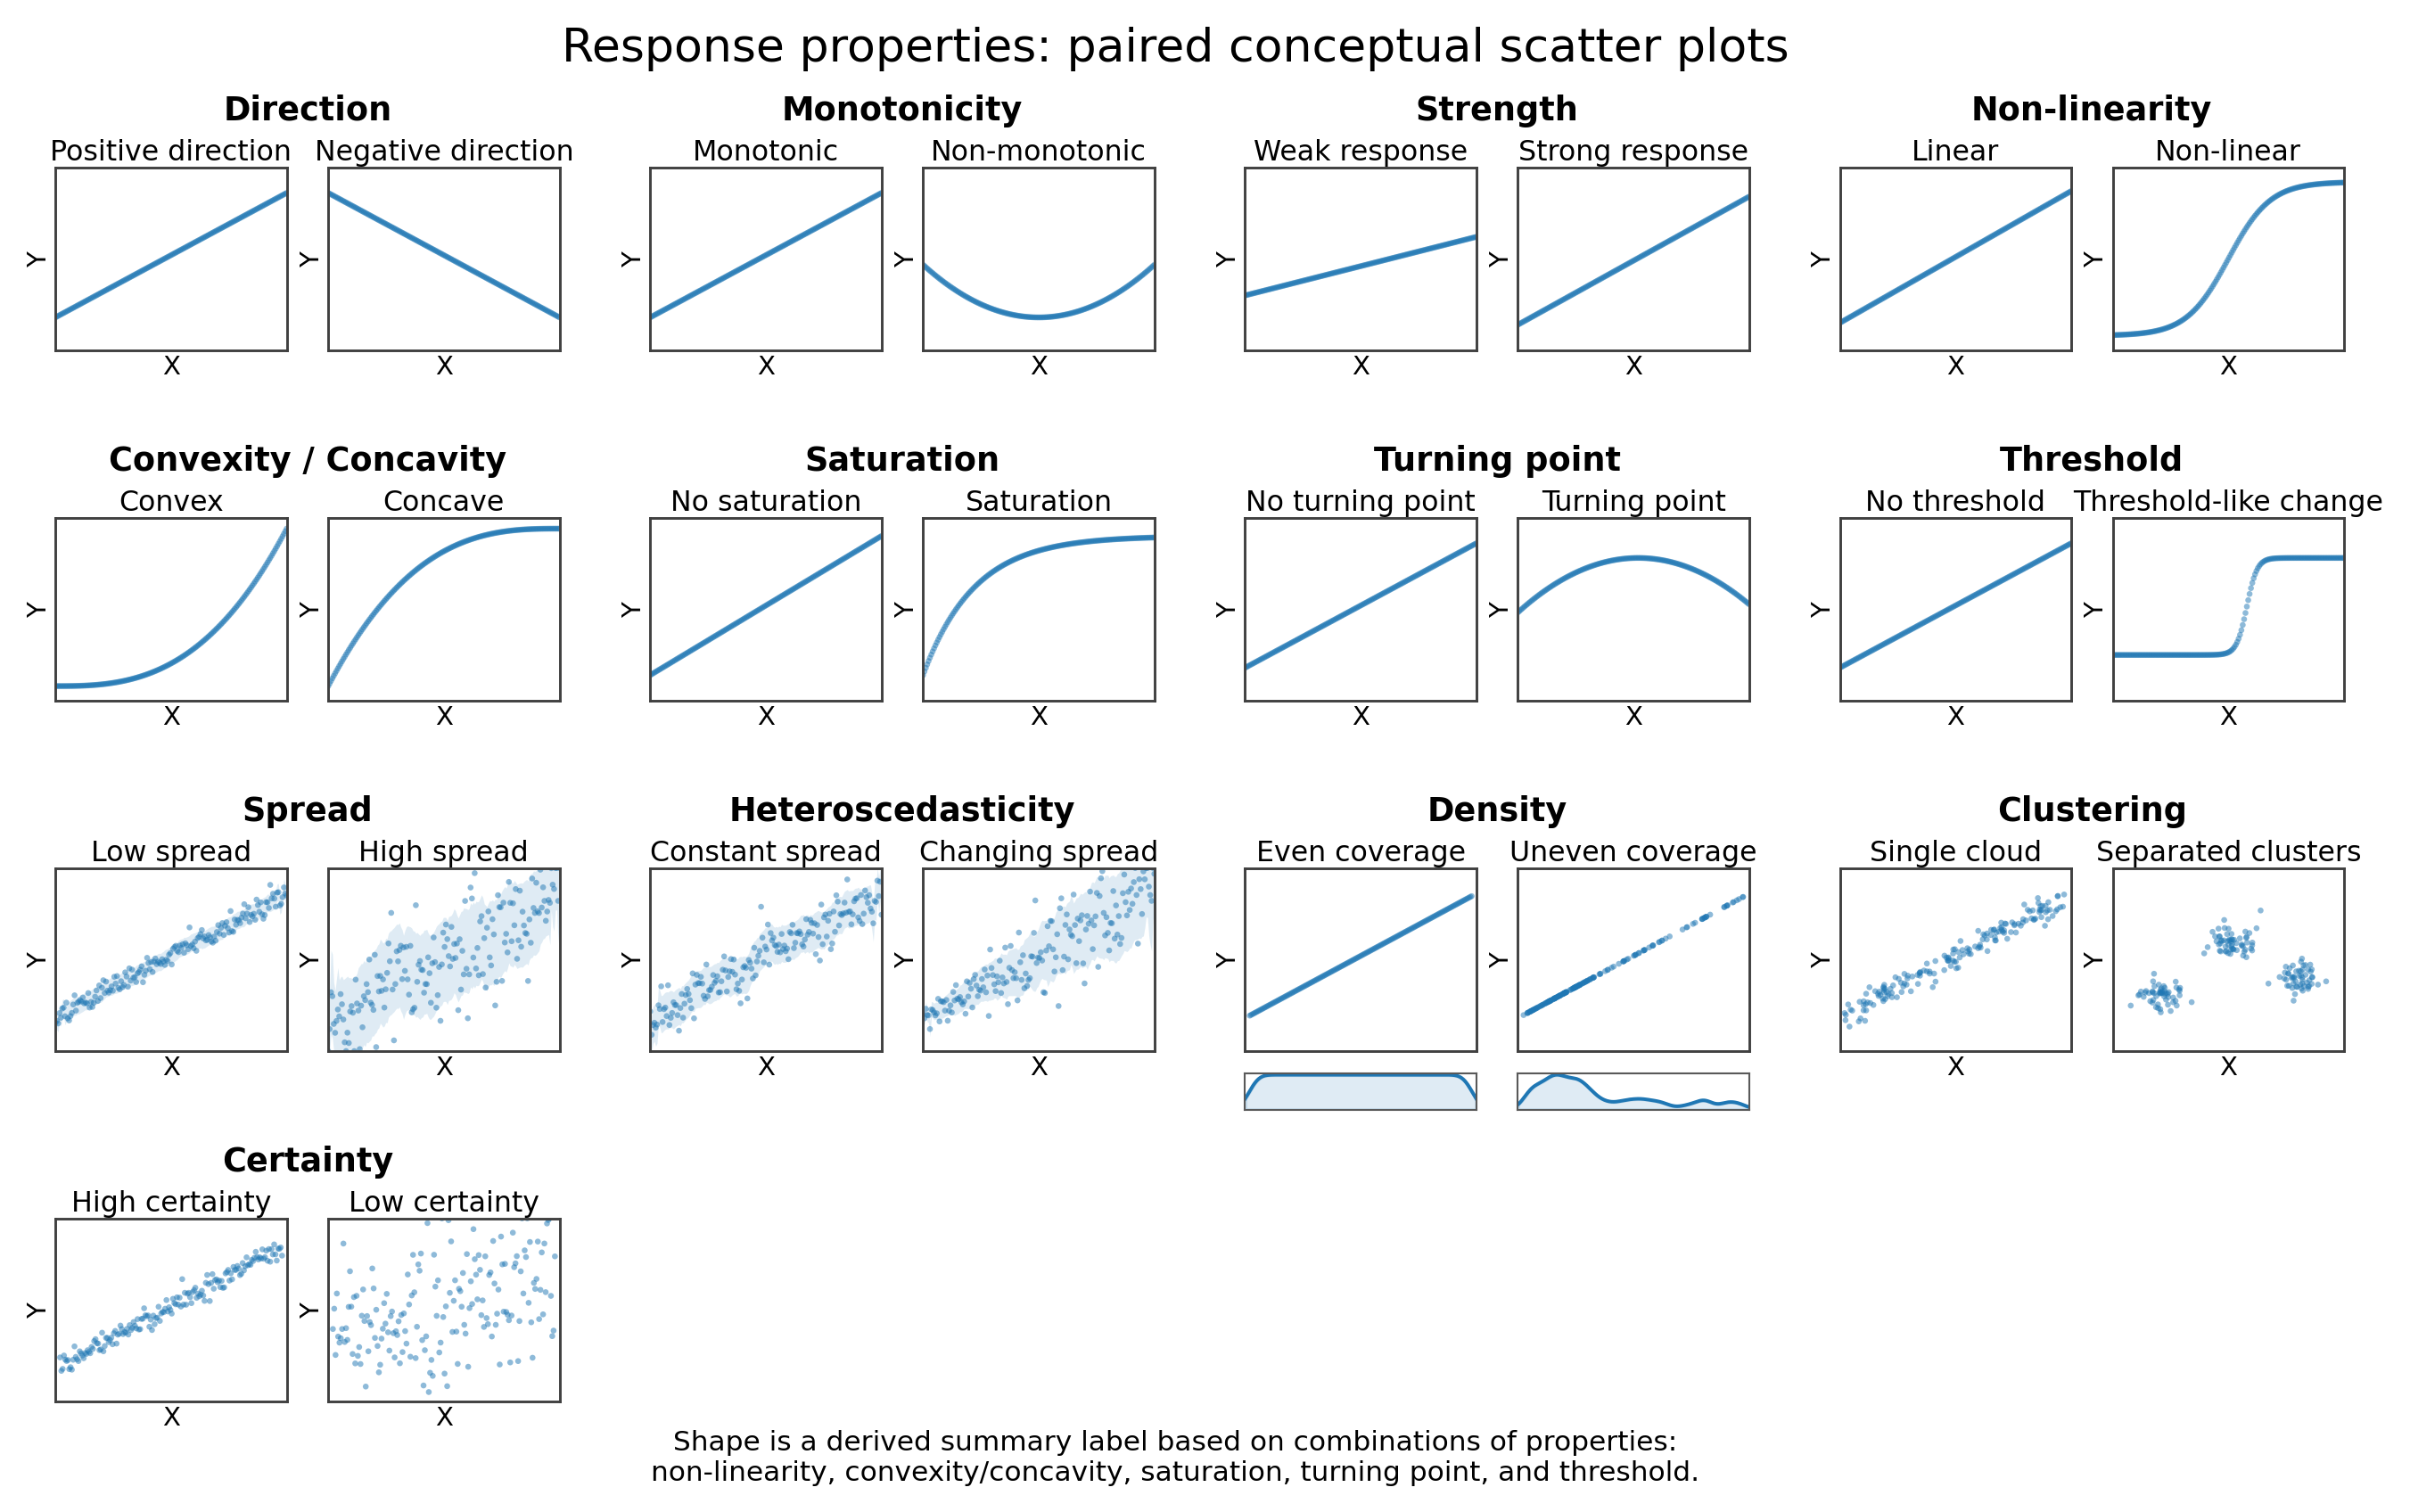

In [1]:
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# # ==========================================================
# # 0. Basic settings
# # ==========================================================

# np.random.seed(88)
# rng = np.random.default_rng(88)

# x_base = np.linspace(0, 1, 170)

# POINT_COLOR = "C0"
# BUFFER_COLOR = "C0"

# properties = [
#     ("Direction", "Positive direction", "Negative direction"),
#     ("Monotonicity", "Monotonic", "Non-monotonic"),
#     ("Strength", "Weak response", "Strong response"),
#     ("Non-linearity", "Linear", "Non-linear"),
#     ("Convexity / Concavity", "Convex", "Concave"),
#     ("Saturation", "No saturation", "Saturation"),
#     ("Turning point", "No turning point", "Turning point"),
#     ("Threshold", "No threshold", "Threshold-like change"),
#     ("Spread", "Low spread", "High spread"),
#     ("Heteroscedasticity", "Constant spread", "Changing spread"),
#     ("Density", "Even coverage", "Uneven coverage"),
#     ("Clustering", "Single cloud", "Separated clusters"),
#     ("Certainty", "High certainty", "Low certainty"),
# ]


# # ==========================================================
# # 1. Data generation
# # This is the SAME as the metric code.
# # ==========================================================

# def curve_data(prop):
#     xx = x_base.copy()

#     if prop == "Direction":
#         return (
#             (xx, 0.18 + 0.68 * xx),
#             (xx, 0.86 - 0.68 * xx),
#         )

#     if prop == "Monotonicity":
#         return (
#             (xx, 0.18 + 0.68 * xx),
#             (xx, 0.18 + 1.15 * (xx - 0.50) ** 2),
#         )

#     if prop == "Strength":
#         return (
#             (xx, 0.30 + 0.32 * xx),
#             (xx, 0.14 + 0.70 * xx),
#         )

#     if prop == "Non-linearity":
#         y_linear = 0.15 + 0.72 * xx
#         y_nonlinear = 0.08 + 0.84 / (1 + np.exp(-11.0 * (xx - 0.50)))

#         return (
#             (xx, y_linear),
#             (xx, y_nonlinear),
#         )

#     if prop == "Convexity / Concavity":
#         y_convex = 0.08 + 0.86 * (xx ** 2.8)
#         y_concave = 0.08 + 0.86 * (1 - (1 - xx) ** 2.8)

#         return (
#             (xx, y_convex),
#             (xx, y_concave),
#         )

#     if prop == "Saturation":
#         return (
#             (xx, 0.14 + 0.76 * xx),
#             (xx, 0.14 + 0.76 * (1 - np.exp(-4.5 * xx))),
#         )

#     if prop == "Turning point":
#         return (
#             (xx, 0.18 + 0.68 * xx),
#             (xx, 0.78 - 1.10 * (xx - 0.52) ** 2),
#         )

#     if prop == "Threshold":
#         y_no_threshold = 0.18 + 0.68 * xx

#         threshold = 0.58
#         y_threshold = 0.25 + 0.53 / (1 + np.exp(-45 * (xx - threshold)))

#         return (
#             (xx, y_no_threshold),
#             (xx, y_threshold),
#         )

#     if prop == "Spread":
#         y_mean = 0.18 + 0.68 * xx

#         y_low_spread = y_mean + rng.normal(0, 0.035, len(xx))
#         y_high_spread = y_mean + rng.normal(0, 0.17, len(xx))

#         return (
#             (xx, np.clip(y_low_spread, 0, 1)),
#             (xx, np.clip(y_high_spread, 0, 1)),
#         )

#     if prop == "Heteroscedasticity":
#         y_mean = 0.18 + 0.68 * xx

#         y_constant = y_mean + rng.normal(0, 0.075, len(xx))
#         y_changing = y_mean + rng.normal(0, 0.025 + 0.18 * xx, len(xx))

#         return (
#             (xx, np.clip(y_constant, 0, 1)),
#             (xx, np.clip(y_changing, 0, 1)),
#         )

#     if prop == "Density":
#         x_even = np.linspace(0.02, 0.98, 170)

#         x_uneven = np.concatenate([
#             rng.uniform(0.02, 0.34, 110),
#             rng.uniform(0.34, 0.98, 60),
#         ])
#         x_uneven = np.sort(x_uneven)

#         return (
#             (x_even, 0.18 + 0.68 * x_even),
#             (x_uneven, 0.18 + 0.68 * x_uneven),
#         )

#     if prop == "Clustering":
#         x_single = rng.uniform(0.02, 0.98, 170)
#         y_single = 0.18 + 0.68 * x_single + rng.normal(0, 0.035, 170)

#         n1, n2, n3 = 55, 60, 55

#         x_c1 = rng.normal(0.22, 0.045, n1)
#         y_c1 = rng.normal(0.30, 0.045, n1)

#         x_c2 = rng.normal(0.52, 0.050, n2)
#         y_c2 = rng.normal(0.60, 0.050, n2)

#         x_c3 = rng.normal(0.80, 0.045, n3)
#         y_c3 = rng.normal(0.40, 0.045, n3)

#         x_cluster = np.clip(
#             np.concatenate([x_c1, x_c2, x_c3]),
#             0.02,
#             0.98,
#         )
#         y_cluster = np.clip(
#             np.concatenate([y_c1, y_c2, y_c3]),
#             0.05,
#             0.95,
#         )

#         return (
#             (x_single, np.clip(y_single, 0, 1)),
#             (x_cluster, y_cluster),
#         )

#     if prop == "Certainty":
#         x_good = np.linspace(0.02, 0.98, 170)
#         y_good = 0.18 + 0.68 * x_good + rng.normal(0, 0.030, len(x_good))

#         x_bad = np.linspace(0.02, 0.98, 170)
#         y_bad = 0.35 + 0.30 * x_bad + rng.normal(0, 0.20, len(x_bad))

#         return (
#             (x_good, np.clip(y_good, 0, 1)),
#             (x_bad, np.clip(y_bad, 0, 1)),
#         )

#     raise ValueError(f"Unknown property: {prop}")


# # ==========================================================
# # 2. Plotting helpers
# # ==========================================================

# def kde_manual(values, grid, bandwidth=0.035):
#     values = np.asarray(values)
#     grid = np.asarray(grid)

#     dens = np.zeros_like(grid, dtype=float)

#     for v in values:
#         dens += np.exp(-0.5 * ((grid - v) / bandwidth) ** 2)

#     dens /= max(len(values), 1)

#     if dens.max() > 0:
#         dens = dens / dens.max()

#     return dens


# def style_axis(ax):
#     ax.set_xlim(0, 1)
#     ax.set_ylim(0, 1)

#     ax.set_xticks([])
#     ax.set_yticks([])

#     for spine in ["top", "right", "bottom", "left"]:
#         ax.spines[spine].set_visible(True)
#         ax.spines[spine].set_linewidth(0.70)
#         ax.spines[spine].set_color("0.25")

#     ax.set_xlabel("X", fontsize=7, labelpad=1)
#     ax.set_ylabel("Y", fontsize=7, labelpad=1)


# def add_buffer_from_points(ax, xx, yy, buffer_width, alpha=0.14):
#     """
#     Add visual buffer around the mean trend.
#     This is only for visualization.
#     """
#     xx = np.asarray(xx)
#     yy = np.asarray(yy)

#     order = np.argsort(xx)
#     xx_o = xx[order]
#     yy_o = yy[order]

#     if np.isscalar(buffer_width):
#         bw = np.full_like(xx_o, buffer_width, dtype=float)
#     else:
#         bw = np.asarray(buffer_width)[order]

#     ax.fill_between(
#         xx_o,
#         np.clip(yy_o - bw, 0, 1),
#         np.clip(yy_o + bw, 0, 1),
#         color=BUFFER_COLOR,
#         alpha=alpha,
#         linewidth=0,
#         zorder=1,
#     )


# def draw_density_inset(ax, xx):
#     grid = np.linspace(0, 1, 300)
#     dens = kde_manual(xx, grid, bandwidth=0.035)

#     ax_den = inset_axes(
#         ax,
#         width="100%",
#         height="20%",
#         loc="lower left",
#         bbox_to_anchor=(0, -0.32, 1, 1),
#         bbox_transform=ax.transAxes,
#         borderpad=0,
#     )

#     ax_den.plot(grid, dens, linewidth=0.95, color=POINT_COLOR)
#     ax_den.fill_between(grid, 0, dens, color=BUFFER_COLOR, alpha=0.14)

#     ax_den.set_xlim(0, 1)
#     ax_den.set_ylim(0, 1.05)
#     ax_den.set_xticks([])
#     ax_den.set_yticks([])

#     for spine in ["top", "right", "bottom", "left"]:
#         ax_den.spines[spine].set_visible(True)
#         ax_den.spines[spine].set_linewidth(0.50)
#         ax_den.spines[spine].set_color("0.35")


# def moving_average_trend(xx, yy, window=13):
#     """
#     Simple smooth trend for visual buffer only.
#     It does not change the scatter data used for plotting.
#     """
#     xx = np.asarray(xx)
#     yy = np.asarray(yy)

#     order = np.argsort(xx)
#     xx_o = xx[order]
#     yy_o = yy[order]

#     if len(yy_o) < window:
#         return xx_o, yy_o

#     kernel = np.ones(window) / window
#     yy_smooth = np.convolve(yy_o, kernel, mode="same")

#     # avoid edge artifacts by replacing edges with original values
#     half = window // 2
#     yy_smooth[:half] = yy_o[:half]
#     yy_smooth[-half:] = yy_o[-half:]

#     return xx_o, yy_smooth


# def draw_panel(ax, xx, yy, title, prop, side):
#     xx = np.asarray(xx)
#     yy = np.asarray(yy)

#     # Add visual buffers only for Spread and Heteroscedasticity.
#     # The scatter points themselves are exactly from curve_data().
#     if prop == "Spread":
#         if side == 0:
#             buffer_width = 0.035 * 1.35
#         else:
#             buffer_width = 0.17 * 1.35

#         x_trend, y_trend = moving_average_trend(xx, yy, window=17)
#         add_buffer_from_points(ax, x_trend, y_trend, buffer_width, alpha=0.14)

#     elif prop == "Heteroscedasticity":
#         x_trend, y_trend = moving_average_trend(xx, yy, window=17)

#         if side == 0:
#             buffer_width = np.full_like(x_trend, 0.075 * 1.35)
#         else:
#             buffer_width = (0.025 + 0.18 * x_trend) * 1.35

#         add_buffer_from_points(ax, x_trend, y_trend, buffer_width, alpha=0.14)

#     # Scatter points: exactly the metric data
#     ax.scatter(
#         xx,
#         yy,
#         s=2.5,
#         alpha=0.5,
#         color=POINT_COLOR,
#         edgecolors="none",
#         linewidths=0,
#         zorder=2,
#     )

#     ax.set_title(title, fontsize=7.6, pad=2)
#     style_axis(ax)


# # ==========================================================
# # 3. Combine 13 groups into one figure
# # ==========================================================

# # Important:
# # reset rng before plotting to ensure the generated data are the same
# # every time this block is run from scratch.
# np.random.seed(88)
# rng = np.random.default_rng(88)

# n_cols = 4
# n_rows = int(np.ceil(len(properties) / n_cols))

# fig = plt.figure(figsize=(9.2, 5.5), dpi=300)

# outer = GridSpec(
#     n_rows,
#     n_cols,
#     figure=fig,
#     hspace=0.32,
#     wspace=0.18,
# )

# for idx, (prop, left_title, right_title) in enumerate(properties):
#     row = idx // n_cols
#     col = idx % n_cols

#     cell = GridSpecFromSubplotSpec(
#         2,
#         2,
#         subplot_spec=outer[row, col],
#         height_ratios=[0.20, 0.80],
#         hspace=0.32,
#         wspace=0.18,
#     )

#     title_ax = fig.add_subplot(cell[0, :])
#     title_ax.axis("off")

#     title_ax.text(
#         0.5,
#         0.45,
#         prop,
#         ha="center",
#         va="center",
#         fontsize=8.8,
#         fontweight="bold",
#     )

#     (xl, yl), (xr, yr) = curve_data(prop)

#     ax_l = fig.add_subplot(cell[1, 0])
#     ax_r = fig.add_subplot(cell[1, 1])

#     draw_panel(ax_l, xl, yl, left_title, prop, 0)
#     draw_panel(ax_r, xr, yr, right_title, prop, 1)

#     if prop == "Density":
#         ax_l.set_xlabel("")
#         ax_r.set_xlabel("")
#         draw_density_inset(ax_l, xl)
#         draw_density_inset(ax_r, xr)

# # Empty cell for the 14th position
# if len(properties) % n_cols != 0:
#     empty_ax = fig.add_subplot(outer[-1, -1])
#     empty_ax.axis("off")

# fig.suptitle(
#     "Response properties: paired conceptual scatter plots",
#     fontsize=12.5,
#     y=0.995,
# )

# shape_note = (
#     "Shape is a derived summary label based on combinations of properties:\n"
#     "non-linearity, convexity/concavity, saturation, turning point, and threshold."
# )

# fig.text(
#     0.5,
#     0.022,
#     shape_note,
#     ha="center",
#     va="center",
#     fontsize=7.5,
# )

# plt.subplots_adjust(
#     left=0.045,
#     right=0.975,
#     top=0.955,
#     bottom=0.06,
# )

# plt.show()

## 先计算原始 metrics；再只对 Y-unit metrics 增加 / SD(Y) 版本；最后输出一个完整表和一个建议用于 heatmap 的 selected 表。